# Tide Gauge Temporal Analysis

## Time Series Plot
One plot per gauge showing observed water level over time. Missing data is left as gaps.

In [1]:
import glob
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

DATA_DIR = "../3_Cleaned"

csv_files = sorted(
    f for f in glob.glob(os.path.join(DATA_DIR, "*.csv"))
    if os.path.basename(f) != "00_gauge_metadata.csv"
)

n_gauges = len(csv_files)
ncols = 2
nrows = (n_gauges + ncols - 1) // ncols

# fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3.5))
# axes = axes.flatten()

# for ax, fpath in zip(axes, csv_files):
#     df = pd.read_csv(fpath, parse_dates=["DateTime"])
#     # drop rows where either DateTime or Observed is missing
#     df = df.dropna(subset=["Observed"])

#     site_name = df["SiteName"].iloc[0] if not df.empty else os.path.basename(fpath)

#     ax.plot(df["DateTime"], df["Observed"], linewidth=0.4, color="steelblue")
#     ax.set_title(site_name, fontsize=10, fontweight="bold")
#     ax.set_ylabel("Water level (m)", fontsize=8)
#     ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
#     ax.xaxis.set_major_locator(mdates.YearLocator(2))
#     ax.tick_params(axis="x", labelsize=7, rotation=30)
#     ax.tick_params(axis="y", labelsize=7)
#     ax.grid(True, linestyle="--", linewidth=0.3, alpha=0.6)

# # hide any leftover axes
# for ax in axes[n_gauges:]:
#     ax.set_visible(False)

# fig.suptitle("Thames Estuary Tide Gauge — Observed Water Levels", fontsize=13, fontweight="bold", y=1.01)
# plt.tight_layout()
# plt.savefig("../outputs/gauge_ts.png", dpi=150, bbox_inches="tight")
# plt.show()

## Fault Flagging

First-pass quality control to mark catastrophic, unambiguous sensor/telemetry faults before EDA.
Two rules are applied independently per gauge:

- **Boundary check** — flags values outside `[median ± BOUNDARY_MULTIPLIER × MAD]`. Computed per gauge so no single global threshold is imposed. MAD is used instead of std so a handful of extreme outliers can't inflate the window.
- **Rate-of-change check** — flags a reading if `|ΔObserved / Δt|` (m per minute, normalised by the *actual* elapsed time) exceeds a **per-gauge** threshold calibrated from that gauge's own empirical rate-of-change distribution (see *Per-Gauge Rate-of-Change Calibration* below), rather than one constant imposed on every gauge. Normalising by elapsed time means genuine large movements across a real data gap are not penalised.

Neither rule removes any data. Flags are added as boolean columns and logged in a summary table and audit dict for manual review.

In [2]:
# Load all gauges into a persistent dict keyed by idSite.
# Requires csv_files to be defined (run the Time Series cell above first).
gauges = {}
for fpath in csv_files:
    df = pd.read_csv(fpath, parse_dates=["DateTime"])
    key = df["idSite"].iloc[0]
    gauges[key] = df

print(f"Loaded {len(gauges)} gauges\n")
for gid, gdf in gauges.items():
    obs = gdf["Observed"]
    print(
        f"  {gid:<35} {gdf['SiteName'].iloc[0]:<28} "
        f"rows={len(gdf):>9,}  "
        f"Observed=[{obs.min():>9.3f}, {obs.max():>7.3f}]"
    )

Loaded 16 gauges

  01_RICHMOND                         Richmond Lock                rows=1,076,814  Observed=[   -1.250,  17.851]
  02_CHELSEA                          Chelsea Bridge               rows=1,057,679  Observed=[   -0.961,  11.910]
  03_LONDONBRIDGE                     London Bridge (Tower Pier)   rows=1,080,316  Observed=[   -2.100,  10.740]
  04_CHARLTON                         Charlton (Cory's)            rows=1,067,937  Observed=[   -2.350,  10.390]
  05_NORTHWOOLWICH                    North Woolwich (Silvertown)  rows=1,078,889  Observed=[   -2.170,   8.770]
  06_ERITH                            Erith (Erith Pier)           rows=  841,766  Observed=[   -3.680,  13.682]
  07_TILBURY                          Tilbury (NHCT)               rows=1,086,485  Observed=[   -0.469,   8.180]
  08_GRAVESEND                        Gravesend (Denton)           rows=1,046,626  Observed=[   -0.445,   7.967]
  09a_CORYTON_THAMESHAVEN             Coryton (Thameshaven)        rows=  365,

## Datum Correction — Chart Datum → ODN

Every gauge's `Observed` column is relative to that gauge's own local **Chart Datum (CD)** — historically close to Lowest Astronomical Tide at that specific site — so raw values are *not* comparable across gauges (e.g. Richmond's CD sits 0.61 m below ODN, London Bridge's sits 3.20 m below ODN).

`Observed_ODN` re-references every gauge to the shared **Ordnance Datum Newlyn (ODN)**, using the per-gauge offsets in `00_gauge_metadata.csv` (`ChartDatum_m_below_ODN`, from the PLA "Thames Tide Gauge National Grid References" table):

```
Observed_ODN = Observed - ChartDatum_m_below_ODN
```

(CD sits `ChartDatum_m_below_ODN` metres *below* ODN, so subtracting that offset converts "height above CD" into "height above ODN".)

The column is computed once here and written back into every `3_Cleaned/*.csv`, so it persists outside this notebook too. All EDA below uses `Observed_ODN`; `Observed` is left untouched as the raw audit trail.

In [3]:
# ── Datum correction: Chart Datum → ODN ──────────────────────────────────────────
GAUGE_METADATA = pd.read_csv(os.path.join(DATA_DIR, "00_gauge_metadata.csv")).set_index("idSite")
odn_offset = GAUGE_METADATA["ChartDatum_m_below_ODN"]

for gid, gdf in gauges.items():
    gdf["Observed_ODN"] = gdf["Observed"] - odn_offset.loc[gid]
    gdf.to_csv(os.path.join(DATA_DIR, f"{gid}.csv"), index=False)

print("Added 'Observed_ODN' and persisted to every 3_Cleaned/*.csv:\n")
for gid, gdf in gauges.items():
    print(
        f"  {gid:<28} offset={odn_offset.loc[gid]:.2f} m   "
        f"Observed_ODN=[{gdf['Observed_ODN'].min():>8.3f}, {gdf['Observed_ODN'].max():>7.3f}]  "
        f"mean={gdf['Observed_ODN'].mean():>7.3f}"
    )

Added 'Observed_ODN' and persisted to every 3_Cleaned/*.csv:

  01_RICHMOND                  offset=0.61 m   Observed_ODN=[  -1.860,  17.241]  mean=  1.444
  02_CHELSEA                   offset=2.44 m   Observed_ODN=[  -3.401,   9.470]  mean=  0.724
  03_LONDONBRIDGE              offset=3.20 m   Observed_ODN=[  -5.300,   7.540]  mean=  0.498
  04_CHARLTON                  offset=3.35 m   Observed_ODN=[  -5.700,   7.040]  mean=  0.412
  05_NORTHWOOLWICH             offset=3.35 m   Observed_ODN=[  -5.520,   5.420]  mean=  0.392
  06_ERITH                     offset=3.28 m   Observed_ODN=[  -6.960,  10.402]  mean=  0.470
  07_TILBURY                   offset=3.12 m   Observed_ODN=[  -3.589,   5.060]  mean=  0.292
  08_GRAVESEND                 offset=3.12 m   Observed_ODN=[  -3.565,   4.847]  mean=  0.262
  09a_CORYTON_THAMESHAVEN      offset=3.05 m   Observed_ODN=[  -3.405,   4.345]  mean=  0.283
  09b_CORYTON_NO5JETTY         offset=3.05 m   Observed_ODN=[  -3.770,   4.919]  mean=  0.01

## Data Completeness Filter

Gauges with more than `MISSING_PCT_THRESHOLD`% missing 10-minute entries are excluded from everything below. Missing% is span-based — `100 × (1 − Records / Expected)`, where `Expected` comes from the gauge's own date range and detected resolution — matching the definition used in `src/data.ipynb`. This keeps the notebook focused on gauges where later imputation/interpolation can be done with confidence: gauges with a lot of missing data are more likely to have long, months-spanning gaps rather than scattered isolated ones.

In [4]:
# ── Adjustable parameter ────────────────────────────────────────────────────
MISSING_PCT_THRESHOLD = 4.0   # % — gauges above this are excluded from all EDA below
# ─────────────────────────────────────────────────────────────────────────────

def _detect_resolution_minutes(df, n_sample=2000):
    """Infer dominant time-step in minutes (median consecutive diff), snapped
    to the nearest standard interval. Matches src/data.ipynb."""
    ts    = df["DateTime"].sort_values().head(n_sample)
    diffs = ts.diff().dropna().dt.total_seconds() / 60
    med   = diffs.median()
    for nice in [1, 5, 10, 15, 30, 60, 120]:
        if abs(med - nice) < nice * 0.3:
            return nice
    return max(1, round(med))

def _expected_records_span(df, res_mins):
    """Expected record count from the actual time span (not a hardcoded
    calendar count) — matches src/data.ipynb."""
    span = (df["DateTime"].max() - df["DateTime"].min()).total_seconds() / 60
    return max(1, round(span / res_mins) + 1)

completeness_rows = []
for gid, gdf in gauges.items():
    res     = _detect_resolution_minutes(gdf)
    exp     = _expected_records_span(gdf, res)
    missing = max(round(100 * (1 - len(gdf) / exp), 1), 0.0)
    completeness_rows.append({
        "idSite":      gid,
        "SiteName":    gdf["SiteName"].iloc[0],
        "records":     len(gdf),
        "expected":    exp,
        "missing_pct": missing,
    })

completeness = pd.DataFrame(completeness_rows).sort_values("missing_pct").reset_index(drop=True)
display(completeness)

kept_ids     = completeness.loc[completeness["missing_pct"] <= MISSING_PCT_THRESHOLD, "idSite"].tolist()
excluded_ids = completeness.loc[completeness["missing_pct"] >  MISSING_PCT_THRESHOLD, "idSite"].tolist()

gauges = {gid: gauges[gid] for gid in kept_ids}

print(f"\nKept {len(gauges)} / {len(completeness)} gauges (missing% <= {MISSING_PCT_THRESHOLD}):")
for gid in kept_ids:
    print(f"  {gid}")

if excluded_ids:
    print(f"\nExcluded ({len(excluded_ids)}):")
    for gid in excluded_ids:
        row = completeness.loc[completeness["idSite"] == gid].iloc[0]
        print(f"  {gid:<28} missing={row['missing_pct']:.1f}%")


,idSite,SiteName,records,expected,missing_pct
0,09c_CORYTON_HOLEHAVEN,Coryton (Holehaven),157743,157824,0.1
1,10_SOUTHEND,Southend Pier,1103956,1104624,0.1
2,09a_CORYTON_THAMESHAVEN,Coryton (Thameshaven),365952,368208,0.6
3,09b_CORYTON_NO5JETTY,Coryton (No5 Jetty),569978,578592,1.5
4,07_TILBURY,Tilbury (NHCT),1086485,1104624,1.6
5,03_LONDONBRIDGE,London Bridge (Tower Pier),1080316,1104624,2.2
6,13_WALTON,Walton on the Naze,1079891,1104624,2.2
7,05_NORTHWOOLWICH,North Woolwich (Silvertown),1078889,1104624,2.3
8,01_RICHMOND,Richmond Lock,1076814,1104624,2.5
9,04_CHARLTON,Charlton (Cory's),1067937,1104624,3.3



Kept 10 / 16 gauges (missing% <= 4.0):
  09c_CORYTON_HOLEHAVEN
  10_SOUTHEND
  09a_CORYTON_THAMESHAVEN
  09b_CORYTON_NO5JETTY
  07_TILBURY
  03_LONDONBRIDGE
  13_WALTON
  05_NORTHWOOLWICH
  01_RICHMOND
  04_CHARLTON

Excluded (6):
  02_CHELSEA                   missing=4.2%
  08_GRAVESEND                 missing=4.8%
  11_SHIVERINGSANDS            missing=6.9%
  06_ERITH                     missing=22.2%
  12a_MARGATE_HARBOUR          missing=24.3%
  12b_MARGATE_PILE             missing=28.6%


In [5]:
# ── Adjustable parameters ────────────────────────────────────────────────────
BOUNDARY_MULTIPLIER     = 30    # multiples of MAD from the per-gauge median
ROC_THRESHOLD_M_PER_MIN = 2.4789   # fallback default only — real thresholds are calibrated
                                    # per gauge below (see "Per-Gauge Rate-of-Change Calibration")
# ─────────────────────────────────────────────────────────────────────────────


def flag_gauge(df, boundary_multiplier=BOUNDARY_MULTIPLIER,
               roc_threshold_m_per_min=ROC_THRESHOLD_M_PER_MIN):
    """
    Add flag_boundary and flag_roc columns to df.
    Returns (flagged_df, thresholds_dict).
    No rows are removed or modified.
    """
    df = df.copy().sort_values("DateTime").reset_index(drop=True)
    obs = df["Observed"]

    # Boundary check ──────────────────────────────────────────────────────────
    med = obs.median()
    mad = (obs - med).abs().median()
    if mad == 0:                              # constant series edge-case
        mad = max((obs - med).abs().mean(), 1e-6)
    lower = med - boundary_multiplier * mad
    upper = med + boundary_multiplier * mad
    df["flag_boundary"] = obs.notna() & ~obs.between(lower, upper)

    # Rate-of-change check ────────────────────────────────────────────────────
    # Δt in minutes (actual elapsed, not assumed 10-min); Δobs over the same gap.
    # Dividing by Δt means a large value shift across a long real gap gives a
    # *low* rate, so the first valid reading after a data gap is not penalised.
    dt_min = df["DateTime"].diff().dt.total_seconds() / 60
    d_obs  = obs.diff()
    roc    = (d_obs / dt_min).abs()
    df["flag_roc"] = obs.notna() & (dt_min > 0) & (roc > roc_threshold_m_per_min)

    thresholds = dict(
        median=med, mad=mad, lower=lower, upper=upper,
        roc_threshold_m_per_min=roc_threshold_m_per_min,
    )
    return df, thresholds

### Per-Gauge Rate-of-Change Calibration

`ROC_THRESHOLD_M_PER_MIN` above is a single constant applied to every gauge. The boundary check already avoids that (it's computed per gauge from that gauge's own median/MAD), but the ROC check didn't — and different gauges have different real dynamics (e.g. Richmond sits above a lock and behaves differently to open-estuary gauges), so one global rate can be too loose for calm gauges and borderline for volatile ones.

`calibrate_roc_threshold()` derives a threshold from each gauge's *own* empirical rate-of-change distribution instead, using `|ΔObserved / Δt|` for consecutive readings ≤ 30 min apart (gap-spanning transitions are excluded — a big jump over a long real gap says nothing about instrument behaviour). Rather than a single p99.99 × 3 pass, it iterates: compute p99.99, set the threshold at 3× that, temporarily exclude anything beyond it, and recompute p99.99 on what's left — repeating until the threshold stabilises (changes by <0.01% between rounds, capped at 20 rounds). This keeps a fault spike sitting near the tail from inflating the calibration the way a single pass could.

In [6]:
# ── Per-gauge ROC calibration ────────────────────────────────────────────
ROC_MAX_GAP_MIN    = 30      # only consider consecutive readings <= this far apart
ROC_PERCENTILE     = 99.99   # percentile of each gauge's own clean ROC distribution
ROC_SAFETY_FACTOR  = 3       # multiplier applied to that percentile
ROC_ITER_TOL       = 1e-4    # stop iterating once threshold changes by less than this (relative)
ROC_MAX_ITERATIONS = 20      # safety cap on the number of trim/recompute rounds


def calibrate_roc_threshold(df, value_col="Observed",
                             max_gap_min=ROC_MAX_GAP_MIN,
                             percentile=ROC_PERCENTILE,
                             safety_factor=ROC_SAFETY_FACTOR,
                             tol=ROC_ITER_TOL,
                             max_iterations=ROC_MAX_ITERATIONS):
    """
    Derive a gauge-specific ROC threshold (m/min) from that gauge's own
    empirical rate-of-change distribution, rather than imposing one constant
    across every gauge. Only consecutive readings <= max_gap_min apart are
    used -- gap-spanning transitions say nothing about instrument behaviour.

    Iterative tail-trimming: compute p99.99, set threshold = safety_factor x
    that percentile, temporarily exclude anything beyond it, and recompute on
    what's left -- repeating until the threshold changes by less than `tol`
    (relative) between rounds, or `max_iterations` is hit. A single-pass
    p99.99 x safety_factor can still be inflated if a fault spike lands near
    the tail; trimming and recomputing lets the threshold settle on the
    genuine rate-of-change tail instead.

    Falls back to ROC_THRESHOLD_M_PER_MIN if a gauge has too little clean data.
    """
    obs    = df[value_col]
    dt_min = df["DateTime"].diff().dt.total_seconds() / 60
    roc    = (obs.diff() / dt_min).abs()
    vals   = roc[obs.notna() & (dt_min > 0) & (dt_min <= max_gap_min)].dropna().values
    if len(vals) < 100:
        return ROC_THRESHOLD_M_PER_MIN

    included  = vals
    threshold = None
    for _ in range(max_iterations):
        new_threshold = float(np.percentile(included, percentile) * safety_factor)
        converged = threshold is not None and abs(new_threshold - threshold) <= tol * threshold
        threshold = new_threshold
        if converged:
            break
        included = vals[vals <= threshold]
    else:
        print(f"  [calibrate_roc_threshold] did not converge within {max_iterations} iterations "
              f"(tol={tol:.0e} relative) -- using last threshold anyway.")

    return threshold


roc_thresholds = {gid: calibrate_roc_threshold(gdf) for gid, gdf in gauges.items()}

roc_calibration = pd.DataFrame([
    {
        "idSite":                  gid,
        "SiteName":                gauges[gid]["SiteName"].iloc[0],
        "roc_threshold_m_per_min": t,
        "roc_threshold_m_per_hr":  t * 60,
        "vs_old_global_default":   t / ROC_THRESHOLD_M_PER_MIN,
    }
    for gid, t in roc_thresholds.items()
]).sort_values("roc_threshold_m_per_min", ascending=False).reset_index(drop=True)

print(f"Old single global default: {ROC_THRESHOLD_M_PER_MIN} m/min (previously applied to every gauge)\n")
display(roc_calibration.round(4))

Old single global default: 2.4789 m/min (previously applied to every gauge)



,idSite,SiteName,roc_threshold_m_per_min,roc_threshold_m_per_hr,vs_old_global_default
0,01_RICHMOND,Richmond Lock,2.4789,148.7320,1.0000
1,09b_CORYTON_NO5JETTY,Coryton (No5 Jetty),1.8066,108.3960,0.7288
2,10_SOUTHEND,Southend Pier,1.3857,83.1414,0.5590
3,04_CHARLTON,Charlton (Cory's),1.3125,78.7490,0.5295
4,03_LONDONBRIDGE,London Bridge (Tower Pier),1.2501,75.0074,0.5043
5,05_NORTHWOOLWICH,North Woolwich (Silvertown),1.2124,72.7453,0.4891
6,07_TILBURY,Tilbury (NHCT),1.1697,70.1846,0.4719
7,13_WALTON,Walton on the Naze,1.1349,68.0949,0.4578
8,09c_CORYTON_HOLEHAVEN,Coryton (Holehaven),0.1470,8.8184,0.0593
9,09a_CORYTON_THAMESHAVEN,Coryton (Thameshaven),0.0966,5.7960,0.0390


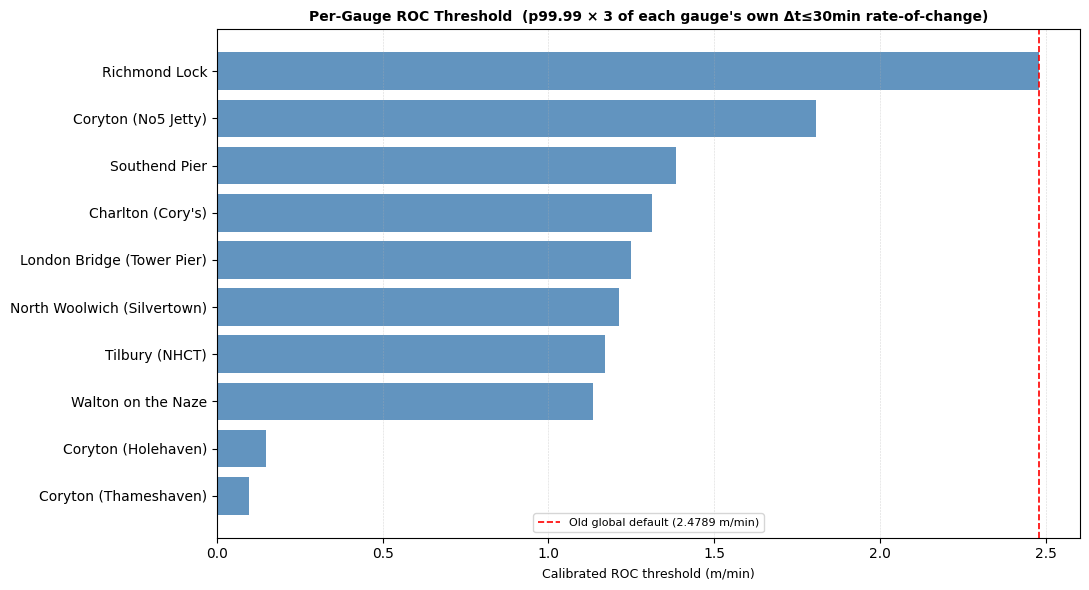

Saved → ../outputs/temporal_eda/eda_roc_threshold_per_gauge.png


In [7]:
fig, ax = plt.subplots(figsize=(11, 0.4 * len(roc_thresholds) + 2))
plot_order = roc_calibration.sort_values("roc_threshold_m_per_min")
colors = ["salmon" if v > ROC_THRESHOLD_M_PER_MIN else "steelblue"
          for v in plot_order["roc_threshold_m_per_min"]]
ax.barh(plot_order["SiteName"], plot_order["roc_threshold_m_per_min"], color=colors, alpha=0.85)
ax.axvline(ROC_THRESHOLD_M_PER_MIN, color="red", linestyle="--", linewidth=1.2,
           label=f"Old global default ({ROC_THRESHOLD_M_PER_MIN} m/min)")
ax.set_xlabel("Calibrated ROC threshold (m/min)", fontsize=9)
ax.set_title(
    f"Per-Gauge ROC Threshold  "
    f"(p{ROC_PERCENTILE} × {ROC_SAFETY_FACTOR} of each gauge's own Δt≤{ROC_MAX_GAP_MIN}min rate-of-change)",
    fontsize=10, fontweight="bold")
ax.legend(fontsize=8)
ax.grid(True, axis="x", linestyle="--", linewidth=0.4, alpha=0.5)
plt.tight_layout()

_roc_dir = os.path.join("..", "outputs", "temporal_eda")
os.makedirs(_roc_dir, exist_ok=True)
plt.savefig(os.path.join(_roc_dir, "eda_roc_threshold_per_gauge.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved → ../outputs/temporal_eda/eda_roc_threshold_per_gauge.png")

### Test on Southend Pier

Southend has one confirmed sensor fault: a single reading of ≈ −144.5 m against a normal range of ~0–7 m.

In [8]:
_key = "10_SOUTHEND"
df_test, meta_test = flag_gauge(gauges[_key], roc_threshold_m_per_min=roc_thresholds[_key])

print(f"Southend Pier — boundary window: [{meta_test['lower']:.3f}, {meta_test['upper']:.3f}] m")
print(f"  median={meta_test['median']:.3f} m,  MAD={meta_test['mad']:.3f} m,  "
      f"multiplier={BOUNDARY_MULTIPLIER}")
print(f"  ROC threshold (calibrated for this gauge) = {meta_test['roc_threshold_m_per_min']:.4f} m/min\n")

flagged_test = df_test[df_test["flag_boundary"] | df_test["flag_roc"]]
if flagged_test.empty:
    print("No flags raised.")
else:
    print(f"{len(flagged_test)} row(s) flagged:\n")
    display(flagged_test[["DateTime", "Observed", "flag_boundary", "flag_roc"]].reset_index(drop=True))

Southend Pier — boundary window: [-39.368, 45.292] m
  median=2.962 m,  MAD=1.411 m,  multiplier=30
  ROC threshold (calibrated for this gauge) = 1.3857 m/min

No flags raised.


### Run across all gauges

In [9]:
# Apply flags to every gauge; store flagged DataFrames back into gauges dict.
gauge_thresholds = {}
for gid, df in gauges.items():
    flagged_df, thresholds = flag_gauge(df, roc_threshold_m_per_min=roc_thresholds[gid])
    gauges[gid]          = flagged_df
    gauge_thresholds[gid] = thresholds

# ── Audit structure ───────────────────────────────────────────────────────────
# Extend this dict as additional cleaning steps are added.
audit = {
    gid: {
        "n_rows":        len(gdf),
        "flag_boundary": int(gdf["flag_boundary"].sum()),
        "flag_roc":      int(gdf["flag_roc"].sum()),
    }
    for gid, gdf in gauges.items()
}

# ── Summary table ─────────────────────────────────────────────────────────────
# Every flagged row across all gauges with context columns for manual review.
records = []
for gid, gdf in gauges.items():
    t    = gauge_thresholds[gid]
    site = gdf["SiteName"].iloc[0]
    mask = gdf["flag_boundary"] | gdf["flag_roc"]
    for _, row in gdf[mask].iterrows():
        records.append({
            "idSite":                  gid,
            "SiteName":                site,
            "DateTime":                row["DateTime"],
            "Observed":                row["Observed"],
            "flag_boundary":           row["flag_boundary"],
            "flag_roc":                row["flag_roc"],
            "boundary_lower":          round(t["lower"], 4),
            "boundary_upper":          round(t["upper"], 4),
            "roc_threshold_m_per_min": t["roc_threshold_m_per_min"],
        })

summary_flags = pd.DataFrame(records)
print(f"Total flagged rows across all gauges: {len(summary_flags)}\n")
display(summary_flags)

Total flagged rows across all gauges: 12



,idSite,SiteName,DateTime,Observed,flag_boundary,flag_roc,boundary_lower,boundary_upper,roc_threshold_m_per_min
0,09c_CORYTON_HOLEHAVEN,Coryton (Holehaven),2017-11-29 07:00:00,2.356,False,True,-42.382,48.698,0.146973
1,09c_CORYTON_HOLEHAVEN,Coryton (Holehaven),2017-11-29 07:10:00,3.883,False,True,-42.382,48.698,0.146973
2,09c_CORYTON_HOLEHAVEN,Coryton (Holehaven),2017-12-04 12:30:00,7.615,False,True,-42.382,48.698,0.146973
3,09c_CORYTON_HOLEHAVEN,Coryton (Holehaven),2017-12-04 12:40:00,11.463,False,True,-42.382,48.698,0.146973
4,09c_CORYTON_HOLEHAVEN,Coryton (Holehaven),2017-12-04 12:50:00,8.127,False,True,-42.382,48.698,0.146973
5,09c_CORYTON_HOLEHAVEN,Coryton (Holehaven),2017-12-04 13:00:00,5.274,False,True,-42.382,48.698,0.146973
6,09c_CORYTON_HOLEHAVEN,Coryton (Holehaven),2017-12-04 13:30:00,9.133,False,True,-42.382,48.698,0.146973
7,09c_CORYTON_HOLEHAVEN,Coryton (Holehaven),2017-12-04 13:40:00,5.784,False,True,-42.382,48.698,0.146973
8,09c_CORYTON_HOLEHAVEN,Coryton (Holehaven),2017-12-06 15:00:00,3.575,False,True,-42.382,48.698,0.146973
9,09c_CORYTON_HOLEHAVEN,Coryton (Holehaven),2017-12-06 15:20:00,5.704,False,True,-42.382,48.698,0.146973


In [10]:
print("=" * 65)
print("FAULT FLAGGING SUMMARY")
print(f"  Boundary multiplier : {BOUNDARY_MULTIPLIER} × MAD")
print(f"  ROC threshold       : {ROC_THRESHOLD_M_PER_MIN} m/min")
print("=" * 65)

no_flags = []
for gid, counts in audit.items():
    b = counts["flag_boundary"]
    r = counts["flag_roc"]
    if b == 0 and r == 0:
        no_flags.append(gid)
    else:
        site = gauges[gid]["SiteName"].iloc[0]
        print(f"\n{gid}  ({site})")
        print(f"  flag_boundary : {b}")
        print(f"  flag_roc      : {r}")

print(f"\n{'─' * 65}")
if no_flags:
    print("No flags raised for:")
    for gid in no_flags:
        print(f"  {gid}  ({gauges[gid]['SiteName'].iloc[0]})")
else:
    print("All gauges had at least one flag.")
print("=" * 65)

FAULT FLAGGING SUMMARY
  Boundary multiplier : 30 × MAD
  ROC threshold       : 2.4789 m/min

09c_CORYTON_HOLEHAVEN  (Coryton (Holehaven))
  flag_boundary : 0
  flag_roc      : 12

─────────────────────────────────────────────────────────────────
No flags raised for:
  10_SOUTHEND  (Southend Pier)
  09a_CORYTON_THAMESHAVEN  (Coryton (Thameshaven))
  09b_CORYTON_NO5JETTY  (Coryton (No5 Jetty))
  07_TILBURY  (Tilbury (NHCT))
  03_LONDONBRIDGE  (London Bridge (Tower Pier))
  13_WALTON  (Walton on the Naze)
  05_NORTHWOOLWICH  (North Woolwich (Silvertown))
  01_RICHMOND  (Richmond Lock)
  04_CHARLTON  (Charlton (Cory's))


### Assessing relevant data from 10/02/2015 at Southend Pier

Looking at the distribution of data to decide on the best way to replace the outlier.

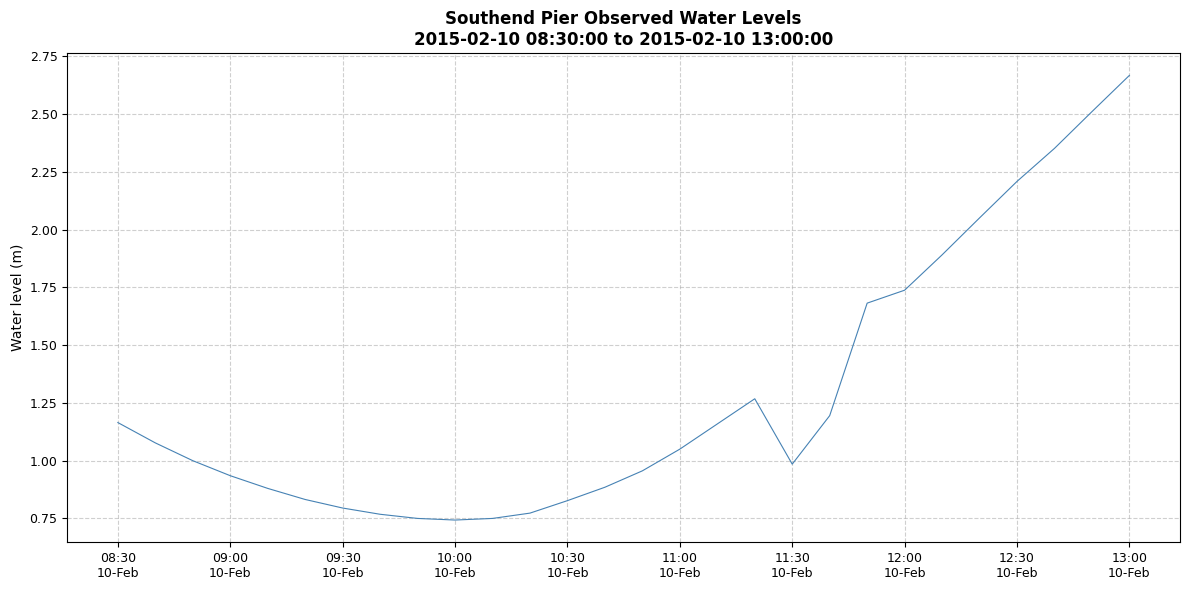

In [11]:
start_time_str = "2015-02-10 08:30:00" 
end_time_str   = "2015-02-10 13:00:00"

start_time = pd.to_datetime(start_time_str)
end_time = pd.to_datetime(end_time_str)

df_southend = gauges["10_SOUTHEND"].copy()

mask = (df_southend["DateTime"] >= start_time) & (df_southend["DateTime"] <= end_time)
df_window = df_southend[mask].copy()

if df_window.empty:
    print(f"No data found in the specified time window: {start_time_str} to {end_time_str}")
else:
    fig, ax = plt.subplots(figsize=(12, 6))

    ax.plot(df_window["DateTime"], df_window["Observed"], linewidth=0.8, color="steelblue", label="Observed")

    # Highlight flagged points
    flagged_points = df_window[df_window["flag_boundary"] | df_window["flag_roc"]]
    if not flagged_points.empty:
        ax.scatter(flagged_points["DateTime"], flagged_points["Observed"], color="salmon", s=30, label="Flagged Points")

        print("Anomalies in the specified window:")
        display(flagged_points[["DateTime", "Observed", "flag_boundary", "flag_roc"]].reset_index(drop=True))
    
    ax.set_title(f"Southend Pier Observed Water Levels\n{start_time_str} to {end_time_str}", fontsize=12, fontweight="bold")
    
    ax.set_ylabel("Water level (m)", fontsize=10)
    
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M\n%d-%b"))
    ax.tick_params(axis="x", rotation=0, labelsize=9)
    ax.tick_params(axis="y", labelsize=9)
    ax.grid(True, linestyle="--", alpha=0.6)

    # Only show legend if we plotted both lines and anomalies
    if not flagged_points.empty:
        ax.legend(fontsize=9)

    plt.tight_layout()
    plt.show()



C:\Users\alfat\AppData\Local\Temp\ipykernel_7732\2630108556.py:5: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  n_start_time = target_time - pd.Timedelta(hours=window_hours)
C:\Users\alfat\AppData\Local\Temp\ipykernel_7732\2630108556.py:6: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  n_end_time = target_time + pd.Timedelta(hours=window_hours)


Cleared ['flag_boundary', 'flag_roc'] on the corrected row → now included in downstream analysis.
✅ Successfully fixed the outlier!
Original Spiked Value  : 1.159 m
New Interpolated Value : 1.159 m

Audit entry: {'timestamp': '2015-02-10 11:10:00', 'original_value': np.float64(1.159), 'new_value': 1.159, 'method': 'linear interpolation'}


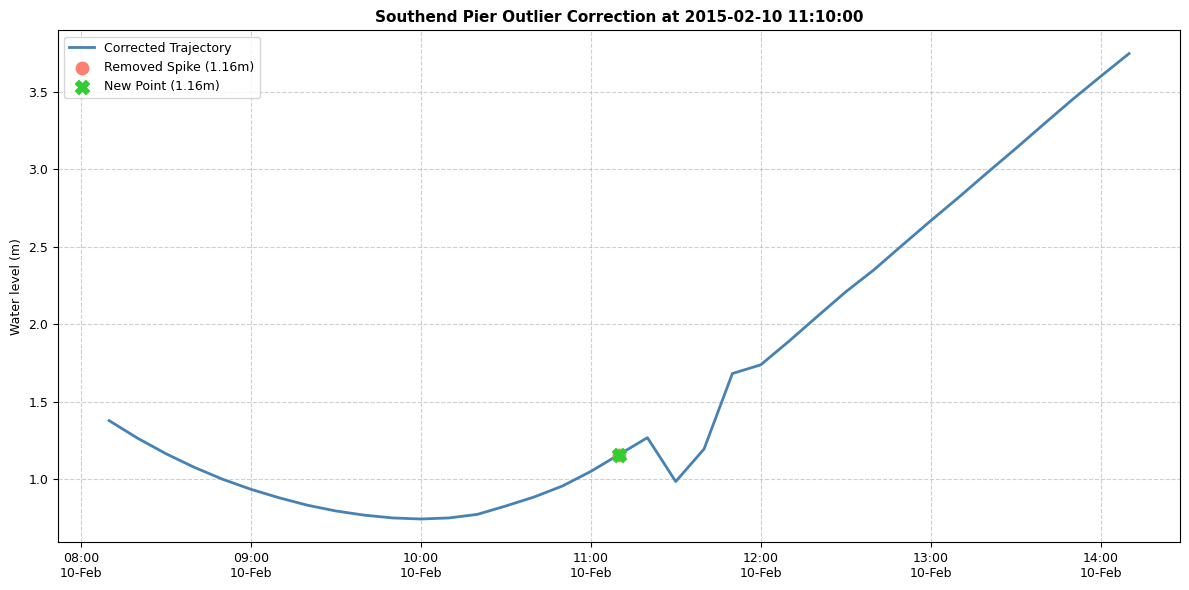

In [12]:
target_time_str = "2015-02-10 11:10:00"
target_time = pd.to_datetime(target_time_str)

window_hours = 3
n_start_time = target_time - pd.Timedelta(hours=window_hours)
n_end_time = target_time + pd.Timedelta(hours=window_hours)

mask = (df_southend["DateTime"] >= n_start_time) & (df_southend["DateTime"] <= n_end_time)
df_nwindow = df_southend[mask].copy()

try:
    original_value = df_nwindow.loc[df_nwindow["DateTime"] == target_time, "Observed"].iloc[0]
except IndexError:
    print("Target time not found in the window.")

df_nwindow.loc[df_nwindow["DateTime"] == target_time, "Observed"] = np.nan

# interpolate(method="time") requires a DatetimeIndex — set temporarily, then restore
df_nwindow = df_nwindow.set_index("DateTime")
df_nwindow["Observed"] = df_nwindow["Observed"].interpolate(method="time")
df_nwindow = df_nwindow.reset_index()

expected_value = df_nwindow.loc[df_nwindow["DateTime"] == target_time, "Observed"].iloc[0]

# Apply correction to in-memory gauges dict
gauges["10_SOUTHEND"].loc[gauges["10_SOUTHEND"]["DateTime"] == target_time, "Observed"] = expected_value
gauges["10_SOUTHEND"].loc[gauges["10_SOUTHEND"]["DateTime"] == target_time, "Observed_ODN"] = (
    expected_value - GAUGE_METADATA.loc["10_SOUTHEND", "ChartDatum_m_below_ODN"]
)

# Step 3: mark the imputed row
if "is_imputed" not in gauges["10_SOUTHEND"].columns:
    gauges["10_SOUTHEND"]["is_imputed"] = False
gauges["10_SOUTHEND"].loc[gauges["10_SOUTHEND"]["DateTime"] == target_time, "is_imputed"] = True

# Step 4: clear fault flags on the corrected row so it's included in downstream
# analysis. flag_boundary/flag_roc were set earlier (cell 9) when the raw
# -144.5 m spike was still present; is_imputed above keeps the row traceable
# as corrected without excluding it from EDA/correlation calculations.
_flag_cols = [c for c in gauges["10_SOUTHEND"].columns if c.startswith("flag_")]
gauges["10_SOUTHEND"].loc[gauges["10_SOUTHEND"]["DateTime"] == target_time, _flag_cols] = False
print(f"Cleared {_flag_cols} on the corrected row → now included in downstream analysis.")

# Step 5: log in the shared audit dict
if "corrections" not in audit["10_SOUTHEND"]:
    audit["10_SOUTHEND"]["corrections"] = []
audit["10_SOUTHEND"]["corrections"].append({
    "timestamp":      str(target_time),
    "original_value": original_value,
    "new_value":      round(float(expected_value), 6),
    "method":         "linear interpolation",
})

print("✅ Successfully fixed the outlier!")
print(f"Original Spiked Value  : {original_value:.3f} m")
print(f"New Interpolated Value : {expected_value:.3f} m\n")
print("Audit entry:", audit["10_SOUTHEND"]["corrections"][-1])

# Visualise the corrected time series around the target time
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df_nwindow["DateTime"], df_nwindow["Observed"],
        color="steelblue", linewidth=2, label="Corrected Trajectory")

ax.scatter([target_time], [original_value],
           color="salmon", s=80, zorder=5, label=f"Removed Spike ({original_value:.2f}m)")

ax.scatter([target_time], [expected_value],
           color="limegreen", s=100, zorder=5, marker="X", label=f"New Point ({expected_value:.2f}m)")

ax.plot([target_time, target_time], [original_value, expected_value],
        color="gray", linestyle=":", linewidth=1.5)

ax.set_title(f"Southend Pier Outlier Correction at {target_time}", fontsize=11, fontweight="bold")
ax.set_ylabel("Water level (m)", fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M\n%d-%b"))
ax.tick_params(axis="x", rotation=0, labelsize=9)
ax.tick_params(axis="y", labelsize=9)
ax.grid(True, linestyle="--", alpha=0.6)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

### Chatter-Fix / Stuck-Value-Fix Audit Entries

Two separate faults are detected and corrected in `EDA/utide_test.ipynb`, each via its own
4-stage FLAG / NULL / REFIT / PATCH pass, not here:

- multi-day episodes of high-frequency chatter near low water (float/mechanism fault, mostly pre-2016)
- multi-minute-to-hour stuck/flatline readings (gauge repeating one exact value), mostly pre-2016

That notebook writes its own durable audit record per pass; the cell below just pulls both
into the shared `audit` dict so every correction is logged in one place. `gauges["10_SOUTHEND"]`
itself is **not** patched by this cell -- the corrected series lives in
`3_Cleaned/10_SOUTHEND_chatter_patched.csv` (chatter only) and
`3_Cleaned/10_SOUTHEND_chatter_and_stuck_patched.csv` (both fixes) for review before either is
promoted to the canonical `3_Cleaned/10_SOUTHEND.csv`.

In [ ]:
# Chatter-fix and stuck-value-fix audit entries -- see EDA/utide_test.ipynb for
# the actual detection/refit/patch pipelines (two passes, same 4-stage pattern).
# This cell only records both passes in the shared audit dict so provenance
# stays in one place; it does NOT modify gauges["10_SOUTHEND"] itself.
import glob
import json

if "chatter_corrections" not in audit["10_SOUTHEND"]:
    audit["10_SOUTHEND"]["chatter_corrections"] = []

_audit_log_paths = sorted(glob.glob(os.path.join("..", "outputs", "temporal_eda", "southend_*_audit_log.json")))
if _audit_log_paths:
    for _p in _audit_log_paths:
        with open(_p) as f:
            _entry = json.load(f)
        audit["10_SOUTHEND"]["chatter_corrections"].append(_entry)
        print(f"Logged '{_entry.get('pass')}' into audit['10_SOUTHEND']['chatter_corrections']:")
        print(json.dumps(_entry, indent=2))
else:
    print("[SKIP] no outputs/temporal_eda/southend_*_audit_log.json found -- "
          "run EDA/utide_test.ipynb Stages 1-4 first.")

## Per-Gauge Temporal EDA

Compute a diagnostic dict per gauge using `compute_gauge_diagnostics()`. All outputs go to `../outputs/temporal_eda/`.

Each result dict contains:
- **(a)** Distribution: histogram values + descriptive stats (n, min, max, mean, median, std, p1, p99, skew, kurtosis)
- **(b)** Daily-mean resample — isolates multi-year trends from the tidal signal for (c)
- **(c)** ADF + KPSS stationarity tests on the daily-mean series (5 % level)
- **(f)** Longest contiguous native-resolution block; flagged if < 90 days
- **(g)** ACF on the contiguous block — out to ≥ 1 spring-neap cycle (14.77 days), FFT-accelerated
- **(h)** PACF on the same block — capped at 2 days
- **(i)** Lomb-Scargle periodogram on the full gappy series (1/365 – 12 cycles/day)
- **(j)** Annual mean water level
- **(l)** ACF/PACF on the first-differenced daily-mean series — checks whether ordinary differencing resolves the non-stationarity found in (c)
- **(m)** ACF/PACF on the native contiguous block, seasonally differenced at the dominant semi-diurnal (M2) lag (~745 min) — strips the tidal cycle out to look for residual structure

Dropped from the original design (see EDA critique discussion): STL decomposition (relied on unlimited-length linear interpolation across gaps — not trustworthy for gappy gauges), rolling mean/variance and the rolling tidal-range estimate (both are sliding time-windows biased by missing data; see the Data Completeness Filter above for the gauge-inclusion approach used instead). The Lomb-Scargle periodogram no longer labels tidal-constituent frequencies (O1/K1/M2/S2/...), since a periodogram peak alone doesn't identify a constituent without a proper harmonic analysis.

In [13]:
#import os
import warnings
#import numpy as np
from scipy import stats as sp_stats
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf

try:
    from astropy.timeseries import LombScargle as AstroLS
    _ASTROPY = True
    print("astropy available  — Lomb-Scargle will use astropy.timeseries.LombScargle")
except ImportError:
    from scipy.signal import lombscargle as _scipy_ls
    _ASTROPY = False
    print("astropy not found  — Lomb-Scargle will fall back to scipy.signal.lombscargle")

TEMPORAL_EDA_DIR = os.path.join("..", "outputs", "temporal_eda")
os.makedirs(TEMPORAL_EDA_DIR, exist_ok=True)
print(f"Output dir: {os.path.abspath(TEMPORAL_EDA_DIR)}")

astropy available  — Lomb-Scargle will use astropy.timeseries.LombScargle
Output dir: c:\Users\alfat\Documents\STA_MSc\Term_3\tidal_analysis_and_prediction\outputs\temporal_eda


In [14]:
def compute_gauge_diagnostics(df, site_name, value_col="Observed_ODN"):
    """
    Compute temporal EDA diagnostics for one gauge DataFrame.

    df must have 'DateTime' and `value_col` columns (default: 'Observed_ODN').
    flag_boundary / flag_roc columns are used to exclude faulted rows if present.
    Does NOT modify df or write any files.

    Returns a dict with keys:
        site_name, modal_dt_s, modal_dt_min, block,
        dist, daily, adf, kpss_c, kpss_ct,
        acf_daily_diff, pacf_daily_diff, daily_diff_n,
        acf, pacf,
        acf_seasonal_diff, pacf_seasonal_diff, seasonal_diff_lag,
        periodogram, annual_mean
    """
    result = {"site_name": site_name}

    # ── Filter flagged rows, drop NaN Observed ────────────────────────────
    flag_cols = [c for c in df.columns if c.startswith("flag_")]
    if flag_cols:
        df_c = df[~df[flag_cols].any(axis=1)].copy()
    else:
        df_c = df.copy()
    df_c = (df_c.dropna(subset=[value_col])
                .sort_values("DateTime")
                .reset_index(drop=True))

    # ── Modal sampling interval ───────────────────────────────────────────
    dt_s   = df_c["DateTime"].diff().dt.total_seconds()
    pos_dt = dt_s[dt_s > 0]
    modal  = float(pos_dt.mode()[0])
    result["modal_dt_s"]   = modal
    result["modal_dt_min"] = modal / 60.0

    # ── (f) Longest contiguous native-resolution block ────────────────────
    is_break = (dt_s > modal * 1.5).fillna(True)
    blk_id   = is_break.cumsum()
    best_blk = df_c.groupby(blk_id).size().idxmax()
    blk      = df_c[blk_id == best_blk].reset_index(drop=True)
    b_start  = blk["DateTime"].iloc[0]
    b_end    = blk["DateTime"].iloc[-1]
    b_days   = (b_end - b_start).total_seconds() / 86400.0
    result["block"] = {
        "start":  b_start,
        "end":    b_end,
        "n_rows": int(len(blk)),
        "days":   b_days,
        "short":  b_days < 90.0,
    }

    # ── (a) Distribution stats ────────────────────────────────────────────
    obs = df_c[value_col]
    result["dist"] = {
        "values":   obs.values,
        "n":        int(len(obs)),
        "min":      float(obs.min()),
        "max":      float(obs.max()),
        "mean":     float(obs.mean()),
        "median":   float(obs.median()),
        "std":      float(obs.std()),
        "p1":       float(obs.quantile(0.01)),
        "p99":      float(obs.quantile(0.99)),
        "skew":     float(sp_stats.skew(obs.values)),
        "kurtosis": float(sp_stats.kurtosis(obs.values)),
    }

    # ── (b) Daily-mean resample ───────────────────────────────────────────
    obs_ts    = df_c.set_index("DateTime")[value_col].sort_index()
    daily_raw = obs_ts.resample("D").mean()           # full daily grid, NaN for gap days
    daily     = daily_raw.dropna()                    # real-observation days only
    result["daily"] = daily

    # ── (c) ADF & KPSS on daily-mean series ──────────────────────────────
    # Use dropna series; gap days are treated as consecutive (standard EDA approximation).
    dv = daily.values
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        adf_res     = adfuller(dv, autolag="AIC")
        kpss_c_res  = kpss(dv, regression="c",  nlags="auto")
        kpss_ct_res = kpss(dv, regression="ct", nlags="auto")

    # ADF  H0: unit root (non-stationary). Reject if p < 0.05 → stationary.
    # KPSS H0: stationary.               Reject if p < 0.05 → non-stationary.
    # KPSS p-value is bounded to [0.01, 0.10] in statsmodels.
    result["adf"] = {
        "stat":       float(adf_res[0]),
        "pvalue":     float(adf_res[1]),
        "conclusion": "stationary" if adf_res[1] < 0.05 else "non-stationary",
    }
    result["kpss_c"] = {
        "stat":       float(kpss_c_res[0]),
        "pvalue":     float(kpss_c_res[1]),
        "conclusion": "non-stationary" if kpss_c_res[1] < 0.05 else "stationary",
    }
    result["kpss_ct"] = {
        "stat":       float(kpss_ct_res[0]),
        "pvalue":     float(kpss_ct_res[1]),
        "conclusion": "non-stationary" if kpss_ct_res[1] < 0.05 else "stationary",
    }

    # ── (l) ACF/PACF on first-differenced daily-mean series ──────────────
    # Directly follows up on (c): does one round of ordinary differencing
    # resolve the non-stationarity ADF/KPSS found in the daily-mean series?
    daily_diff = daily.diff().dropna()
    result["daily_diff_n"] = int(len(daily_diff))

    dd_acf_nlags = min(400, len(daily_diff) - 2)
    if dd_acf_nlags > 1:
        acf_dd_v, acf_dd_ci = acf(daily_diff.values, nlags=dd_acf_nlags, fft=True, alpha=0.05)
        result["acf_daily_diff"] = {
            "lags":    np.arange(len(acf_dd_v)),
            "values":  acf_dd_v,
            "ci_low":  acf_dd_ci[:, 0],
            "ci_high": acf_dd_ci[:, 1],
        }
    else:
        result["acf_daily_diff"] = None

    dd_pacf_nlags = min(40, len(daily_diff) // 2 - 1)
    if dd_pacf_nlags > 1:
        pacf_dd_v, pacf_dd_ci = pacf(daily_diff.values, nlags=dd_pacf_nlags, alpha=0.05, method="ywm")
        result["pacf_daily_diff"] = {
            "lags":    np.arange(len(pacf_dd_v)),
            "values":  pacf_dd_v,
            "ci_low":  pacf_dd_ci[:, 0],
            "ci_high": pacf_dd_ci[:, 1],
        }
    else:
        result["pacf_daily_diff"] = None

    # ── (g) ACF on contiguous block ───────────────────────────────────────
    blk_obs   = blk[value_col].values
    acf_nlags = min(
        int(np.ceil(14.77 * 24.0 * 60.0 / result["modal_dt_min"])),
        len(blk_obs) - 2,
    )
    if acf_nlags > 1:
        acf_v, acf_ci = acf(blk_obs, nlags=acf_nlags, fft=True, alpha=0.05)
        result["acf"] = {
            "lags":    np.arange(len(acf_v)),
            "values":  acf_v,
            "ci_low":  acf_ci[:, 0],   # absolute lower CI bound per lag
            "ci_high": acf_ci[:, 1],   # absolute upper CI bound per lag
        }
    else:
        result["acf"] = None

    # ── (h) PACF on contiguous block ─────────────────────────────────────
    # Cap at 2 days to show decorrelation length without excessive cost.
    pacf_nlags = min(
        int(np.ceil(2.0 * 24.0 * 60.0 / result["modal_dt_min"])),
        len(blk_obs) // 2 - 1,
    )
    if pacf_nlags > 1:
        pacf_v, pacf_ci = pacf(blk_obs, nlags=pacf_nlags, alpha=0.05, method="ywm")
        result["pacf"] = {
            "lags":    np.arange(len(pacf_v)),
            "values":  pacf_v,
            "ci_low":  pacf_ci[:, 0],
            "ci_high": pacf_ci[:, 1],
        }
    else:
        result["pacf"] = None

    # ── (m) ACF/PACF on native block, seasonally differenced at M2 lag ───
    # Differences the native series at the dominant semi-diurnal (M2) lag
    # (~745 min) to strip the tidal cycle out and look for residual structure.
    seasonal_lag = max(1, round(745.0 / result["modal_dt_min"]))
    result["seasonal_diff_lag"] = seasonal_lag
    blk_obs_sdiff = pd.Series(blk_obs).diff(seasonal_lag).dropna().values

    sd_acf_nlags = min(
        int(np.ceil(14.77 * 24.0 * 60.0 / result["modal_dt_min"])),
        len(blk_obs_sdiff) - 2,
    )
    if sd_acf_nlags > 1:
        acf_sd_v, acf_sd_ci = acf(blk_obs_sdiff, nlags=sd_acf_nlags, fft=True, alpha=0.05)
        result["acf_seasonal_diff"] = {
            "lags":    np.arange(len(acf_sd_v)),
            "values":  acf_sd_v,
            "ci_low":  acf_sd_ci[:, 0],
            "ci_high": acf_sd_ci[:, 1],
        }
    else:
        result["acf_seasonal_diff"] = None

    sd_pacf_nlags = min(
        int(np.ceil(2.0 * 24.0 * 60.0 / result["modal_dt_min"])),
        len(blk_obs_sdiff) // 2 - 1,
    )
    if sd_pacf_nlags > 1:
        pacf_sd_v, pacf_sd_ci = pacf(blk_obs_sdiff, nlags=sd_pacf_nlags, alpha=0.05, method="ywm")
        result["pacf_seasonal_diff"] = {
            "lags":    np.arange(len(pacf_sd_v)),
            "values":  pacf_sd_v,
            "ci_low":  pacf_sd_ci[:, 0],
            "ci_high": pacf_sd_ci[:, 1],
        }
    else:
        result["pacf_seasonal_diff"] = None

    # ── (i) Lomb-Scargle on full native series ────────────────────────────
    # Uses the whole multi-decade record, including gaps — designed for this.
    t_days       = (df_c["DateTime"] - df_c["DateTime"].iloc[0]).dt.total_seconds().values / 86400.0
    obs_demeaned = df_c[value_col].values - float(df_c[value_col].mean())
    freq_grid    = np.linspace(1.0 / 365.25, 12.0, 2000)   # cycles per day

    if _ASTROPY:
        # astropy evaluates each frequency independently — no N×M allocation.
        _ls_obj  = AstroLS(t_days, obs_demeaned)
        power_ls = np.asarray(_ls_obj.power(freq_grid))
    else:
        # scipy.signal.lombscargle allocates an (N, M) matrix internally.
        # Processing in small chunks keeps peak memory to N × chunk × 8 bytes.
        # At N=1.1M and chunk=10: ~88 MB per batch — safe on any machine.
        ang_freq = 2.0 * np.pi * freq_grid
        power_ls = np.empty(len(ang_freq))
        _chunk   = 10
        for _i in range(0, len(ang_freq), _chunk):
            power_ls[_i : _i + _chunk] = _scipy_ls(
                t_days, obs_demeaned, ang_freq[_i : _i + _chunk], normalize=True
            )

    result["periodogram"] = {"frequency": freq_grid, "power": power_ls}

    # ── (j) Annual mean ───────────────────────────────────────────────────
    result["annual_mean"] = obs_ts.resample("YE").mean().dropna()

    return result


In [15]:
# Validation test — superseded by the full loop below, which already covers these gauges. Uncomment only when compute_gauge_diagnostics() itself changes and needs re-validating before a full run.
# _TEST_KEYS = ["10_SOUTHEND", "09a_CORYTON_THAMESHAVEN", "06_ERITH"]
# _SEP = "━" * 62

# print("Running compute_gauge_diagnostics on 3 test gauges …")
# print("(ADF/KPSS and STL may take ~20–60 s per gauge on the full series)\n")

# for _key in _TEST_KEYS:
#     _gdf  = gauges[_key].copy()
#     _site = _gdf["SiteName"].iloc[0]
#     print(_SEP)
#     print(f"  {_site}  ({_key})")
#     _d  = compute_gauge_diagnostics(_gdf, _site)
#     _ds = _d["dist"]
#     _bl = _d["block"]
#     _ad    = _d["adf"]
#     _kp_c  = _d["kpss_c"]
#     _kp_ct = _d["kpss_ct"]
#     print(f"  Modal dt     : {_d['modal_dt_s']:.0f} s  ({_d['modal_dt_min']:.1f} min)\n")
#     print(f"  Distribution (n = {_ds['n']:,}, unflagged Observed):")
#     print(f"    min    : {_ds['min']:>10.3f} m    p1   : {_ds['p1']:>9.3f} m")
#     print(f"    max    : {_ds['max']:>10.3f} m    p99  : {_ds['p99']:>9.3f} m")
#     print(f"    mean   : {_ds['mean']:>10.3f} m    median: {_ds['median']:>8.3f} m")
#     print(f"    std    : {_ds['std']:>10.3f} m")
#     print(f"    skew   : {_ds['skew']:>10.3f}    kurtosis: {_ds['kurtosis']:>7.3f}\n")
#     _flag = "  *** SHORT BLOCK ***" if _bl["short"] else ""
#     print(f"  Contiguous block:")
#     print(f"    {_bl['start'].strftime('%Y-%m-%d')} → {_bl['end'].strftime('%Y-%m-%d')}"
#           f"  ({_bl['n_rows']:,} rows, {_bl['days']:.1f} days){_flag}\n")
#     print(f"  Stationarity (daily-mean series):")
#     print(f"    ADF      stat={_ad['stat']:>9.4f}  p={_ad['pvalue']:.4f}  → {_ad['conclusion']}")
#     print(f"    KPSS(c)  stat={_kp_c['stat']:>9.4f}  p={_kp_c['pvalue']:.4f}  → {_kp_c['conclusion']}")
#     print(f"    KPSS(ct) stat={_kp_ct['stat']:>9.4f}  p={_kp_ct['pvalue']:.4f}  → {_kp_ct['conclusion']}")
#     print()

# print(_SEP)
# print("Test complete. Confirm output before running full loop.")

---
> The validation test above is commented out (already confirmed against `compute_gauge_diagnostics`). Uncomment it if the function changes and needs re-checking on a few gauges before the full-loop and plotting/CSV cells below.

In [16]:
import time, sys

gauge_diags = {}
_log_lines  = []

def _log(s=""):
    print(s)
    _log_lines.append(str(s))

_log("=" * 65)
_log("TEMPORAL EDA FULL LOOP")
_log("=" * 65)
_log()

for gid, gdf in gauges.items():
    site = gdf["SiteName"].iloc[0]
    t0   = time.time()
    d    = compute_gauge_diagnostics(gdf.copy(), site)
    gauge_diags[gid] = d
    elapsed = time.time() - t0

    ds, bl, ad, kp_c, kp_ct = d["dist"], d["block"], d["adf"], d["kpss_c"], d["kpss_ct"]
    short_tag = "  [SHORT BLOCK]" if bl["short"] else ""
    _log(f"{gid}  ({site})")
    _log(f"  Observed_ODN  min={ds['min']:.3f}  mean={ds['mean']:.3f}  max={ds['max']:.3f} m")
    _log(f"  block:  {bl['start'].strftime('%Y-%m-%d')} → {bl['end'].strftime('%Y-%m-%d')}"
         f"  ({bl['n_rows']:,} rows, {bl['days']:.0f} days){short_tag}")
    _log(f"  ADF: {ad['conclusion']:<15}  KPSS(c): {kp_c['conclusion']:<15}  KPSS(ct): {kp_ct['conclusion']}  [{elapsed:.0f} s]")
    _log()
    sys.stdout.flush()

_log("─" * 65)
_log(f"Done.  {len(gauge_diags)} gauges processed.")
_log("=" * 65)

_log_path = os.path.join(TEMPORAL_EDA_DIR, "run_log.txt")
with open(_log_path, "w", encoding="utf-8") as _f:
    _f.write("\n".join(_log_lines))
print(f"\nLog → {_log_path}")

TEMPORAL EDA FULL LOOP



09c_CORYTON_HOLEHAVEN  (Coryton (Holehaven))
  Observed_ODN  min=-2.845  mean=0.210  max=3.986 m
  block:  2016-05-07 → 2017-11-29  (82,131 rows, 570 days)
  ADF: stationary       KPSS(c): non-stationary   KPSS(ct): stationary  [12 s]



10_SOUTHEND  (Southend Pier)
  Observed_ODN  min=-3.394  mean=0.170  max=4.136 m
  block:  2016-07-18 → 2022-08-25  (320,956 rows, 2229 days)
  ADF: stationary       KPSS(c): non-stationary   KPSS(ct): non-stationary  [141 s]



09a_CORYTON_THAMESHAVEN  (Coryton (Thameshaven))
  Observed_ODN  min=-3.405  mean=0.283  max=4.345 m
  block:  2018-01-01 → 2021-08-13  (190,140 rows, 1320 days)
  ADF: stationary       KPSS(c): non-stationary   KPSS(ct): stationary  [80 s]



09b_CORYTON_NO5JETTY  (Coryton (No5 Jetty))
  Observed_ODN  min=-3.770  mean=0.011  max=4.919 m
  block:  2014-08-11 → 2014-12-09  (17,286 rows, 120 days)
  ADF: stationary       KPSS(c): non-stationary   KPSS(ct): non-stationary  [11 s]



...

13_WALTON  (Walton on the Naze)
  Observed_ODN  min=-4.043  mean=0.122  max=4.022 m
  block:  2018-03-09 → 2020-06-29  (121,384 rows, 843 days)
  ADF: stationary       KPSS(c): non-stationary   KPSS(ct): non-stationary  [26 s]



05_NORTHWOOLWICH  (North Woolwich (Silvertown))
  Observed_ODN  min=-5.520  mean=0.392  max=5.420 m
  block:  2014-05-20 → 2015-04-12  (47,161 rows, 328 days)
  ADF: stationary       KPSS(c): non-stationary   KPSS(ct): stationary  [19 s]



01_RICHMOND  (Richmond Lock)
  Observed_ODN  min=-1.860  mean=1.444  max=17.241 m
  block:  2009-08-24 → 2010-08-14  (51,046 rows, 354 days)
  ADF: stationary       KPSS(c): non-stationary   KPSS(ct): stationary  [19 s]



04_CHARLTON  (Charlton (Cory's))
  Observed_ODN  min=-5.700  mean=0.412  max=7.040 m
  block:  2013-02-06 → 2013-07-31  (25,282 rows, 176 days)
  ADF: stationary       KPSS(c): stationary       KPSS(ct): stationary  [17 s]



─────────────────────────────────────────────────────────────────
Done.  10 gauges processed.

Log → ..\outputs\temporal_eda\run_log.txt


In [17]:
# ── Shared grid helpers ───────────────────────────────────────────────────
_GKEYS = list(gauge_diags.keys())
_N     = len(_GKEYS)
_NCOLS = 2
_NROWS = (_N + _NCOLS - 1) // _NCOLS

def _grid(title, h_per_row=3.5):
    fig, axes = plt.subplots(_NROWS, _NCOLS, figsize=(18, _NROWS * h_per_row))
    axes = axes.flatten()
    fig.suptitle(title, fontsize=13, fontweight="bold", y=1.01)
    return fig, axes

def _save(fig, axes, fpath):
    for ax in axes[_N:]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.savefig(fpath, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"  Saved {os.path.basename(fpath)}")


# ── (a) Distribution ──────────────────────────────────────────────────────
def plot_distribution_grid():
    from scipy.stats import gaussian_kde
    bw     = 0.05
    p1_all  = min(gauge_diags[k]["dist"]["p1"]  for k in _GKEYS)
    p99_all = max(gauge_diags[k]["dist"]["p99"] for k in _GKEYS)
    bins   = np.arange(np.floor(p1_all  / bw) * bw,
                       np.ceil(p99_all  / bw) * bw + bw, bw)

    fig, axes = _grid("ODN-Referenced Water Level Distribution  (bin width = 0.05 m)")
    for ax, gid in zip(axes, _GKEYS):
        d = gauge_diags[gid]
        v = d["dist"]["values"]
        ax.hist(v, bins=bins, density=True,
                color="steelblue", alpha=0.7, edgecolor="none")
        kde = gaussian_kde(v[::50])          # subsample for speed
        x   = np.linspace(bins[0], bins[-1], 400)
        ax.plot(x, kde(x), color="darkblue", linewidth=1.2)
        ax.set_title(f"{d['site_name']}  (n={d['dist']['n']:,})",
                     fontsize=8, fontweight="bold")
        ax.set_xlabel("Water level (m)", fontsize=7)
        ax.set_xlim(bins[0], bins[-1])
        ax.tick_params(labelsize=7)
        ax.grid(True, linestyle="--", linewidth=0.3, alpha=0.6)
    _save(fig, axes, os.path.join(TEMPORAL_EDA_DIR, "eda_distribution_all.png"))


In [18]:
# ── (g/h) ACF + PACF — native contiguous block ───────────────────────────
def _acf_pacf_panel(ax, d, key):
    bl     = d["block"]
    dt_min = d["modal_dt_min"]
    short  = bl["short"]
    title_col = "firebrick" if short else "black"
    suffix    = " (short block)" if short else ""
    ax.set_title(
        f"{d['site_name']}{suffix}\n"
        f"{bl['start'].strftime('%Y-%m-%d')} → {bl['end'].strftime('%Y-%m-%d')}",
        fontsize=7, fontweight="bold", color=title_col,
    )
    data = d[key]
    if data is None:
        ax.text(0.5, 0.5, "insufficient data", ha="center", va="center",
                transform=ax.transAxes, fontsize=8)
        return
    lags_h = data["lags"] * dt_min / 60.0
    ax.bar(lags_h, data["values"], width=dt_min / 60.0,
           color="steelblue", alpha=0.8, linewidth=0)
    band = 1.96 / np.sqrt(bl["n_rows"])
    ax.axhline(+band, color="red", linestyle="--", linewidth=0.8)
    ax.axhline(-band, color="red", linestyle="--", linewidth=0.8)
    ax.axhline(0,     color="black", linewidth=0.5)
    ax.set_xlabel("Lag (hours)", fontsize=7)
    ax.tick_params(labelsize=7)
    ax.grid(True, linestyle="--", linewidth=0.3, alpha=0.4)

def plot_acf_grid():
    fig, axes = _grid("ACF — Longest Contiguous Block  (≥ 1 spring-neap cycle)", h_per_row=3.2)
    for ax, gid in zip(axes, _GKEYS):
        _acf_pacf_panel(ax, gauge_diags[gid], "acf")
    _save(fig, axes, os.path.join(TEMPORAL_EDA_DIR, "eda_acf_all.png"))

def plot_pacf_grid():
    fig, axes = _grid("PACF — Longest Contiguous Block  (2-day cap)", h_per_row=3.2)
    for ax, gid in zip(axes, _GKEYS):
        _acf_pacf_panel(ax, gauge_diags[gid], "pacf")
    _save(fig, axes, os.path.join(TEMPORAL_EDA_DIR, "eda_pacf_all.png"))


# ── (m) ACF + PACF — native block, seasonally differenced at M2 lag ─────
# Reuses _acf_pacf_panel: same "lags"/"values" shape, same block/dt_min-based
# x-axis and CI band as the native ACF/PACF above.
def plot_acf_seasonal_diff_grid():
    fig, axes = _grid("ACF — Native Block, Seasonally Differenced at M2 Lag (~745 min)", h_per_row=3.2)
    for ax, gid in zip(axes, _GKEYS):
        _acf_pacf_panel(ax, gauge_diags[gid], "acf_seasonal_diff")
    _save(fig, axes, os.path.join(TEMPORAL_EDA_DIR, "eda_acf_seasonal_diff_all.png"))

def plot_pacf_seasonal_diff_grid():
    fig, axes = _grid("PACF — Native Block, Seasonally Differenced at M2 Lag (~745 min)", h_per_row=3.2)
    for ax, gid in zip(axes, _GKEYS):
        _acf_pacf_panel(ax, gauge_diags[gid], "pacf_seasonal_diff")
    _save(fig, axes, os.path.join(TEMPORAL_EDA_DIR, "eda_pacf_seasonal_diff_all.png"))


# ── (l) ACF + PACF — first-differenced daily-mean series ────────────────
# Different x-axis unit (days, not hours) and a different CI sample size
# (daily_diff_n) than the native-block panel above, so this gets its own
# small panel helper rather than reusing _acf_pacf_panel.
def _acf_pacf_daily_diff_panel(ax, d, key):
    ax.set_title(d["site_name"], fontsize=7, fontweight="bold")
    data = d[key]
    if data is None:
        ax.text(0.5, 0.5, "insufficient data", ha="center", va="center",
                transform=ax.transAxes, fontsize=8)
        return
    ax.bar(data["lags"], data["values"], width=0.8,
           color="steelblue", alpha=0.8, linewidth=0)
    band = 1.96 / np.sqrt(d["daily_diff_n"])
    ax.axhline(+band, color="red", linestyle="--", linewidth=0.8)
    ax.axhline(-band, color="red", linestyle="--", linewidth=0.8)
    ax.axhline(0,     color="black", linewidth=0.5)
    ax.set_xlabel("Lag (days)", fontsize=7)
    ax.tick_params(labelsize=7)
    ax.grid(True, linestyle="--", linewidth=0.3, alpha=0.4)

def plot_acf_daily_diff_grid():
    fig, axes = _grid("ACF — First-Differenced Daily-Mean Series", h_per_row=3.0)
    for ax, gid in zip(axes, _GKEYS):
        _acf_pacf_daily_diff_panel(ax, gauge_diags[gid], "acf_daily_diff")
    _save(fig, axes, os.path.join(TEMPORAL_EDA_DIR, "eda_acf_daily_diff_all.png"))

def plot_pacf_daily_diff_grid():
    fig, axes = _grid("PACF — First-Differenced Daily-Mean Series", h_per_row=3.0)
    for ax, gid in zip(axes, _GKEYS):
        _acf_pacf_daily_diff_panel(ax, gauge_diags[gid], "pacf_daily_diff")
    _save(fig, axes, os.path.join(TEMPORAL_EDA_DIR, "eda_pacf_daily_diff_all.png"))


# ── (i) Periodogram ───────────────────────────────────────────────────────
# No tidal-constituent reference lines: a Lomb-Scargle peak near a
# constituent frequency isn't a confirmed identification without a proper
# harmonic analysis, so labelling O1/K1/M2/S2/... here would overstate it.
def plot_periodogram_grid():
    fig, axes = _grid("Lomb-Scargle Periodogram — Full Native Series  (log power)", h_per_row=3.0)
    for ax, gid in zip(axes, _GKEYS):
        d   = gauge_diags[gid]
        pg  = d["periodogram"]
        pwr = np.where(pg["power"] > 0, pg["power"], 1e-30)
        ax.semilogy(pg["frequency"], pwr, linewidth=0.5, color="steelblue")
        ax.set_title(d["site_name"], fontsize=8, fontweight="bold")
        ax.set_xlabel("Frequency (cycles / day)", fontsize=7)
        ax.set_ylabel("Power (log)", fontsize=7)
        ax.tick_params(labelsize=7)
        ax.grid(True, linestyle="--", linewidth=0.3, alpha=0.4, which="both")
    _save(fig, axes, os.path.join(TEMPORAL_EDA_DIR, "eda_periodogram_all.png"))


# ── (j) Annual mean ───────────────────────────────────────────────────────
def plot_annual_mean_grid():
    fig, axes = _grid("Annual Mean Water Level")
    for ax, gid in zip(axes, _GKEYS):
        d  = gauge_diags[gid]
        am = d["annual_mean"]
        ax.bar(am.index.year, am.values, color="steelblue", alpha=0.85, width=0.8)
        ax.set_title(d["site_name"], fontsize=8, fontweight="bold")
        ax.set_ylabel("m", fontsize=7)
        ax.tick_params(labelsize=7)
        ax.grid(True, linestyle="--", linewidth=0.3, alpha=0.6, axis="y")
    _save(fig, axes, os.path.join(TEMPORAL_EDA_DIR, "eda_annual_mean_all.png"))


# ── ADF / KPSS(c) / KPSS(ct) summary bar chart ──────────────────────────────────────
def plot_adf_kpss_summary():
    # Asymptotic 5% critical values (large-sample)
    ADF_CV5     = -2.86
    KPSS_C_CV5  =  0.463   # constant-only regression
    KPSS_CT_CV5 =  0.146   # constant + trend regression

    sites       = [gauge_diags[k]["site_name"]       for k in _GKEYS]
    adf_stats   = [gauge_diags[k]["adf"]["stat"]     for k in _GKEYS]
    kp_c_stats  = [gauge_diags[k]["kpss_c"]["stat"]  for k in _GKEYS]
    kp_ct_stats = [gauge_diags[k]["kpss_ct"]["stat"] for k in _GKEYS]
    y = np.arange(_N)

    col_adf   = ["steelblue" if s < ADF_CV5     else "salmon" for s in adf_stats]
    col_kp_c  = ["salmon"    if s > KPSS_C_CV5  else "steelblue" for s in kp_c_stats]
    col_kp_ct = ["salmon"    if s > KPSS_CT_CV5 else "steelblue" for s in kp_ct_stats]

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(21, max(6, _N * 0.55)))

    ax1.barh(y, adf_stats, color=col_adf, alpha=0.85, height=0.7)
    ax1.axvline(ADF_CV5, color="red", linestyle="--", linewidth=1.2,
                label=f"5 % CV ≈ {ADF_CV5}")
    ax1.set_yticks(y); ax1.set_yticklabels(sites, fontsize=8)
    ax1.set_xlabel("ADF test statistic", fontsize=9)
    ax1.set_title("ADF  (more negative → reject unit root → stationary)",
                  fontsize=9, fontweight="bold")
    ax1.invert_yaxis(); ax1.legend(fontsize=8)
    ax1.grid(True, axis="x", linestyle="--", linewidth=0.4, alpha=0.6)

    ax2.barh(y, kp_c_stats, color=col_kp_c, alpha=0.85, height=0.7)
    ax2.axvline(KPSS_C_CV5, color="red", linestyle="--", linewidth=1.2,
                label=f"5 % CV ≈ {KPSS_C_CV5}")
    ax2.set_yticks(y); ax2.set_yticklabels(sites, fontsize=8)
    ax2.set_xlabel("KPSS test statistic", fontsize=9)
    ax2.set_title("KPSS(c)  — constant only\n(larger → reject level-stationarity)",
                  fontsize=9, fontweight="bold")
    ax2.invert_yaxis(); ax2.legend(fontsize=8)
    ax2.grid(True, axis="x", linestyle="--", linewidth=0.4, alpha=0.6)

    ax3.barh(y, kp_ct_stats, color=col_kp_ct, alpha=0.85, height=0.7)
    ax3.axvline(KPSS_CT_CV5, color="red", linestyle="--", linewidth=1.2,
                label=f"5 % CV ≈ {KPSS_CT_CV5}")
    ax3.set_yticks(y); ax3.set_yticklabels(sites, fontsize=8)
    ax3.set_xlabel("KPSS test statistic", fontsize=9)
    ax3.set_title("KPSS(ct)  — constant + trend\n(larger → reject trend-stationarity)",
                  fontsize=9, fontweight="bold")
    ax3.invert_yaxis(); ax3.legend(fontsize=8)
    ax3.grid(True, axis="x", linestyle="--", linewidth=0.4, alpha=0.6)

    fig.suptitle(
        "ADF / KPSS(c) / KPSS(ct) Stationarity — All Gauges  (5 % level)\n"
        "steelblue = consistent with that test's 'stationary' conclusion  |  "
        "salmon = consistent with 'non-stationary'",
        fontsize=9, fontweight="bold",
    )
    plt.tight_layout()
    fpath = os.path.join(TEMPORAL_EDA_DIR, "eda_adf_kpss_summary.png")
    plt.savefig(fpath, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved {os.path.basename(fpath)}")


Generating all plots …

  eda_distribution_all.png


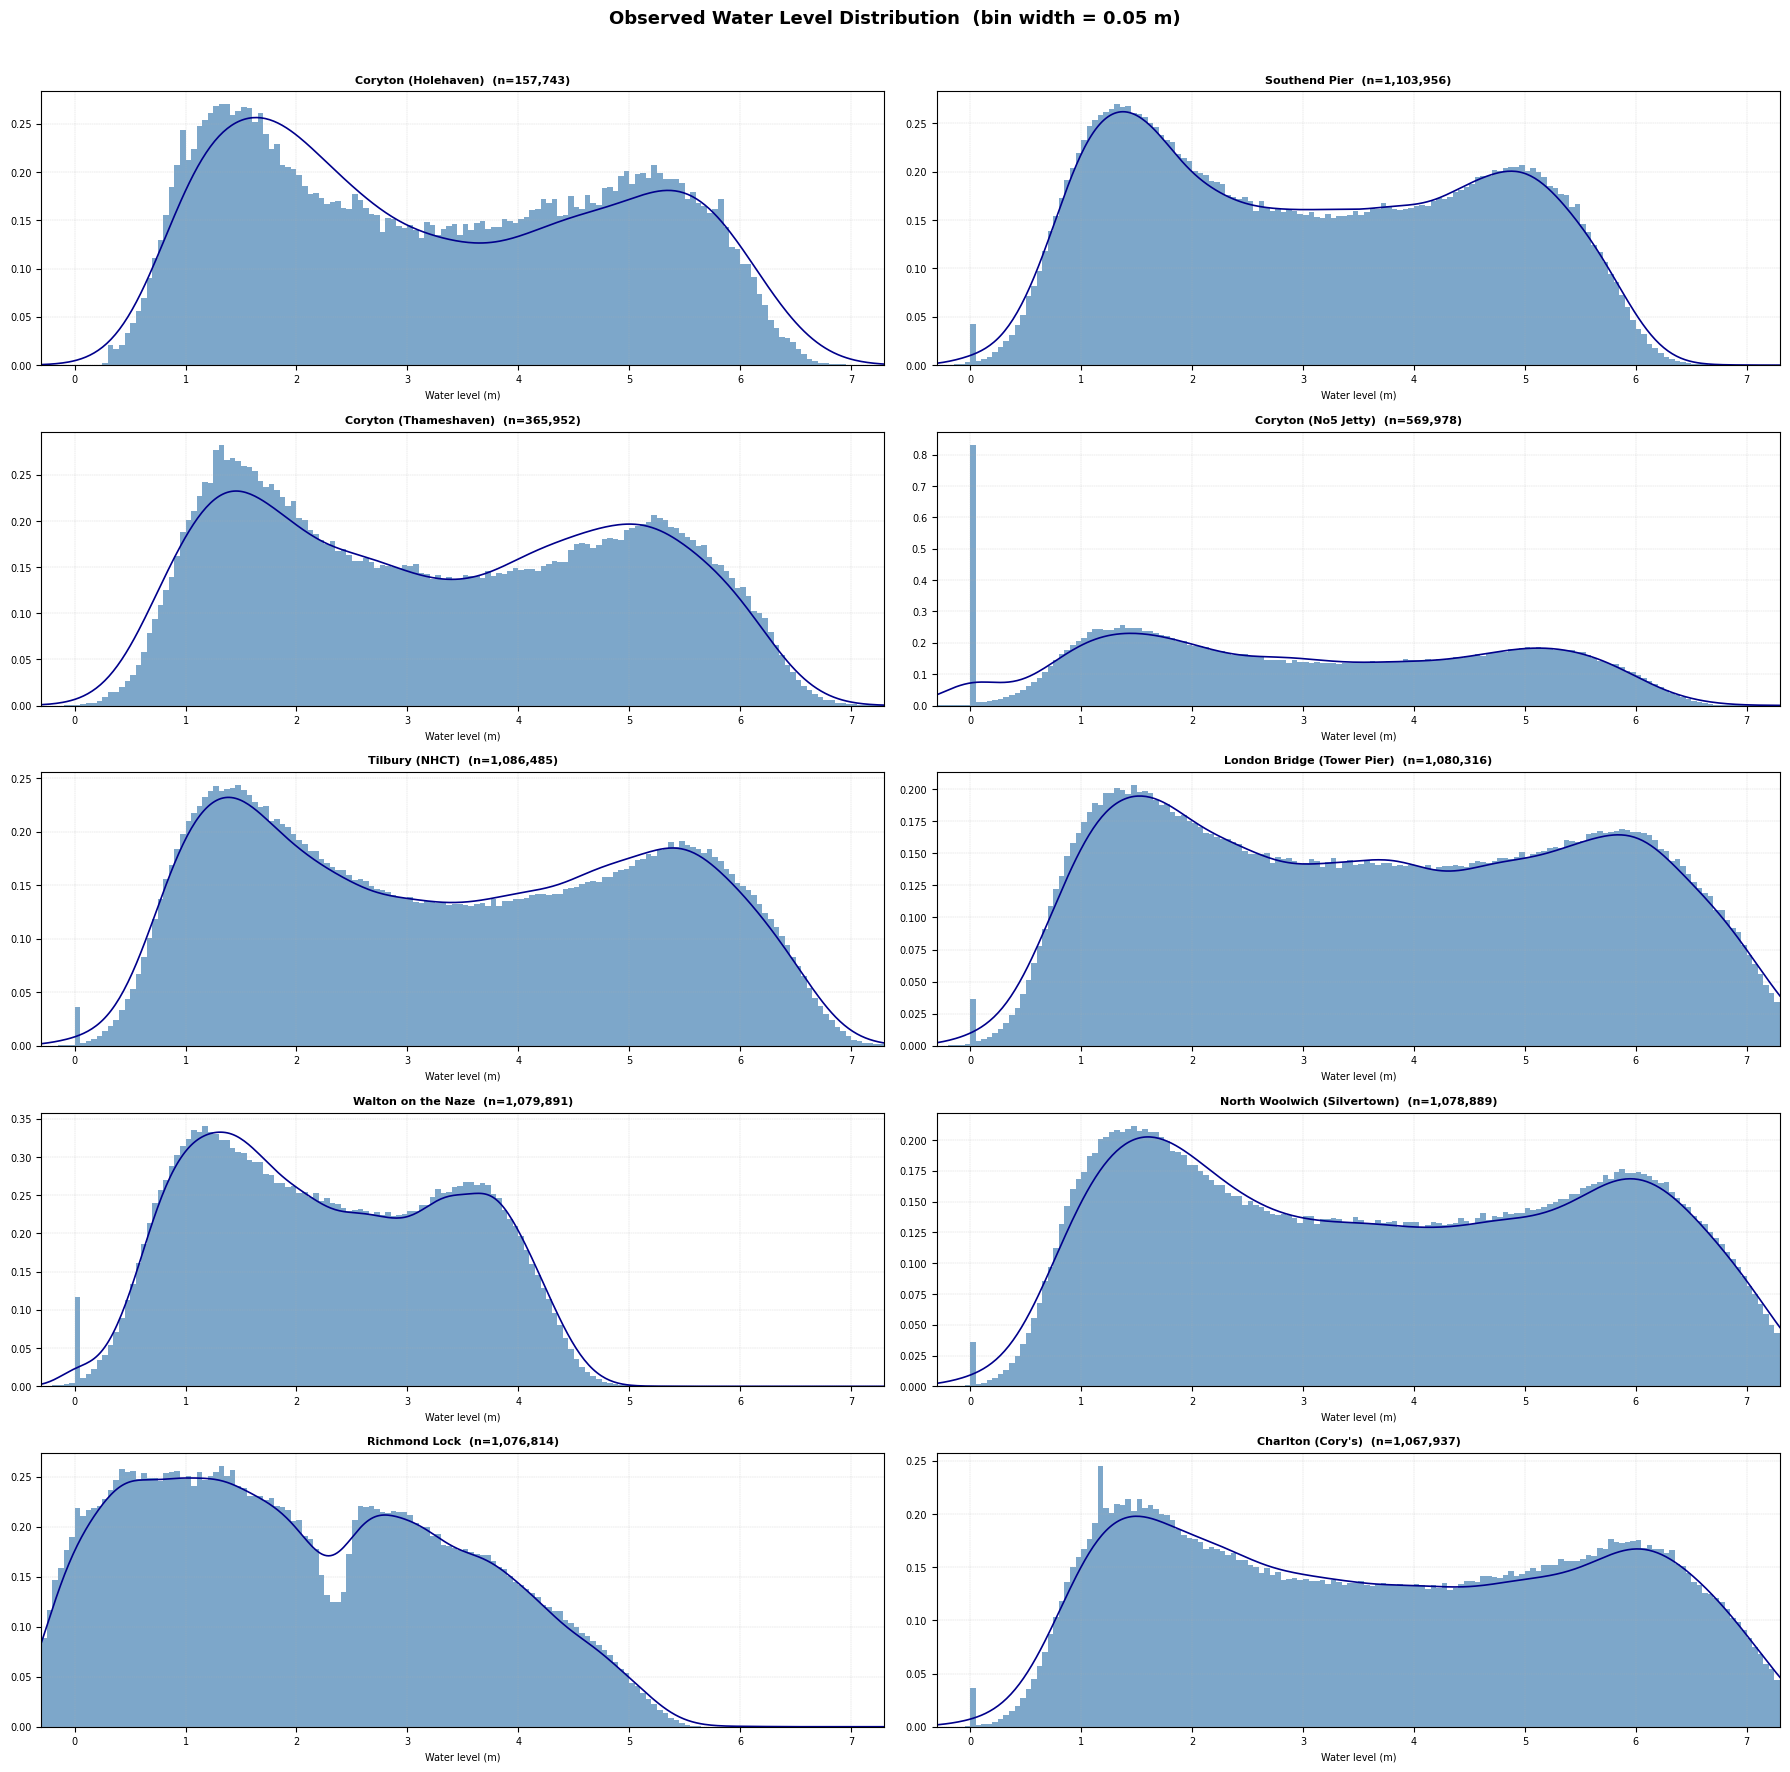

  Saved eda_distribution_all.png
  eda_acf_all.png


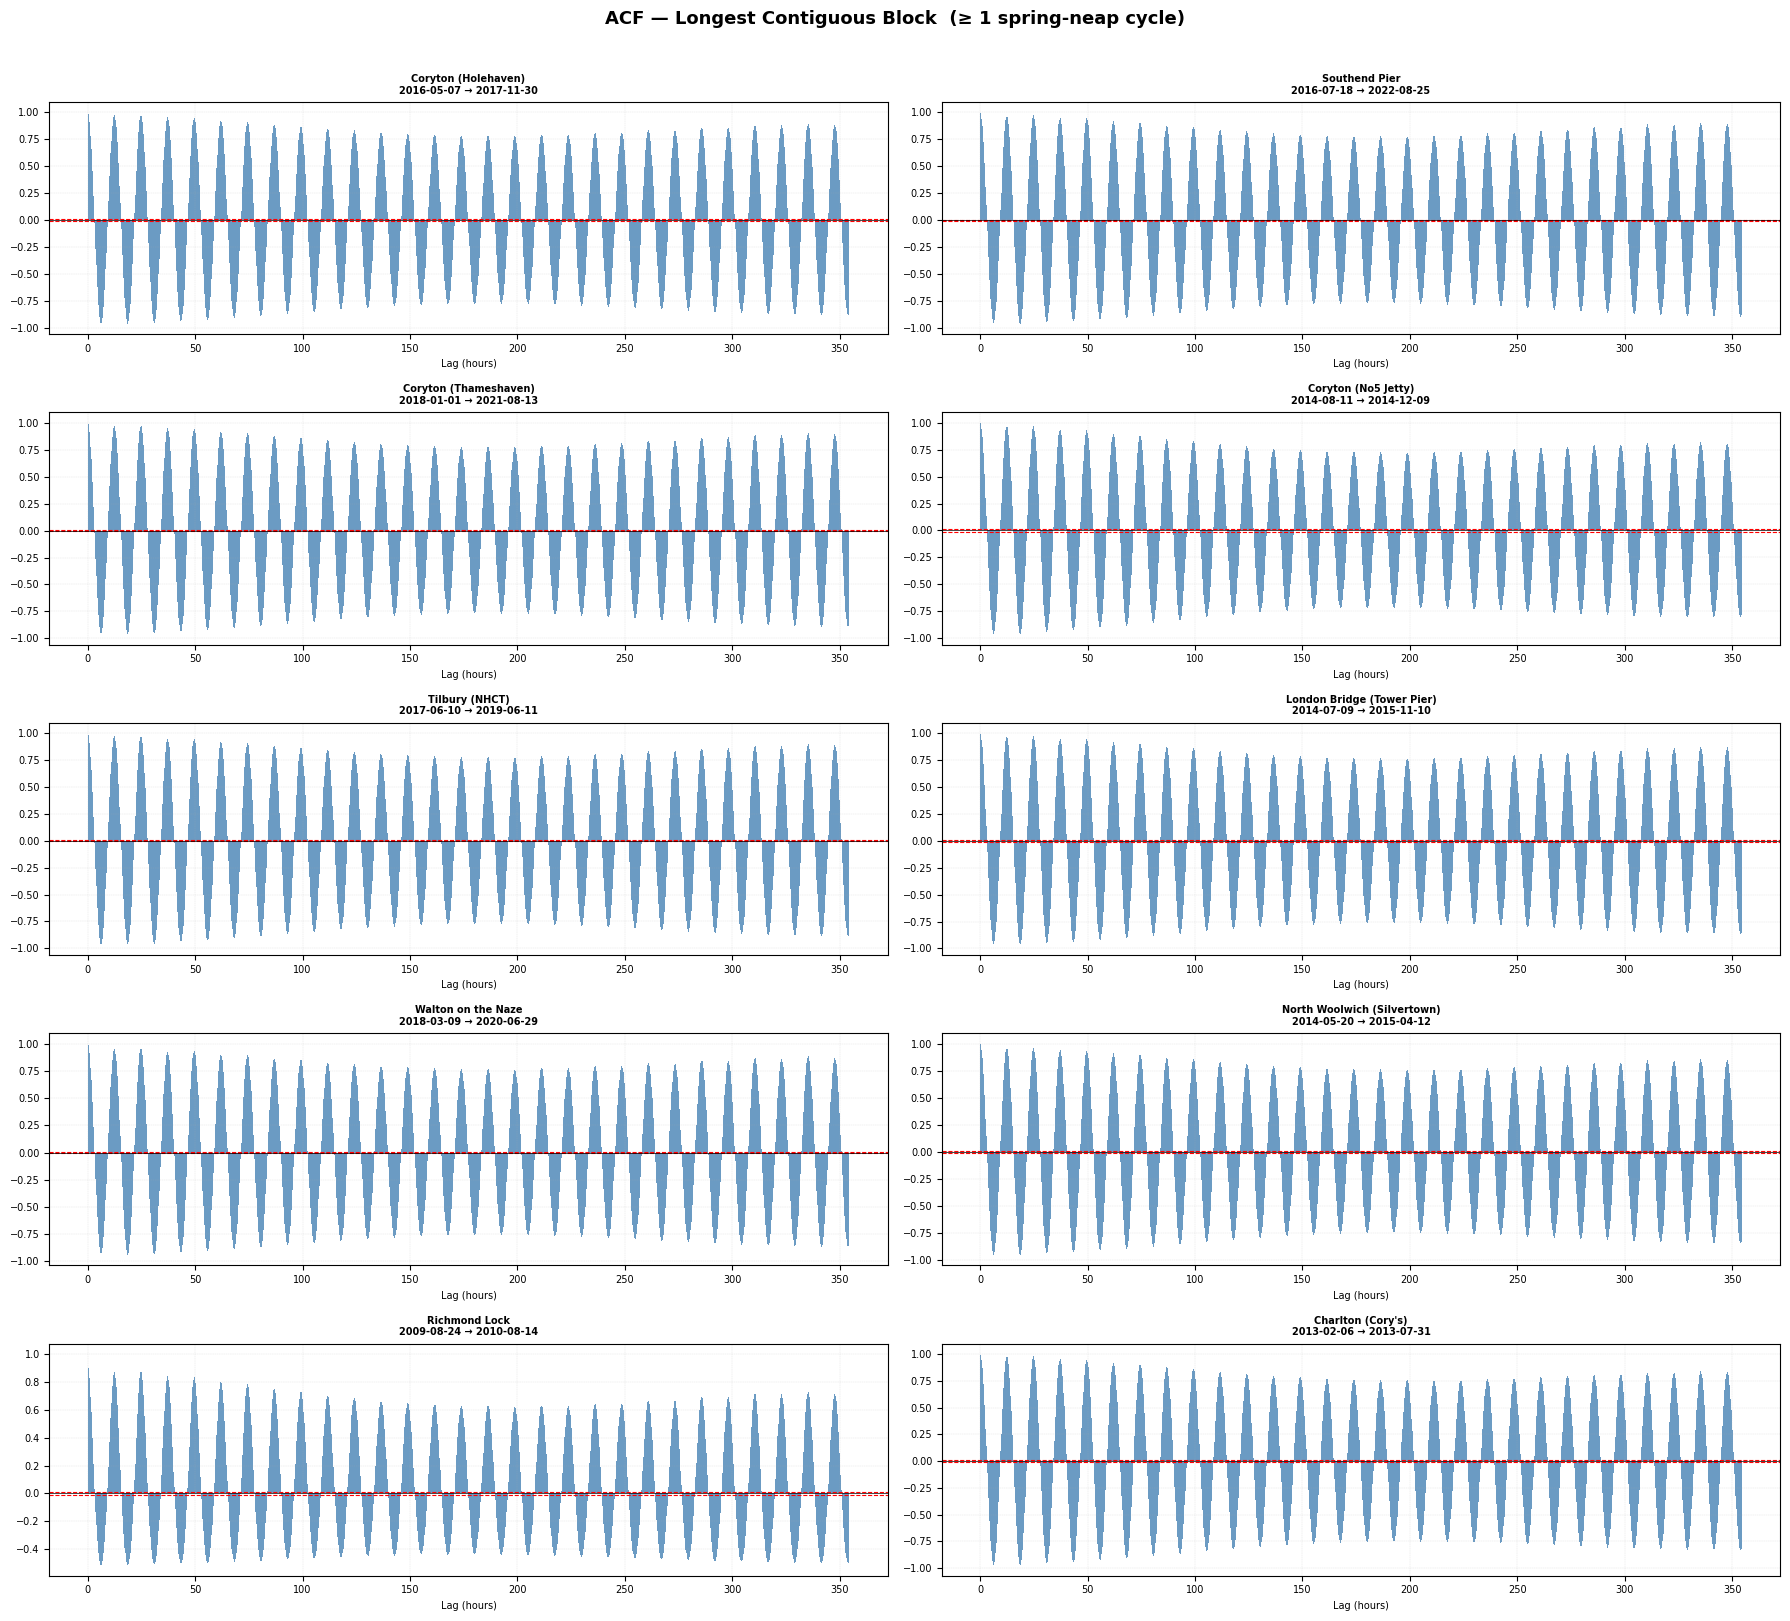

  Saved eda_acf_all.png
  eda_pacf_all.png


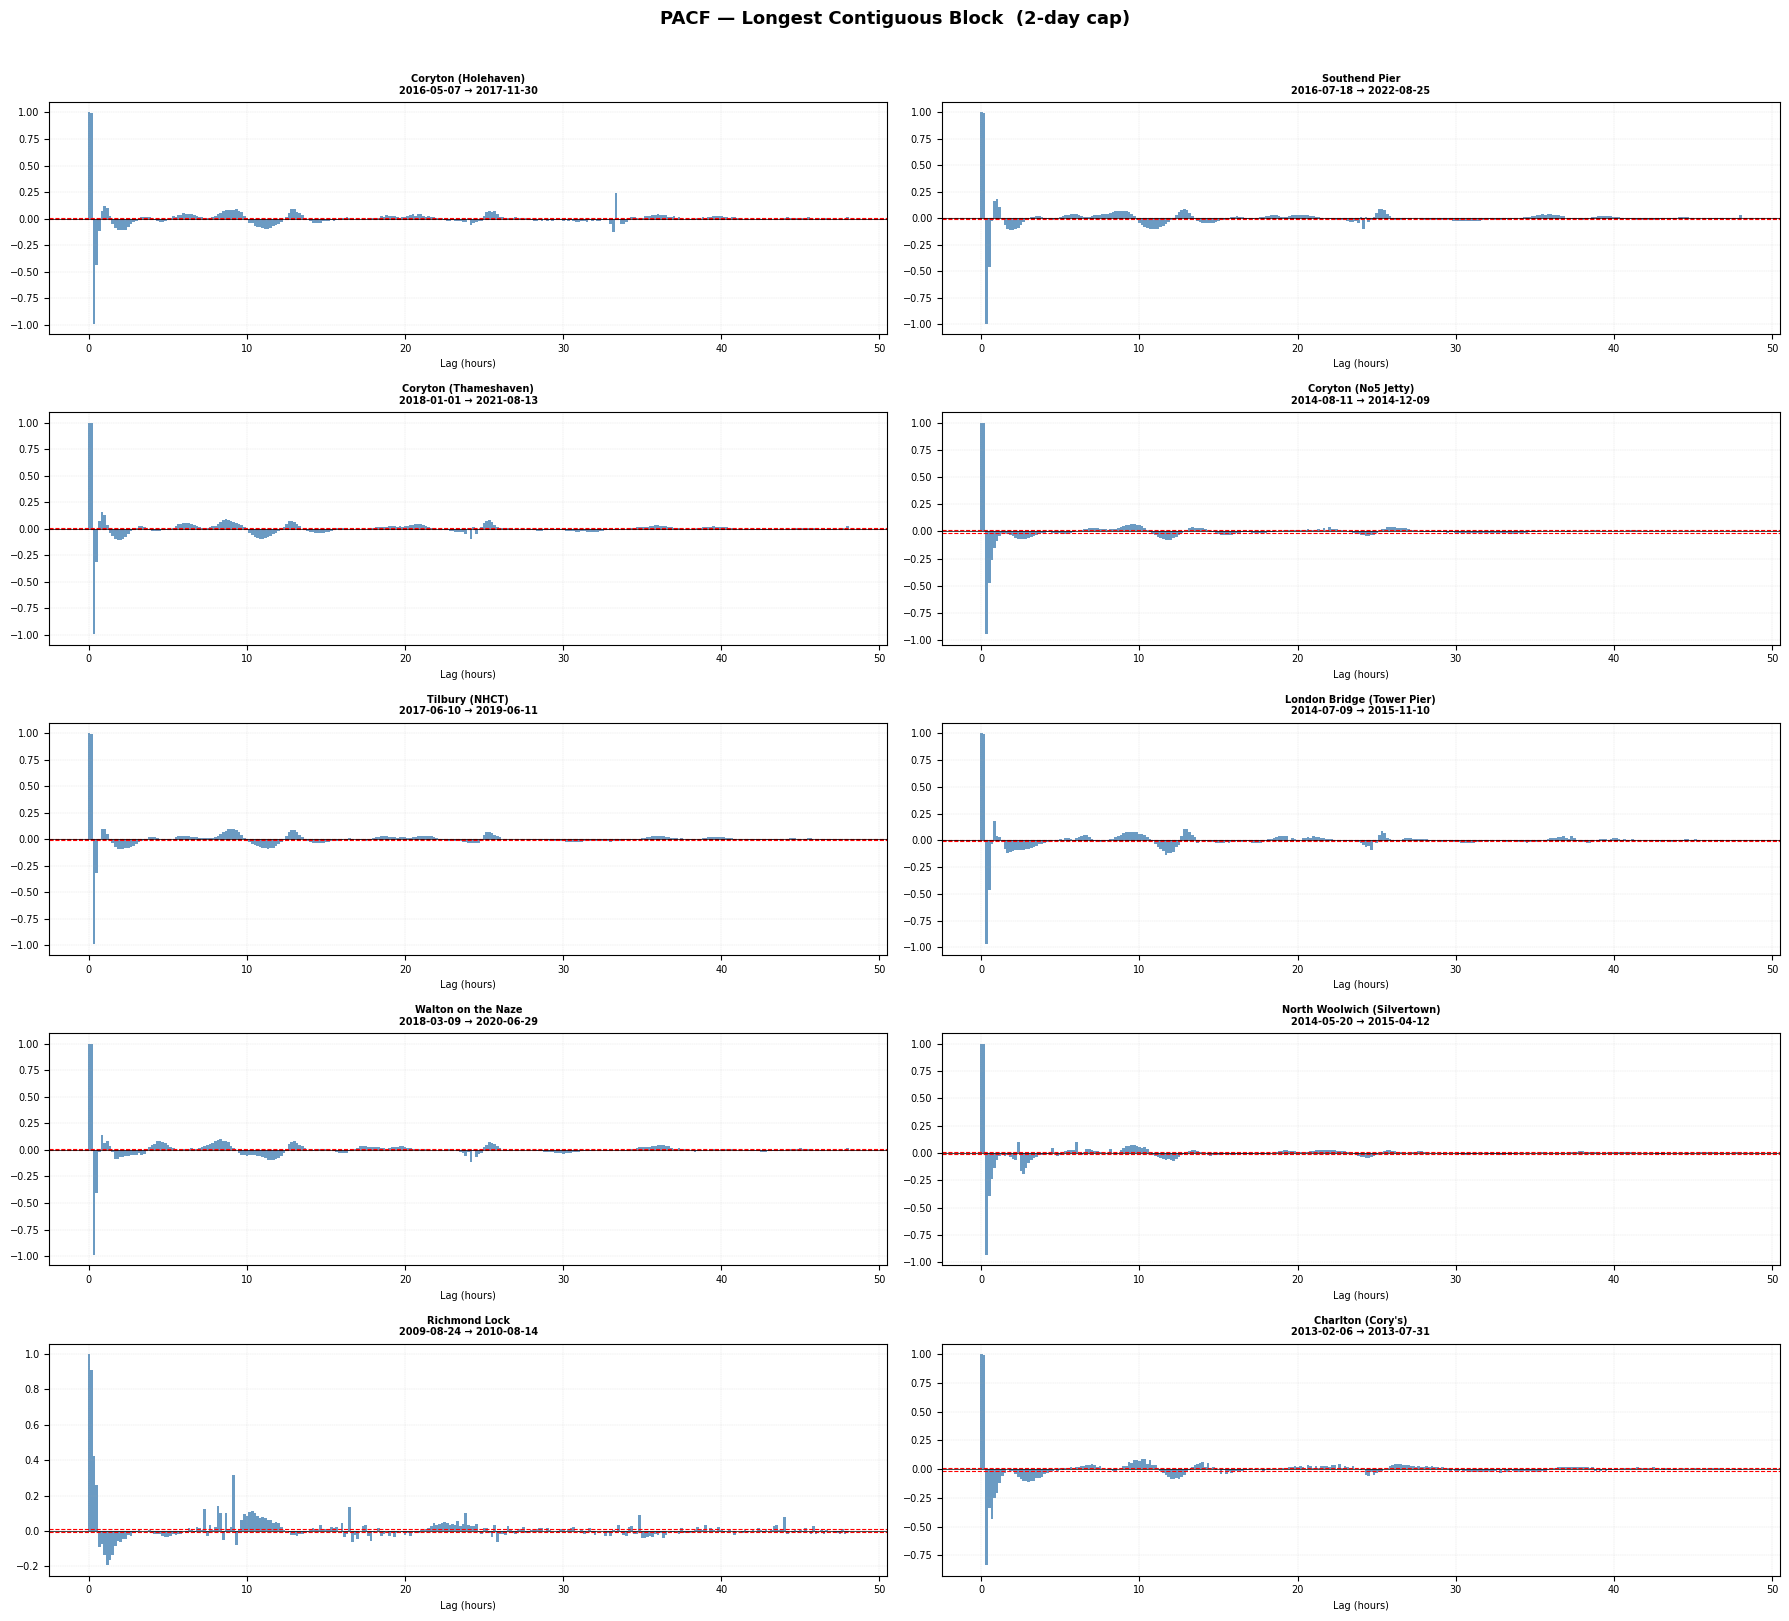

  Saved eda_pacf_all.png
  eda_periodogram_all.png


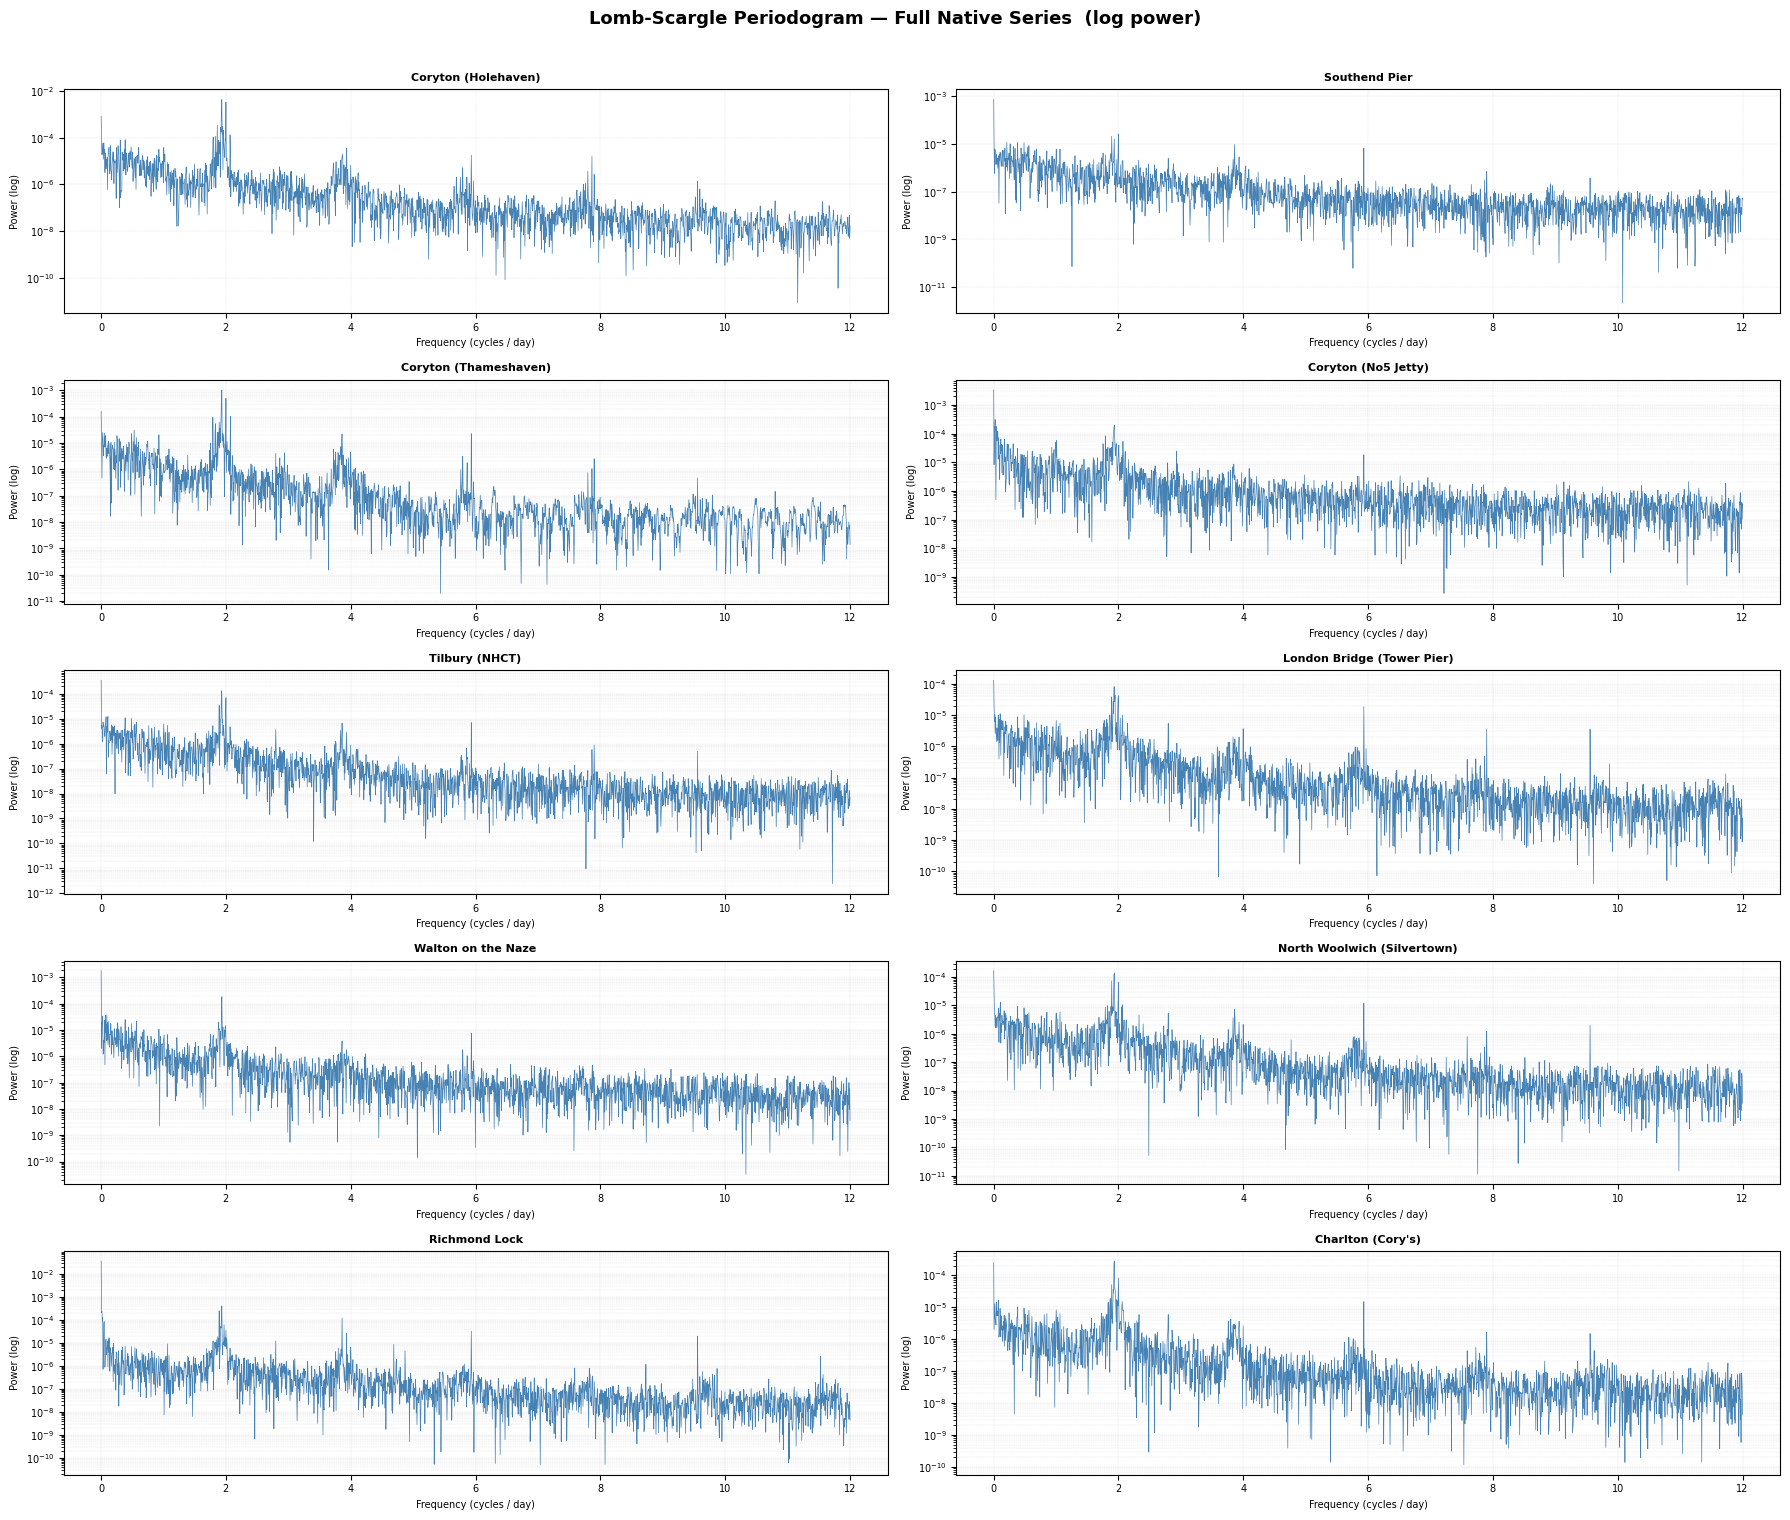

  Saved eda_periodogram_all.png
  eda_annual_mean_all.png


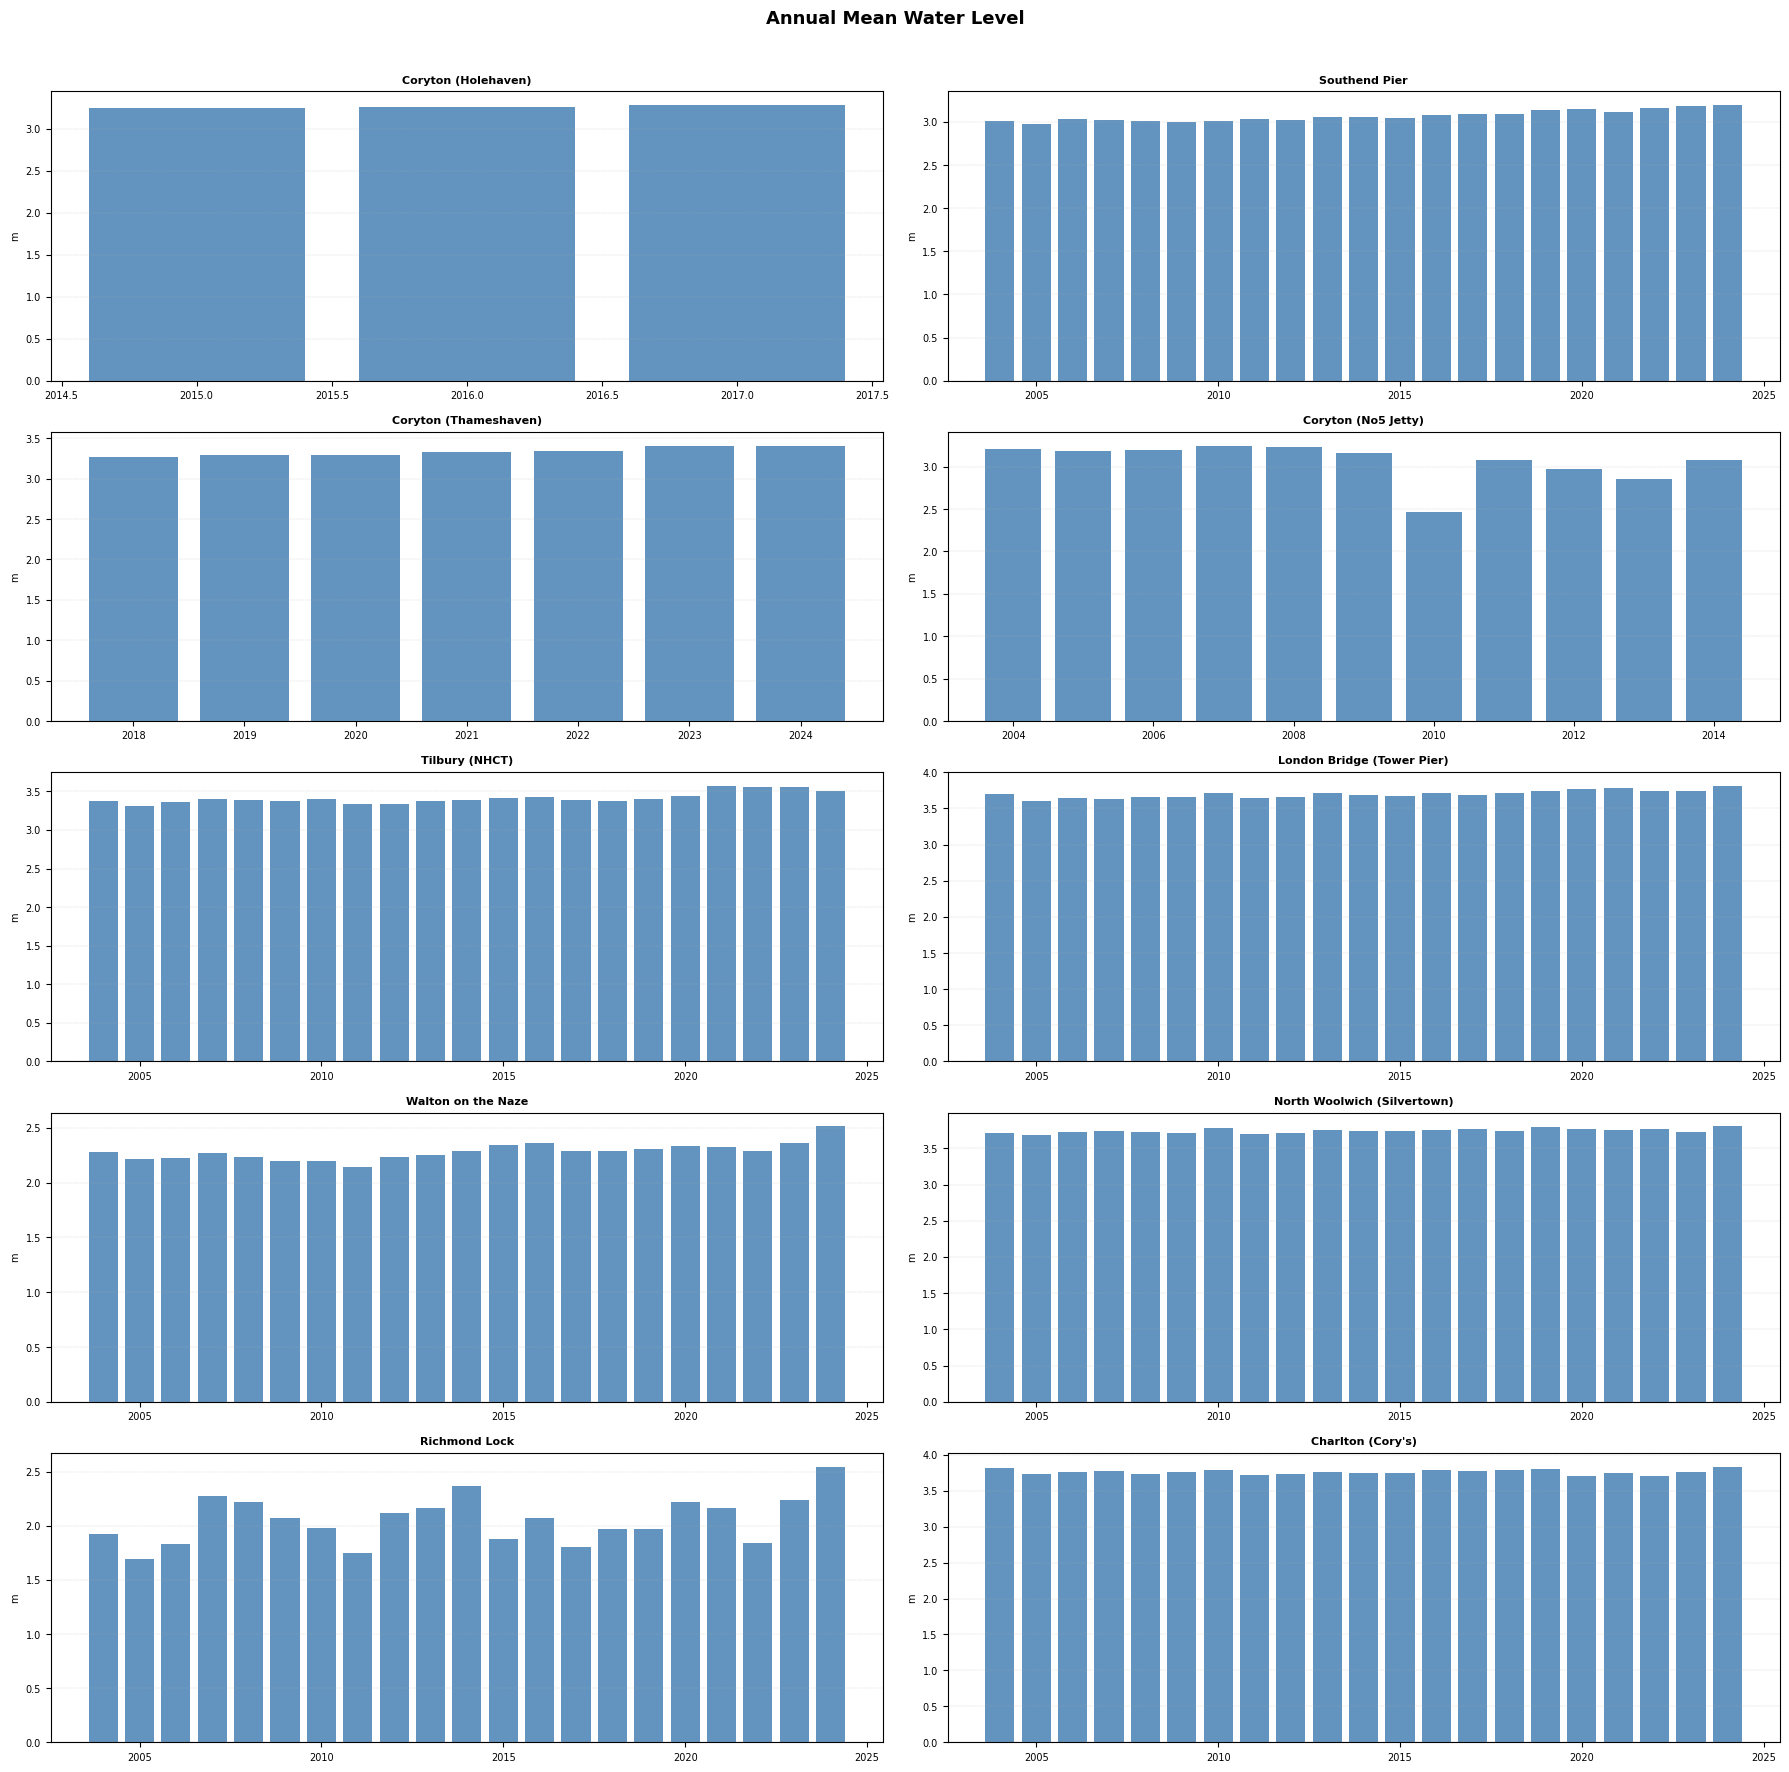

  Saved eda_annual_mean_all.png
  eda_adf_kpss_summary.png


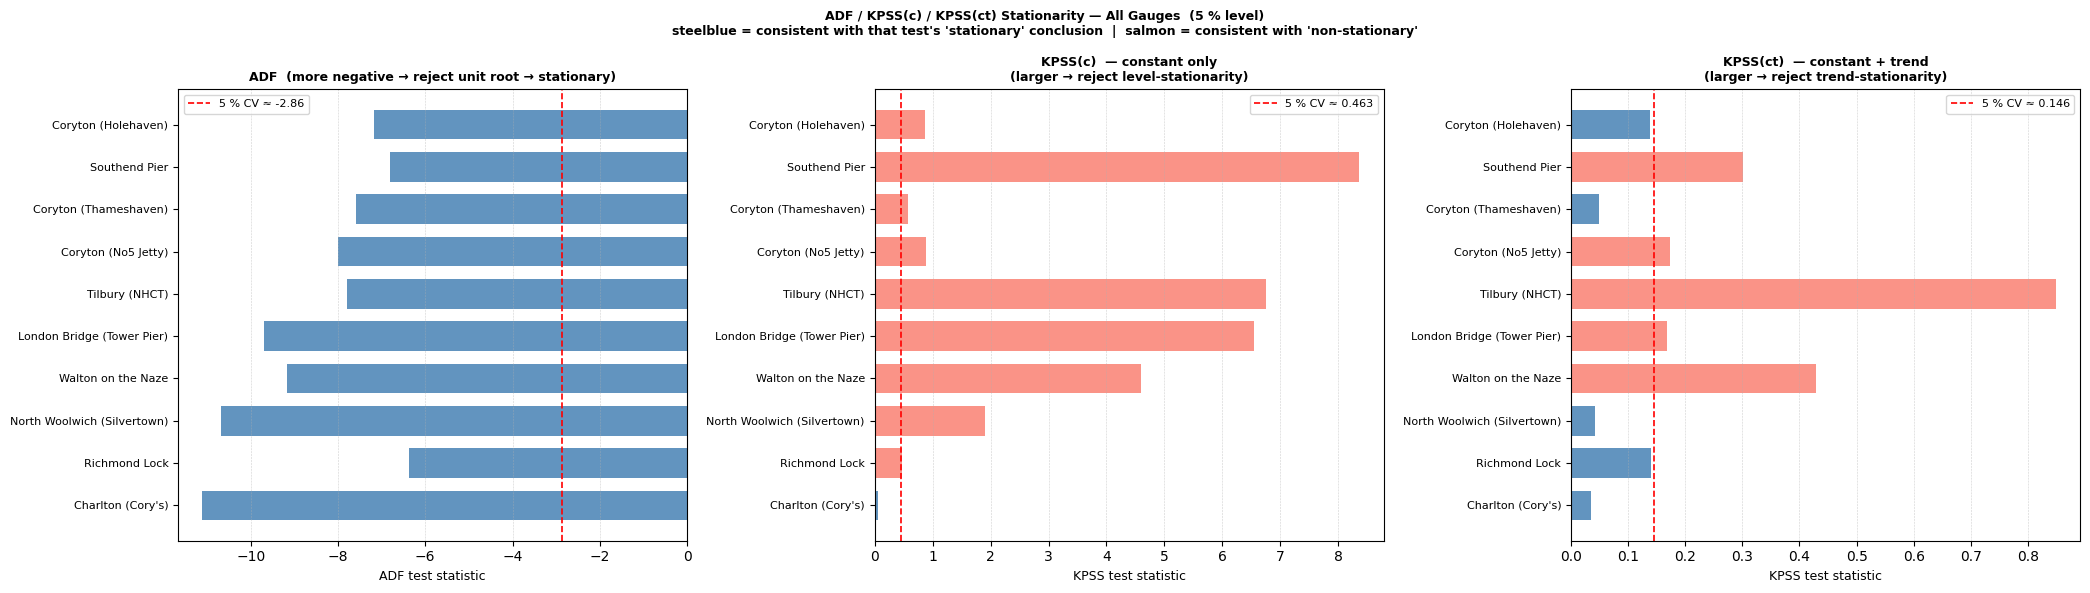

  Saved eda_adf_kpss_summary.png
  eda_acf_daily_diff_all.png


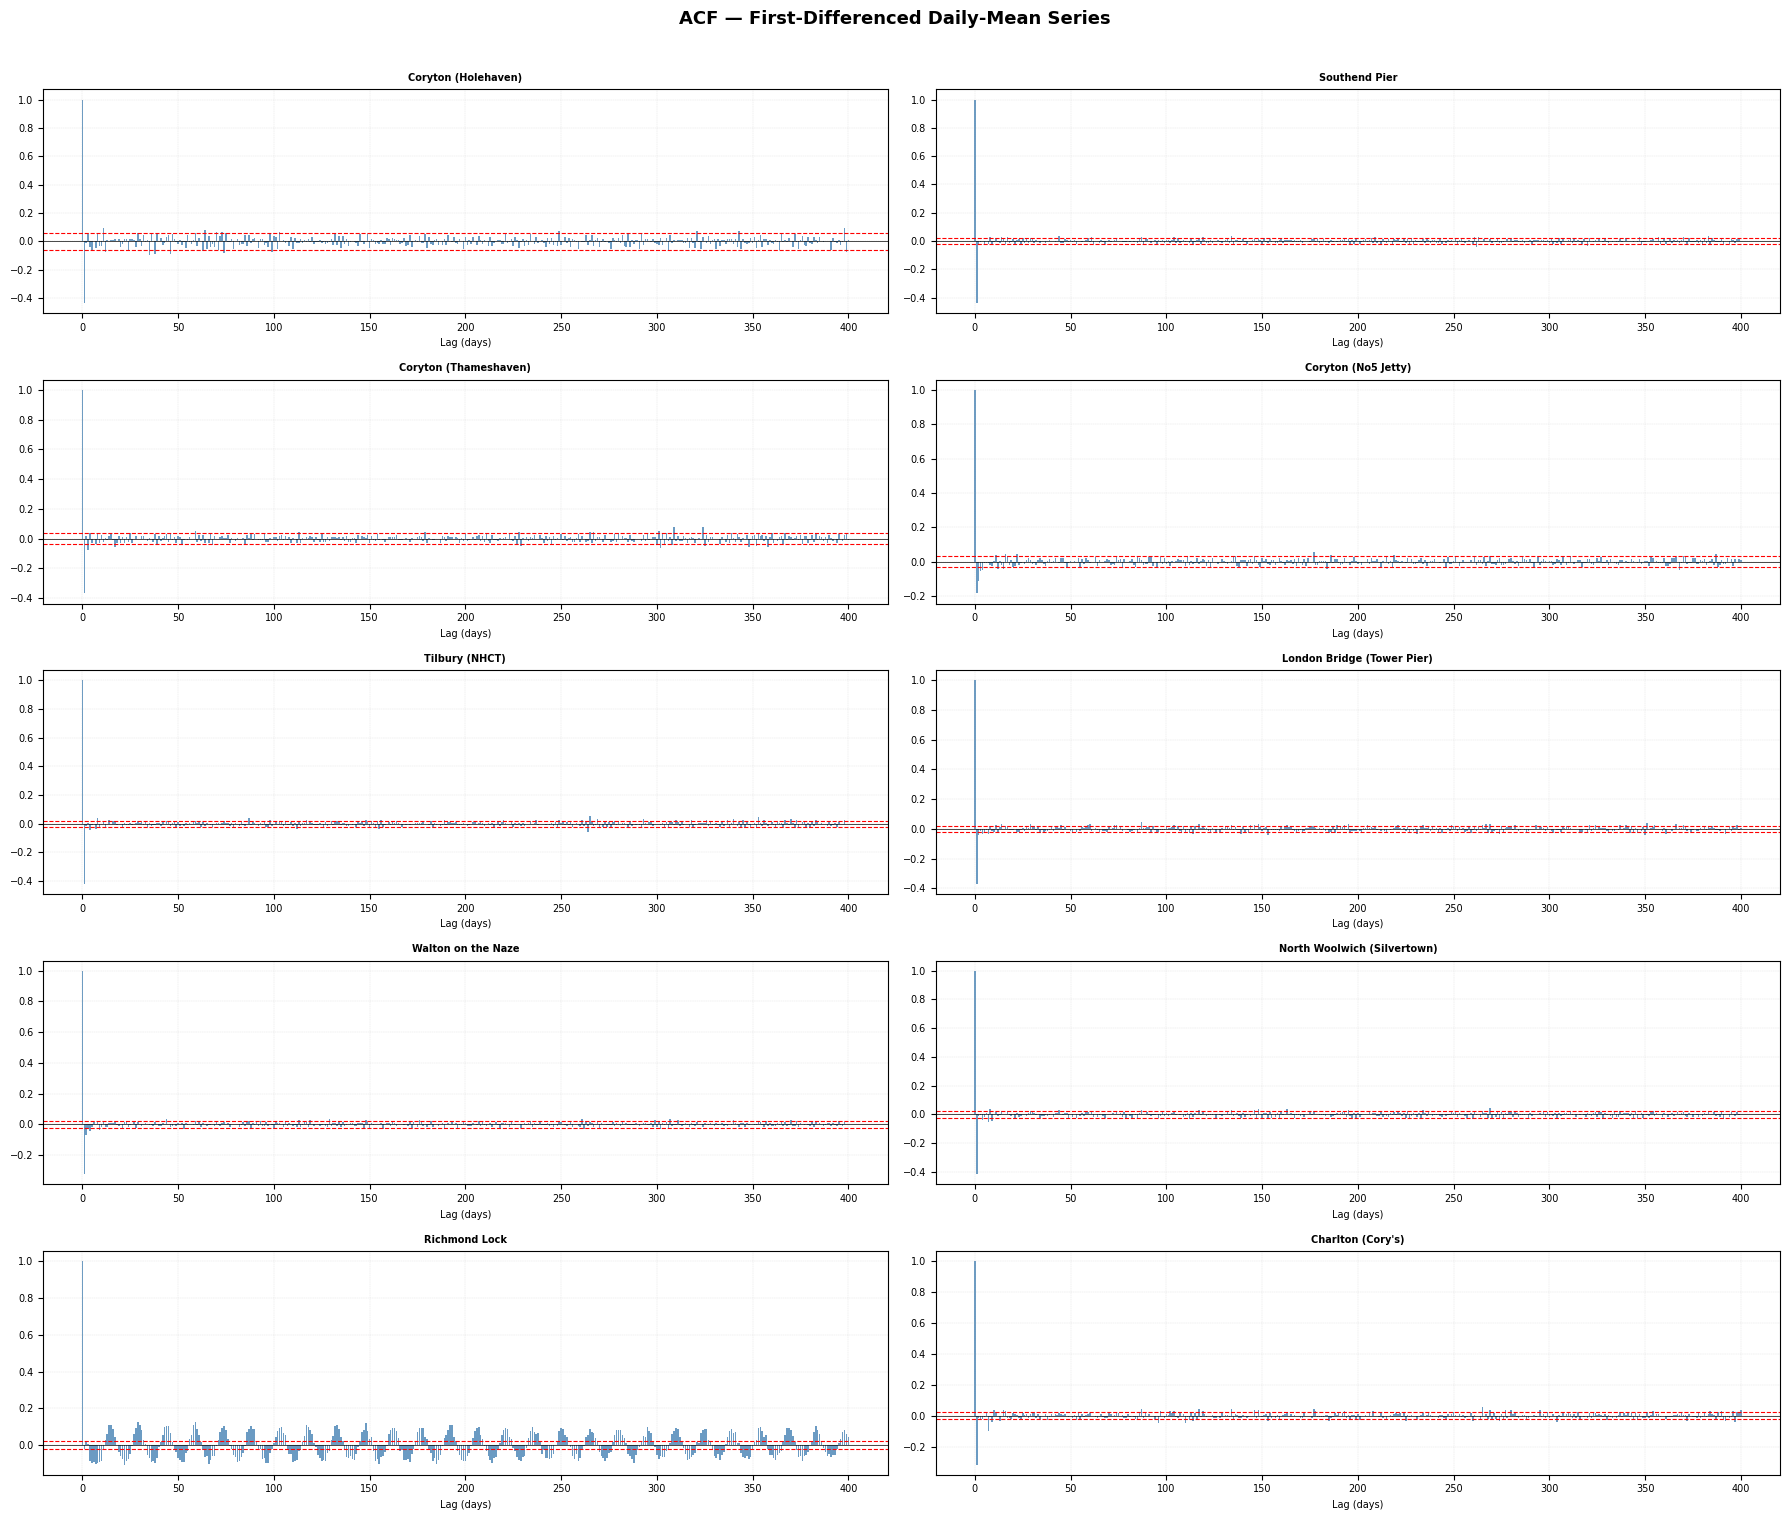

  Saved eda_acf_daily_diff_all.png
  eda_pacf_daily_diff_all.png


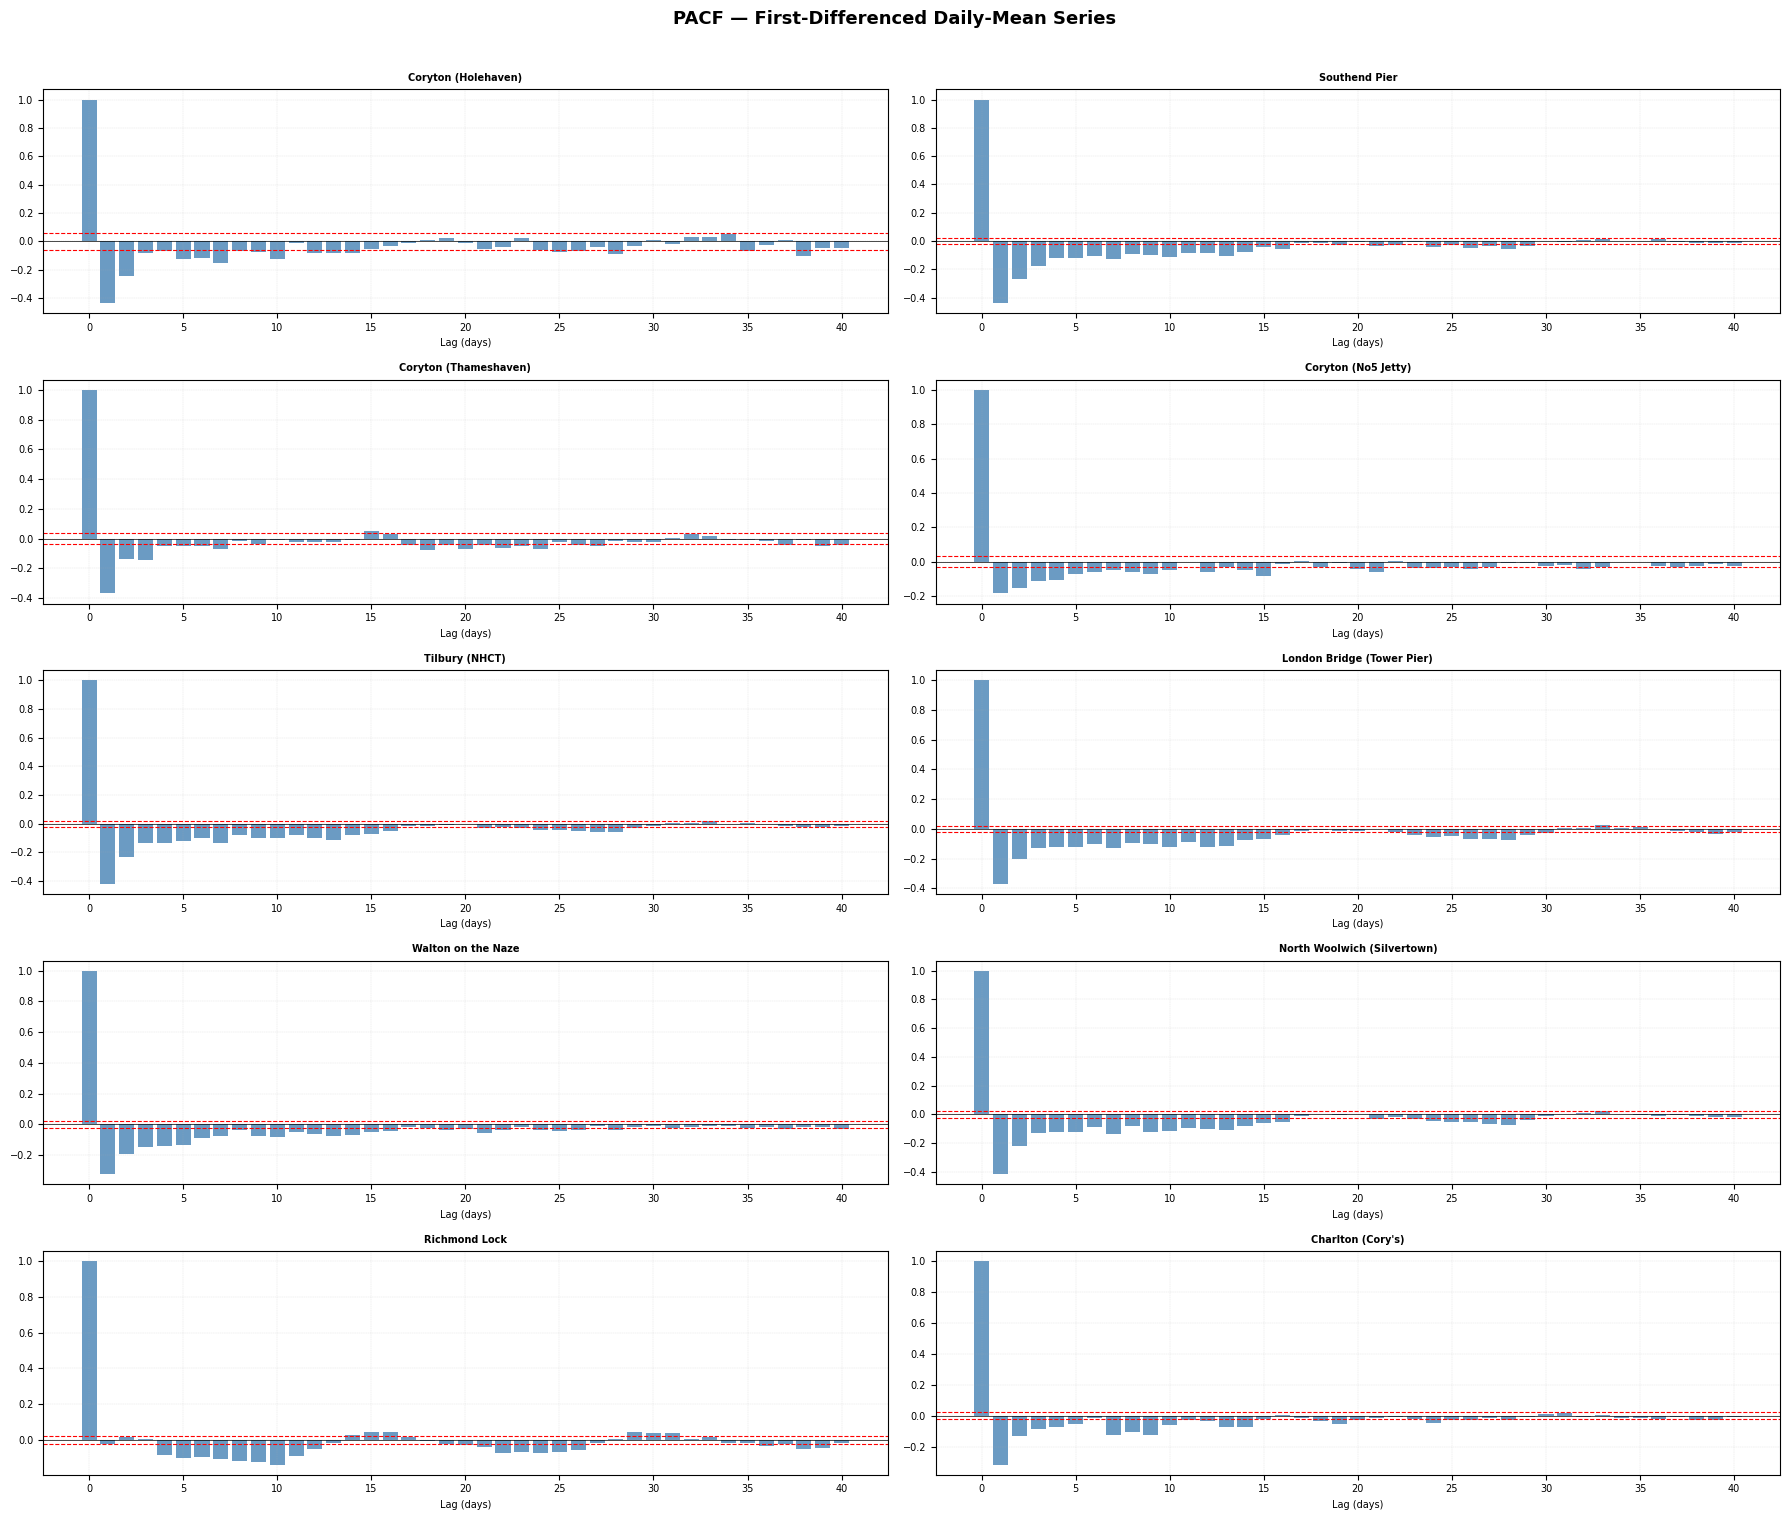

  Saved eda_pacf_daily_diff_all.png
  eda_acf_seasonal_diff_all.png


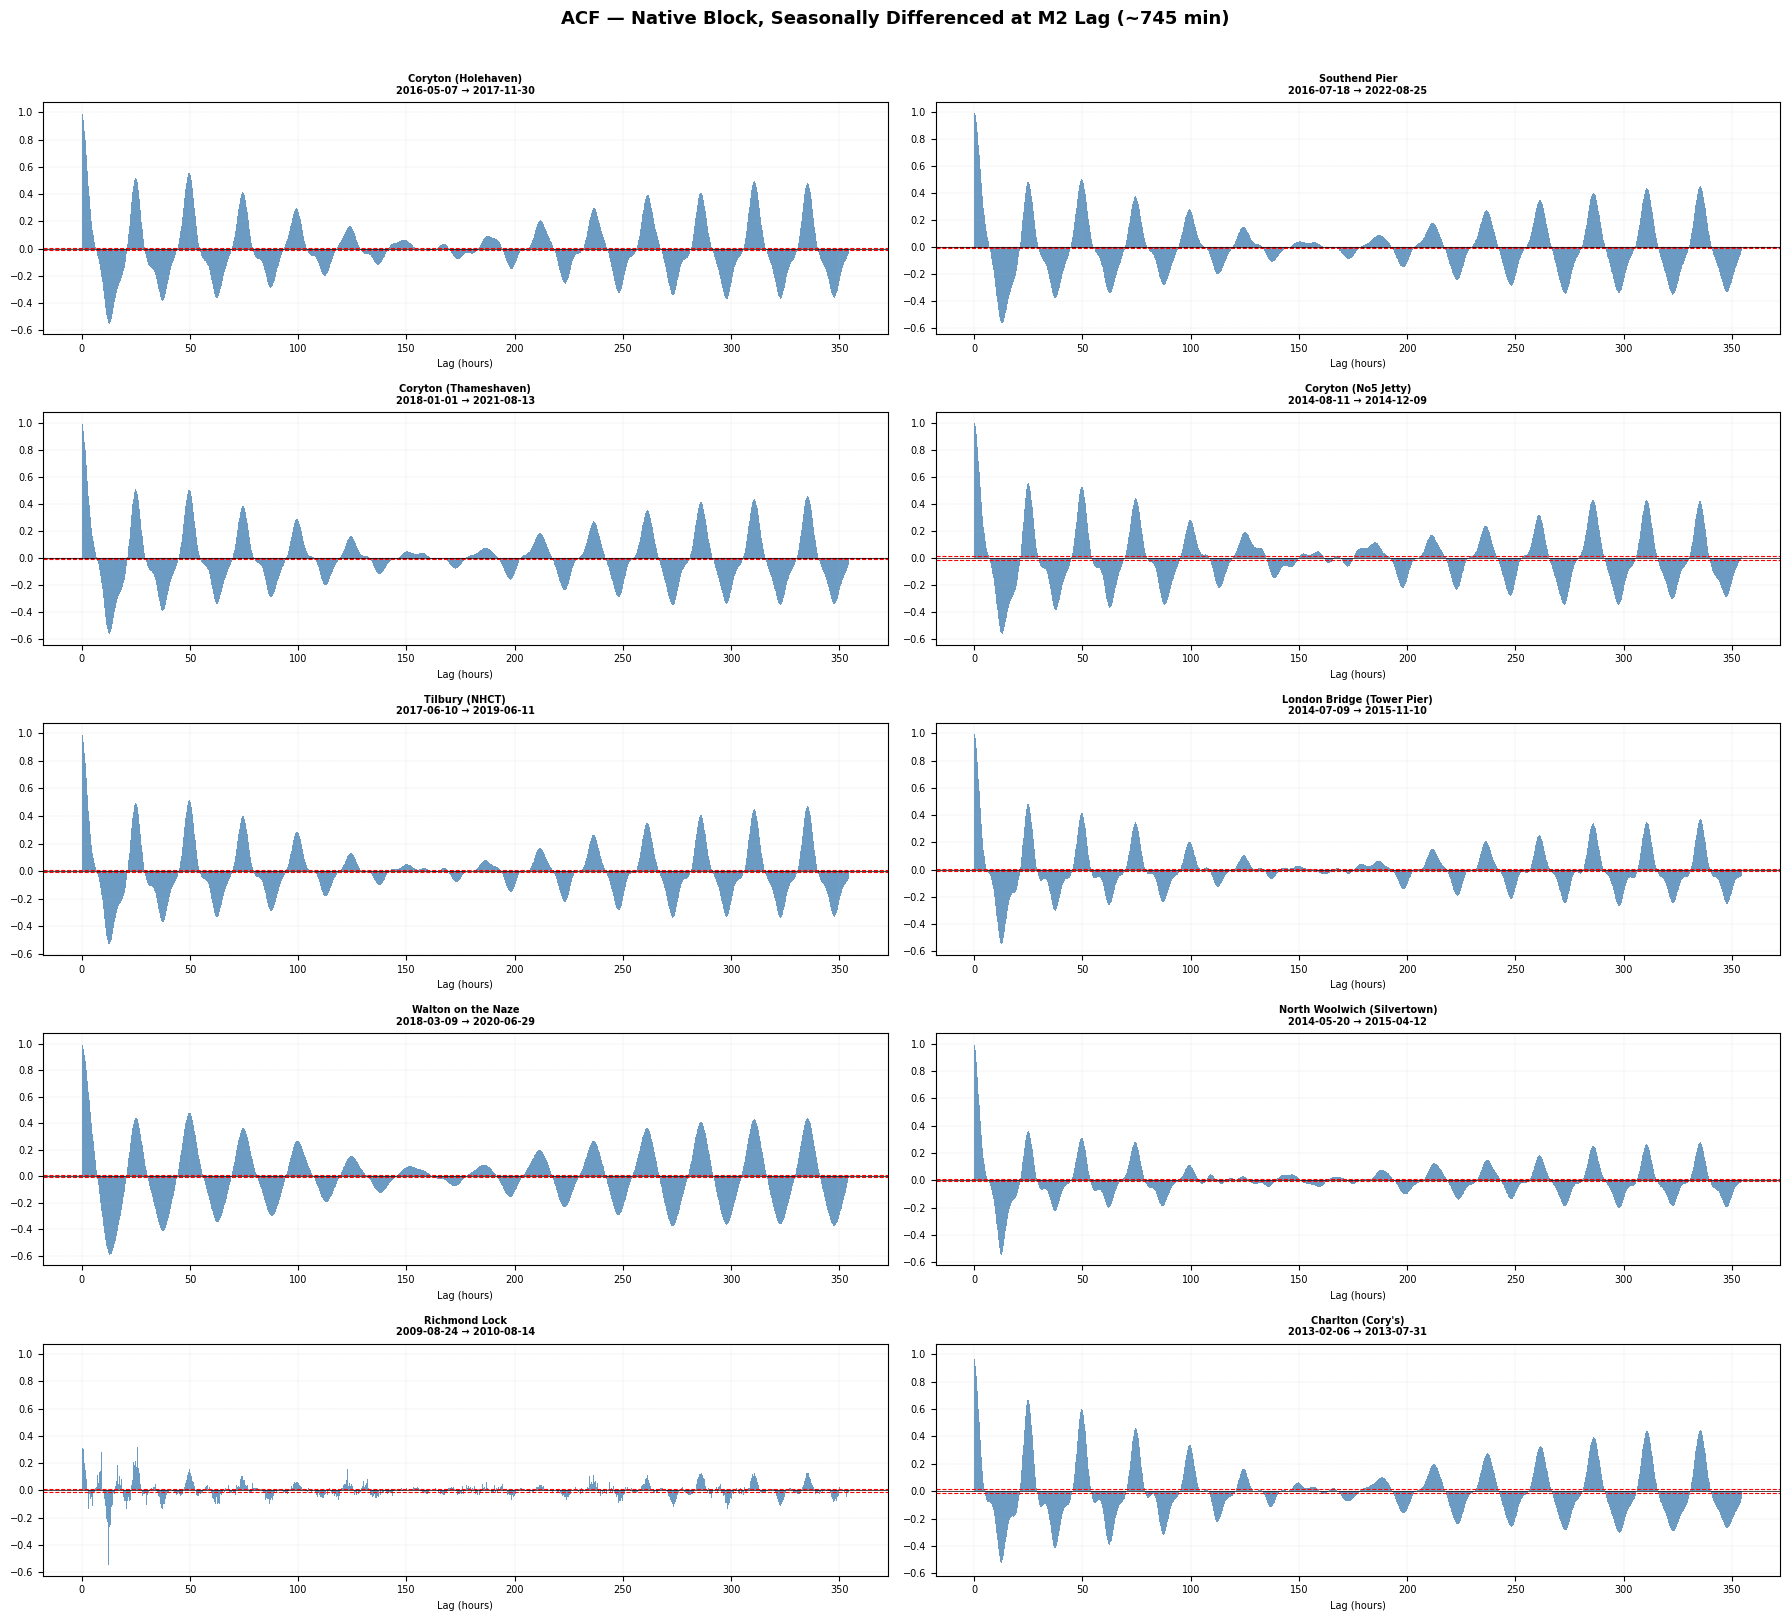

  Saved eda_acf_seasonal_diff_all.png
  eda_pacf_seasonal_diff_all.png


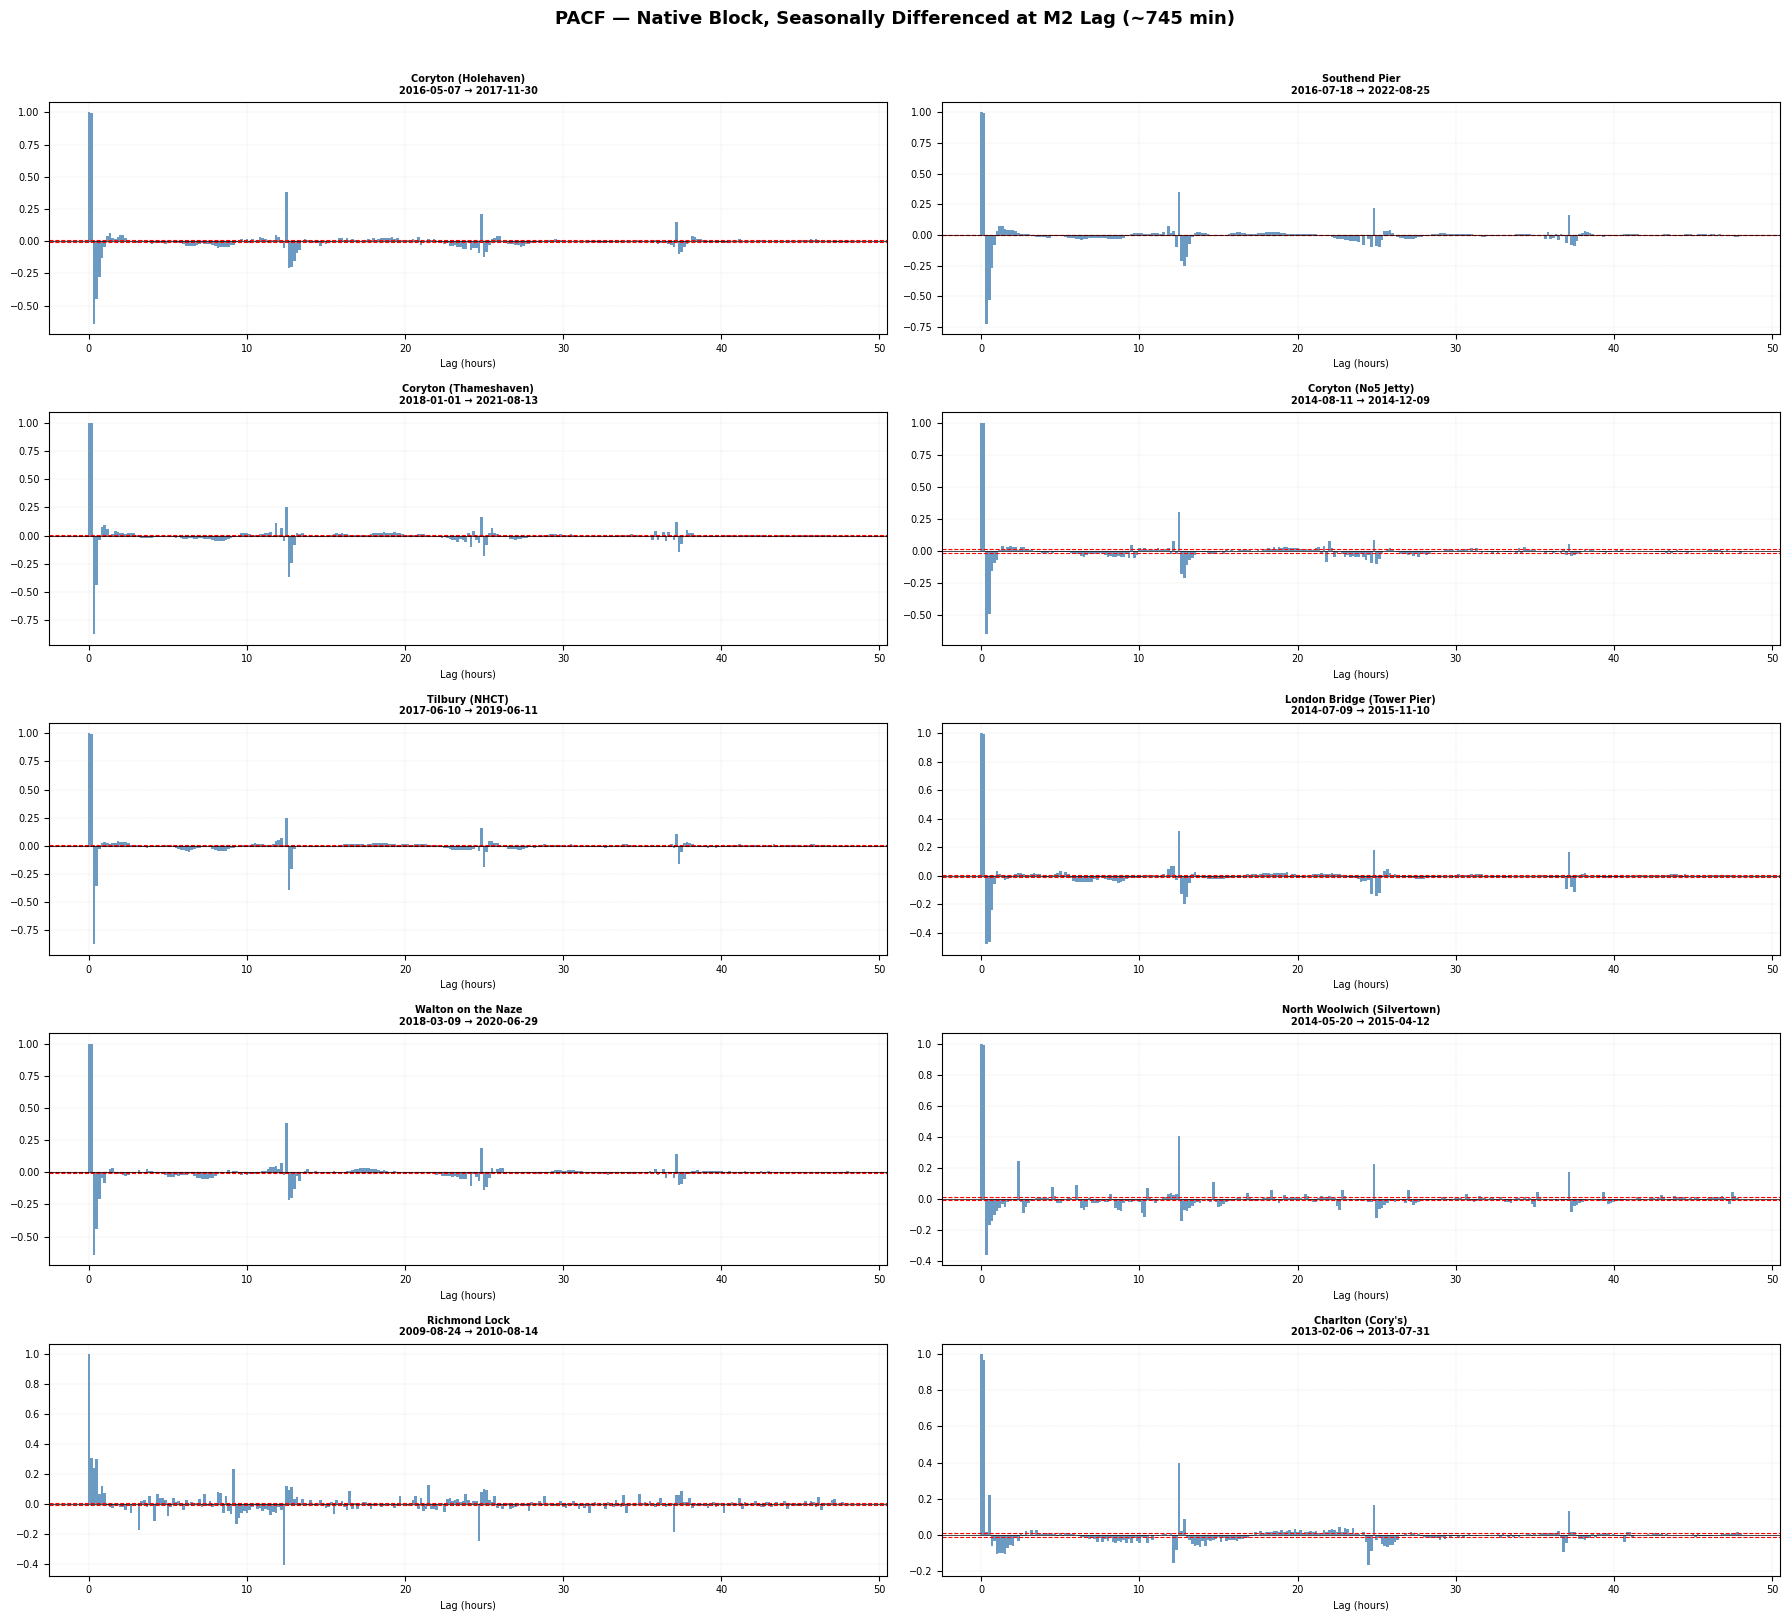

  Saved eda_pacf_seasonal_diff_all.png

All plots complete.


In [ ]:
print("Generating all plots …\n")

print("  eda_distribution_all.png");        plot_distribution_grid()
print("  eda_acf_all.png");                 plot_acf_grid()
print("  eda_pacf_all.png");                plot_pacf_grid()
print("  eda_periodogram_all.png");         plot_periodogram_grid()
print("  eda_annual_mean_all.png");         plot_annual_mean_grid()
print("  eda_adf_kpss_summary.png");        plot_adf_kpss_summary()
print("  eda_acf_daily_diff_all.png");      plot_acf_daily_diff_grid()
print("  eda_pacf_daily_diff_all.png");     plot_pacf_daily_diff_grid()
print("  eda_acf_seasonal_diff_all.png");   plot_acf_seasonal_diff_grid()
print("  eda_pacf_seasonal_diff_all.png");  plot_pacf_seasonal_diff_grid()

print("\nAll plots complete.")


In [19]:
# ── distribution_summary.csv ─────────────────────────────────────────────
rows = []
for gid, d in gauge_diags.items():
    ds = d["dist"]
    rows.append({"idSite": gid, "site_name": d["site_name"],
                 "n": ds["n"], "min": ds["min"], "max": ds["max"],
                 "mean": ds["mean"], "median": ds["median"], "std": ds["std"],
                 "p1": ds["p1"], "p99": ds["p99"],
                 "skew": ds["skew"], "kurtosis": ds["kurtosis"]})
pd.DataFrame(rows).round(6).to_csv(
    os.path.join(TEMPORAL_EDA_DIR, "distribution_summary.csv"), index=False)

# ── adf_kpss_summary.csv ─────────────────────────────────────────────────
rows = []
for gid, d in gauge_diags.items():
    rows.append({"idSite": gid, "site_name": d["site_name"],
                 "adf_stat": d["adf"]["stat"], "adf_pvalue": d["adf"]["pvalue"],
                 "adf_conclusion": d["adf"]["conclusion"],
                 "kpss_c_stat": d["kpss_c"]["stat"], "kpss_c_pvalue": d["kpss_c"]["pvalue"],
                 "kpss_c_conclusion": d["kpss_c"]["conclusion"],
                 "kpss_ct_stat": d["kpss_ct"]["stat"], "kpss_ct_pvalue": d["kpss_ct"]["pvalue"],
                 "kpss_ct_conclusion": d["kpss_ct"]["conclusion"]})
pd.DataFrame(rows).to_csv(
    os.path.join(TEMPORAL_EDA_DIR, "adf_kpss_summary.csv"), index=False)

# ── contiguous_block_info.csv ─────────────────────────────────────────────
rows = []
for gid, d in gauge_diags.items():
    bl = d["block"]
    rows.append({"idSite": gid, "site_name": d["site_name"],
                 "block_start": bl["start"], "block_end": bl["end"],
                 "n_rows": bl["n_rows"], "days": round(bl["days"], 1),
                 "short_block": bl["short"]})
pd.DataFrame(rows).to_csv(
    os.path.join(TEMPORAL_EDA_DIR, "contiguous_block_info.csv"), index=False)

# ── annual_mean.csv ───────────────────────────────────────────────────────
parts = []
for gid, d in gauge_diags.items():
    am = d["annual_mean"].rename("mean_level").reset_index()
    am["year"] = am["DateTime"].dt.year
    am["idSite"] = gid; am["site_name"] = d["site_name"]
    parts.append(am[["idSite", "site_name", "year", "mean_level"]])
pd.concat(parts).to_csv(os.path.join(TEMPORAL_EDA_DIR, "annual_mean.csv"), index=False)

# ── acf_values.csv ────────────────────────────────────────────────────────
parts = []
for gid, d in gauge_diags.items():
    if d["acf"] is None: continue
    a = d["acf"]
    parts.append(pd.DataFrame({"idSite": gid, "site_name": d["site_name"],
                                "lag": a["lags"], "value": a["values"],
                                "ci_low": a["ci_low"], "ci_high": a["ci_high"]}))
pd.concat(parts).to_csv(os.path.join(TEMPORAL_EDA_DIR, "acf_values.csv"), index=False)

# ── pacf_values.csv ───────────────────────────────────────────────────────
parts = []
for gid, d in gauge_diags.items():
    if d["pacf"] is None: continue
    p = d["pacf"]
    parts.append(pd.DataFrame({"idSite": gid, "site_name": d["site_name"],
                                "lag": p["lags"], "value": p["values"],
                                "ci_low": p["ci_low"], "ci_high": p["ci_high"]}))
pd.concat(parts).to_csv(os.path.join(TEMPORAL_EDA_DIR, "pacf_values.csv"), index=False)

# ── acf_daily_diff_values.csv ─────────────────────────────────────────────
parts = []
for gid, d in gauge_diags.items():
    if d["acf_daily_diff"] is None: continue
    a = d["acf_daily_diff"]
    parts.append(pd.DataFrame({"idSite": gid, "site_name": d["site_name"],
                                "lag_days": a["lags"], "value": a["values"],
                                "ci_low": a["ci_low"], "ci_high": a["ci_high"]}))
pd.concat(parts).to_csv(os.path.join(TEMPORAL_EDA_DIR, "acf_daily_diff_values.csv"), index=False)

# ── pacf_daily_diff_values.csv ────────────────────────────────────────────
parts = []
for gid, d in gauge_diags.items():
    if d["pacf_daily_diff"] is None: continue
    p = d["pacf_daily_diff"]
    parts.append(pd.DataFrame({"idSite": gid, "site_name": d["site_name"],
                                "lag_days": p["lags"], "value": p["values"],
                                "ci_low": p["ci_low"], "ci_high": p["ci_high"]}))
pd.concat(parts).to_csv(os.path.join(TEMPORAL_EDA_DIR, "pacf_daily_diff_values.csv"), index=False)

# ── acf_seasonal_diff_values.csv ──────────────────────────────────────────
parts = []
for gid, d in gauge_diags.items():
    if d["acf_seasonal_diff"] is None: continue
    a = d["acf_seasonal_diff"]
    parts.append(pd.DataFrame({"idSite": gid, "site_name": d["site_name"],
                                "seasonal_diff_lag": d["seasonal_diff_lag"],
                                "lag": a["lags"], "value": a["values"],
                                "ci_low": a["ci_low"], "ci_high": a["ci_high"]}))
pd.concat(parts).to_csv(os.path.join(TEMPORAL_EDA_DIR, "acf_seasonal_diff_values.csv"), index=False)

# ── pacf_seasonal_diff_values.csv ─────────────────────────────────────────
parts = []
for gid, d in gauge_diags.items():
    if d["pacf_seasonal_diff"] is None: continue
    p = d["pacf_seasonal_diff"]
    parts.append(pd.DataFrame({"idSite": gid, "site_name": d["site_name"],
                                "seasonal_diff_lag": d["seasonal_diff_lag"],
                                "lag": p["lags"], "value": p["values"],
                                "ci_low": p["ci_low"], "ci_high": p["ci_high"]}))
pd.concat(parts).to_csv(os.path.join(TEMPORAL_EDA_DIR, "pacf_seasonal_diff_values.csv"), index=False)

# ── periodogram.csv ───────────────────────────────────────────────────────
parts = []
for gid, d in gauge_diags.items():
    pg = d["periodogram"]
    parts.append(pd.DataFrame({"idSite": gid, "site_name": d["site_name"],
                                "frequency": pg["frequency"], "power": pg["power"]}))
pd.concat(parts).to_csv(os.path.join(TEMPORAL_EDA_DIR, "periodogram.csv"), index=False)

print(f"CSVs written to {TEMPORAL_EDA_DIR}")
for fn in sorted(f for f in os.listdir(TEMPORAL_EDA_DIR) if f.endswith(".csv")):
    kb = os.path.getsize(os.path.join(TEMPORAL_EDA_DIR, fn)) / 1024
    print(f"  {fn:<40} {kb:>8.1f} KB")


CSVs written to ..\outputs\temporal_eda
  acf_daily_diff_values.csv                   404.2 KB
  acf_seasonal_diff_values.csv               2189.0 KB
  acf_values.csv                             2078.5 KB
  adf_kpss_summary.csv                          1.8 KB
  annual_mean.csv                               9.7 KB
  classical_decomposition.csv                8002.2 KB
  contiguous_block_info.csv                     1.0 KB
  distribution_summary.csv                      1.1 KB
  gauge_summary_stats.csv                       0.8 KB
  pacf_daily_diff_values.csv                   40.6 KB
  pacf_seasonal_diff_values.csv               301.4 KB
  pacf_values.csv                             292.1 KB
  periodogram.csv                            1506.3 KB
  rolling_mean_var_daily.csv                11192.0 KB
  stl_trend.csv                              6360.8 KB
  tidal_range_daily.csv                      5889.9 KB


## Gauge Summary Statistics

Per-gauge summary table (port name, idSite, standard deviation, minimum, maximum, coefficient of variation, mean), built from the distribution stats already computed in `gauge_diags` (native, unflagged Observed values). Saved to the temporal EDA outputs.

Note: coefficient of variation (`std / mean`) is only really meaningful for a comfortably-positive mean — worth a sanity check if any gauge's mean sits close to zero.

In [20]:
summary_rows = []
for gid, d in gauge_diags.items():
    ds = d["dist"]
    cv = ds["std"] / ds["mean"] if ds["mean"] != 0 else np.nan
    summary_rows.append({
        "port_name": d["site_name"],
        "idSite":    gid,
        "std":       ds["std"],
        "min":       ds["min"],
        "max":       ds["max"],
        "cv":        cv,
        "mean":      ds["mean"],
    })

gauge_summary = pd.DataFrame(
    summary_rows, columns=["port_name", "idSite", "std", "min", "max", "cv", "mean"]
).round(6).sort_values("port_name").reset_index(drop=True)
display(gauge_summary)

SUMMARY_CSV = os.path.join(TEMPORAL_EDA_DIR, "gauge_summary_stats.csv")
gauge_summary.to_csv(SUMMARY_CSV, index=False)
print(f"Saved → {SUMMARY_CSV}")


,port_name,idSite,std,min,max,cv,mean
0,Charlton (Cory's),04_CHARLTON,1.935935,-5.700,7.040,4.698473,0.412035
1,Coryton (Holehaven),09c_CORYTON_HOLEHAVEN,1.666964,-2.845,3.986,7.953849,0.209579
2,Coryton (No5 Jetty),09b_CORYTON_NO5JETTY,1.761066,-3.770,4.919,161.560503,0.010900
3,Coryton (Thameshaven),09a_CORYTON_THAMESHAVEN,1.683993,-3.405,4.345,5.941164,0.283445
4,London Bridge (Tower Pier),03_LONDONBRIDGE,1.910050,-5.300,7.540,3.831826,0.498470
5,North Woolwich (Silvertown),05_NORTHWOOLWICH,1.944699,-5.520,5.420,4.965736,0.391624
6,Richmond Lock,01_RICHMOND,1.428223,-1.860,17.241,0.989414,1.443504
7,Southend Pier,10_SOUTHEND,1.578947,-3.394,4.136,9.306004,0.169670
8,Tilbury (NHCT),07_TILBURY,1.793293,-3.589,5.060,6.137866,0.292169
9,Walton on the Naze,13_WALTON,1.131482,-4.043,4.022,9.284041,0.121874


Saved → ..\outputs\temporal_eda\gauge_summary_stats.csv


## Classical Decomposition

Classical decomposition (moving-average trend + period-average seasonal, via `statsmodels.tsa.seasonal.seasonal_decompose`) on each gauge's daily-mean series, period = 365 days.

Two deviations from the textbook example worth flagging:
- **Additive, not multiplicative.** Multiplicative decomposition divides by the trend/seasonal components, so it needs a strictly positive series. Observed water level is relative to a chart datum and isn't guaranteed to stay comfortably positive at the daily-mean level, so additive is used instead.
- **Gap-filling is still required.** Like the STL decomposition that was dropped earlier, classical decomposition needs a complete, evenly-spaced daily series, so remaining gaps are still linearly interpolated across (unbounded length — same caveat as before). This is far less of a concern now that gauges above `MISSING_PCT_THRESHOLD`% missing are already excluded, but the longest single filled gap is reported per gauge (and flagged past 30 days) so each gauge's decomposition can still be judged case by case.

In [21]:
from statsmodels.tsa.seasonal import seasonal_decompose

DECOMP_PERIOD      = 365          # days
DECOMP_MODEL       = "additive"   # see markdown above for why not multiplicative
LONG_GAP_FLAG_DAYS = 30

decompositions = {}
for gid, gdf in gauges.items():
    flag_cols = [c for c in gdf.columns if c.startswith("flag_")]
    clean = gdf[~gdf[flag_cols].any(axis=1)] if flag_cols else gdf
    obs_ts    = clean.set_index("DateTime")["Observed_ODN"].sort_index()
    daily_raw = obs_ts.resample("D").mean()

    if len(daily_raw) < 2 * DECOMP_PERIOD:
        decompositions[gid] = None
        continue

    is_gap       = daily_raw.isna()
    run_id       = (~is_gap).cumsum()
    gap_lengths  = is_gap.groupby(run_id).sum()
    max_gap_days = int(gap_lengths.max()) if len(gap_lengths) else 0

    filled = daily_raw.interpolate(method="time").ffill().bfill()

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        dec = seasonal_decompose(filled, model=DECOMP_MODEL, period=DECOMP_PERIOD,
                                  extrapolate_trend="freq")

    decompositions[gid] = {
        "observed":     dec.observed,
        "trend":        dec.trend,
        "seasonal":     dec.seasonal,
        "resid":        dec.resid,
        "max_gap_days": max_gap_days,
        "long_gap":     max_gap_days > LONG_GAP_FLAG_DAYS,
    }

n_ok = sum(v is not None for v in decompositions.values())
print(f"Decomposed {n_ok} / {len(gauges)} gauges (need ≥ {2*DECOMP_PERIOD} days of daily-mean history)\n")
for gid, dec in decompositions.items():
    site = gauges[gid]["SiteName"].iloc[0]
    if dec is None:
        print(f"  {gid:<28} {site:<28} skipped — insufficient history")
    else:
        tag = "  *** long gap ***" if dec["long_gap"] else ""
        print(f"  {gid:<28} {site:<28} longest filled gap: {dec['max_gap_days']:>4d} d{tag}")


Decomposed 10 / 10 gauges (need ≥ 730 days of daily-mean history)

  09c_CORYTON_HOLEHAVEN        Coryton (Holehaven)          longest filled gap:    0 d
  10_SOUTHEND                  Southend Pier                longest filled gap:    0 d
  09a_CORYTON_THAMESHAVEN      Coryton (Thameshaven)        longest filled gap:    0 d
  09b_CORYTON_NO5JETTY         Coryton (No5 Jetty)          longest filled gap:    5 d
  07_TILBURY                   Tilbury (NHCT)               longest filled gap:   92 d  *** long gap ***
  03_LONDONBRIDGE              London Bridge (Tower Pier)   longest filled gap:   92 d  *** long gap ***
  13_WALTON                    Walton on the Naze           longest filled gap:  132 d  *** long gap ***
  05_NORTHWOOLWICH             North Woolwich (Silvertown)  longest filled gap:   92 d  *** long gap ***
  01_RICHMOND                  Richmond Lock                longest filled gap:   92 d  *** long gap ***
  04_CHARLTON                  Charlton (Cory's)            

Generating decomposition plots …



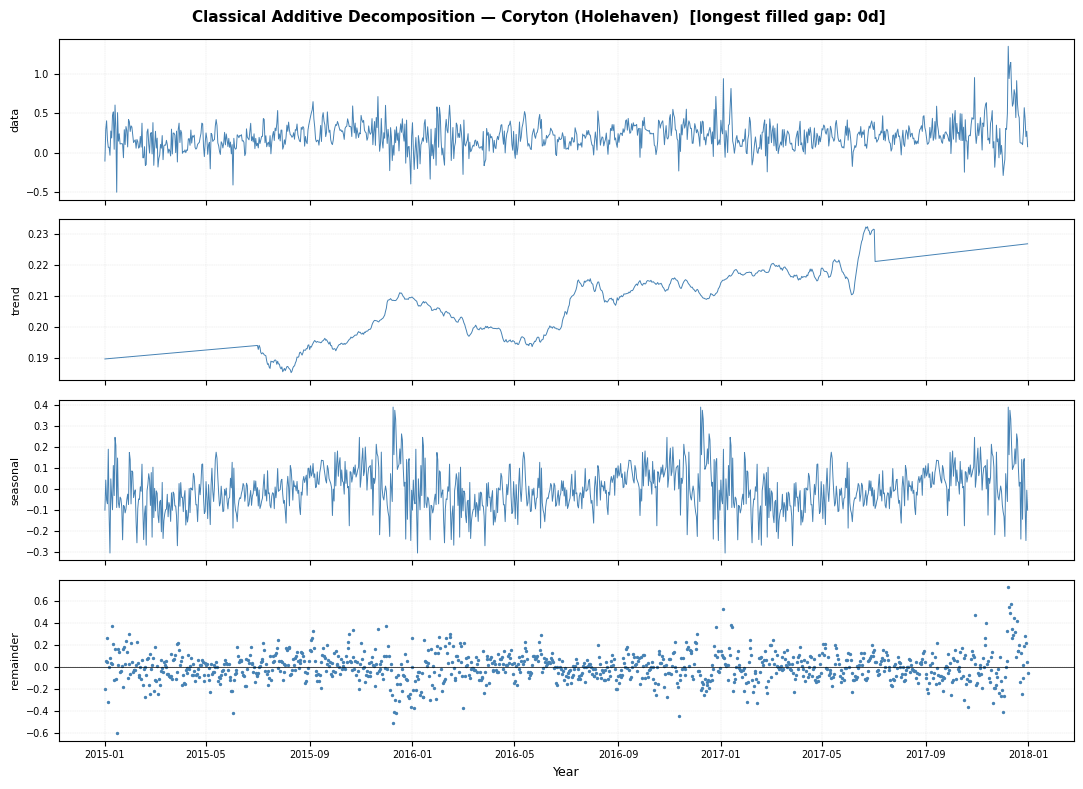

  Saved eda_decomposition_09c_CORYTON_HOLEHAVEN.png


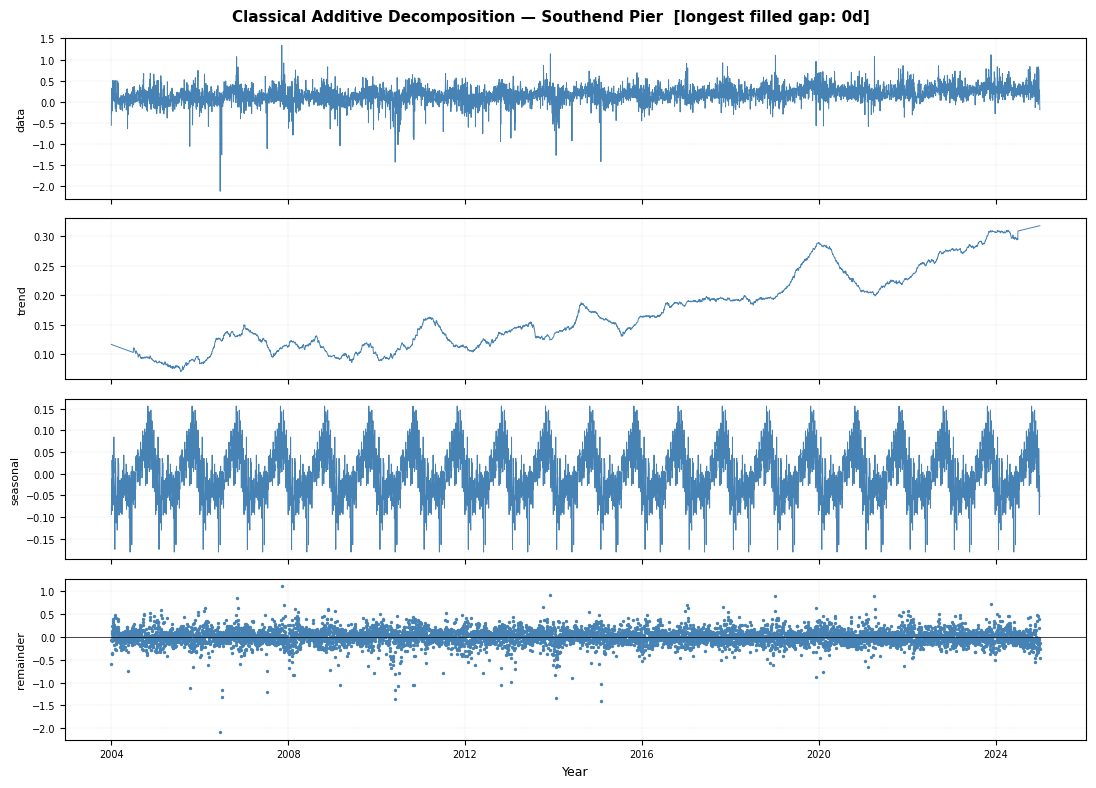

  Saved eda_decomposition_10_SOUTHEND.png


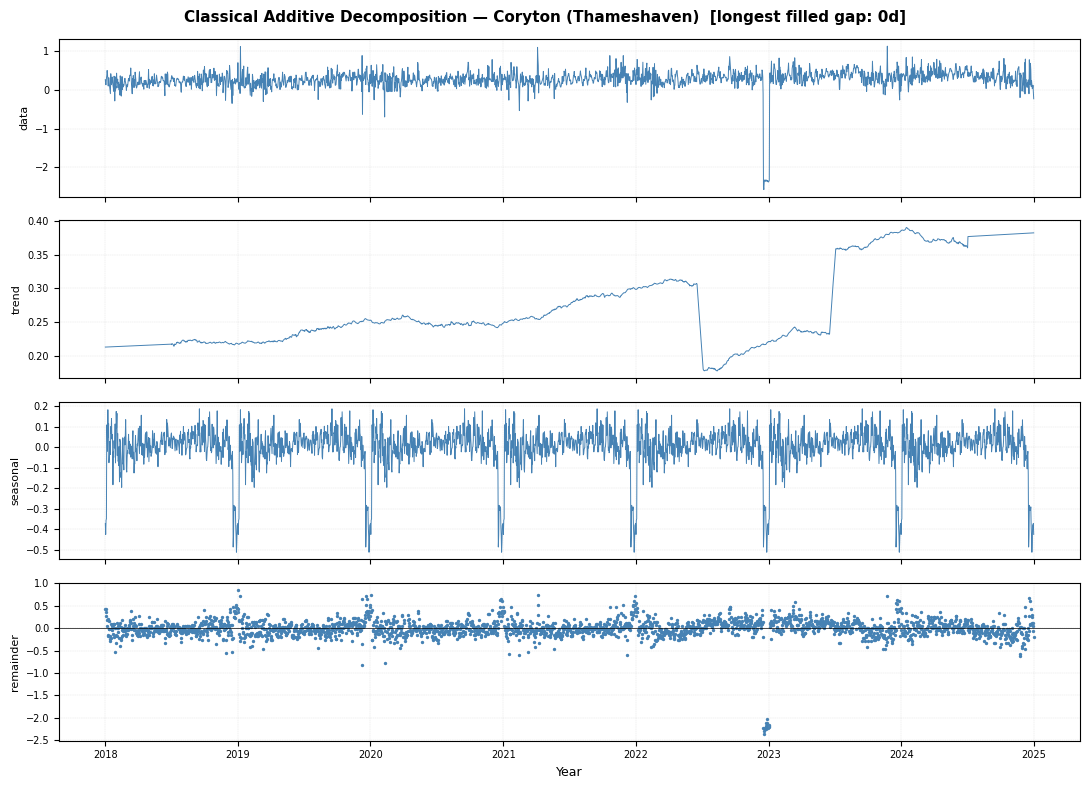

  Saved eda_decomposition_09a_CORYTON_THAMESHAVEN.png


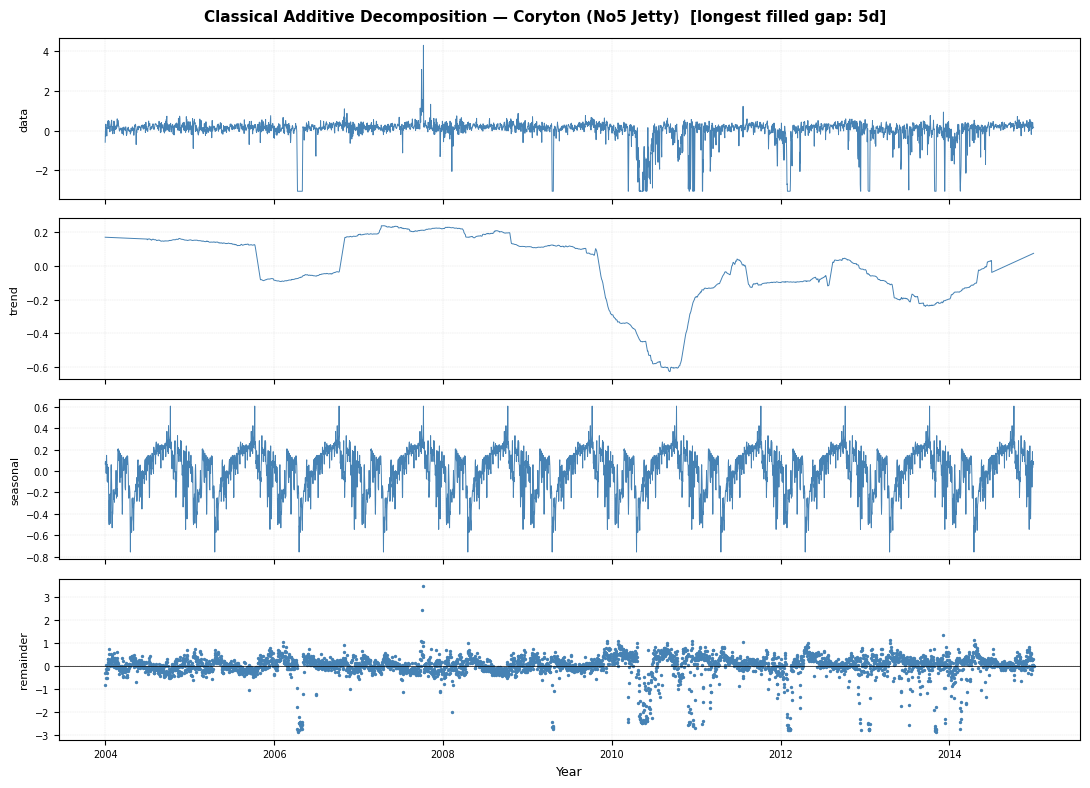

  Saved eda_decomposition_09b_CORYTON_NO5JETTY.png


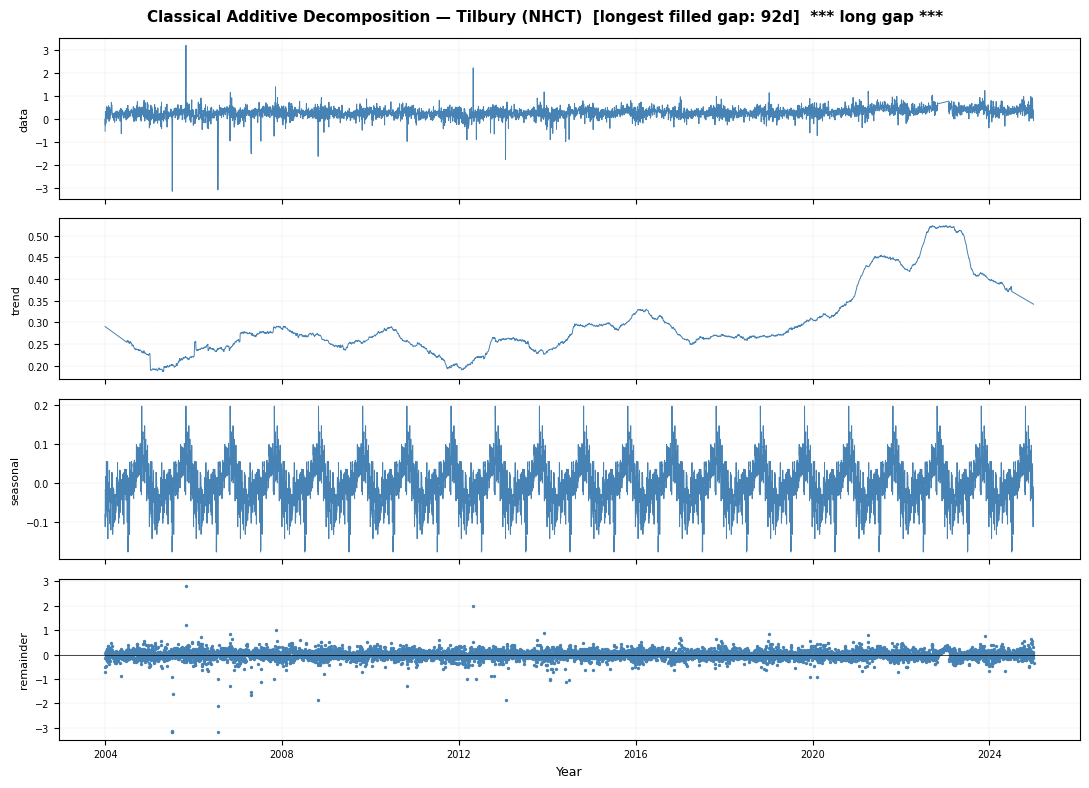

  Saved eda_decomposition_07_TILBURY.png


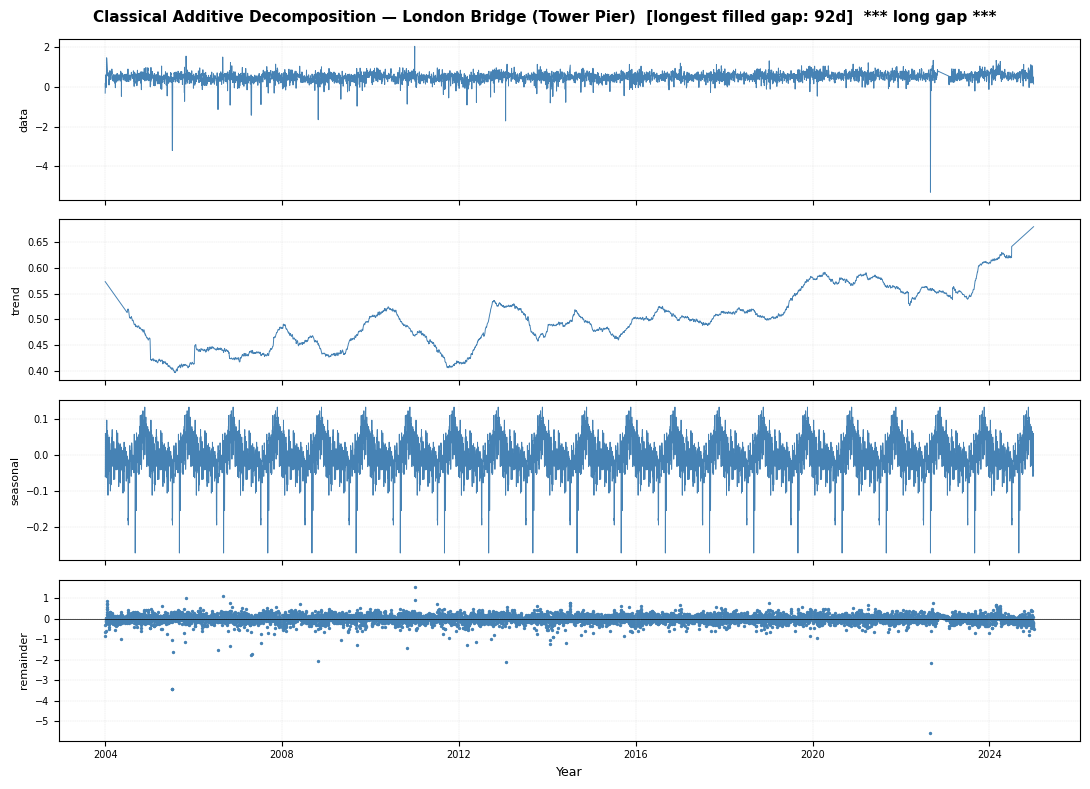

  Saved eda_decomposition_03_LONDONBRIDGE.png


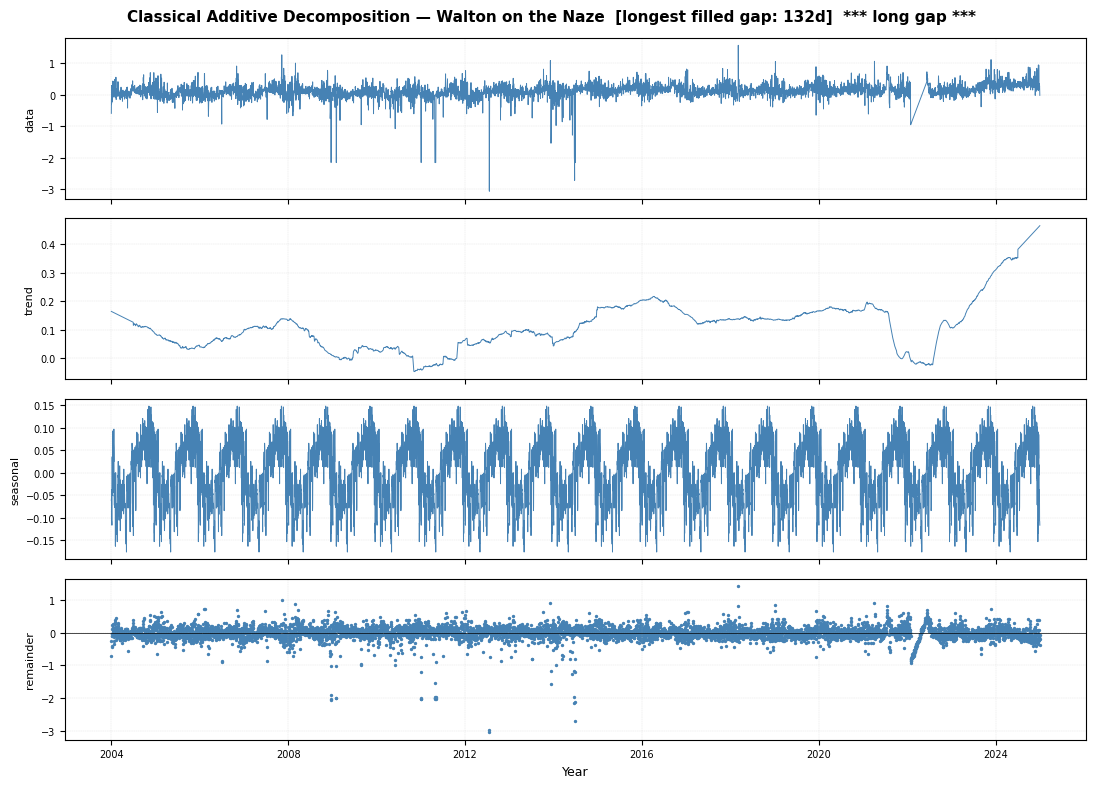

  Saved eda_decomposition_13_WALTON.png


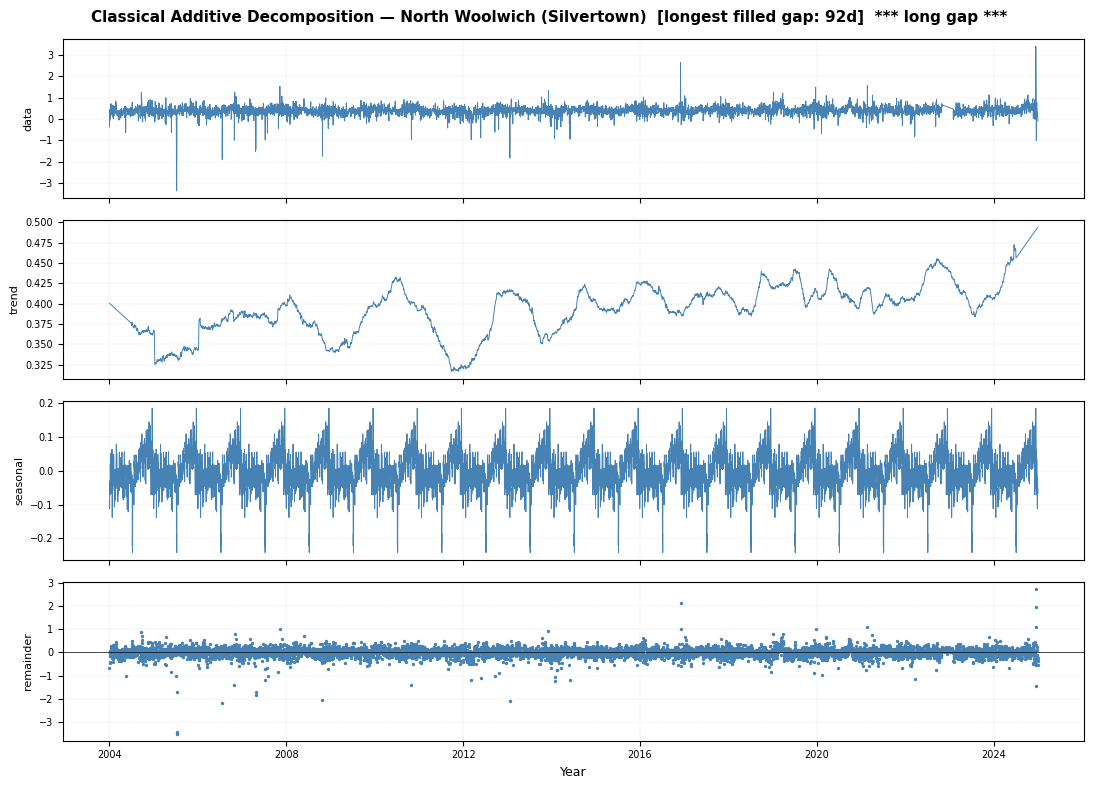

  Saved eda_decomposition_05_NORTHWOOLWICH.png


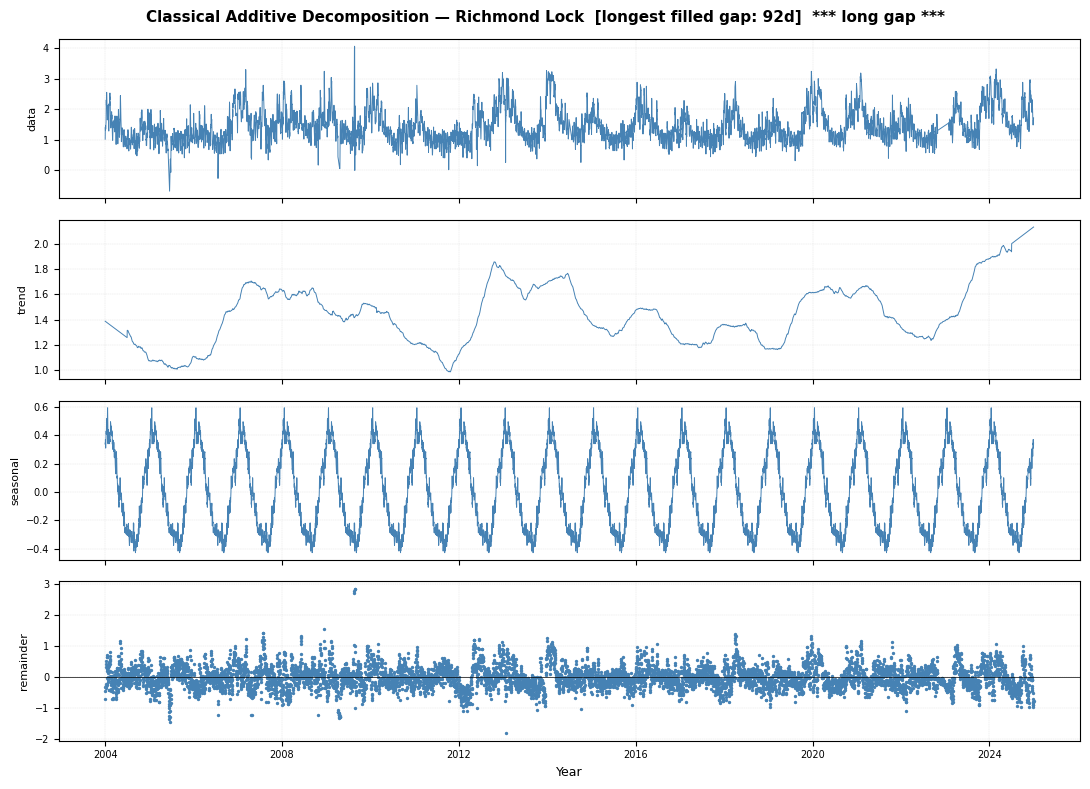

  Saved eda_decomposition_01_RICHMOND.png


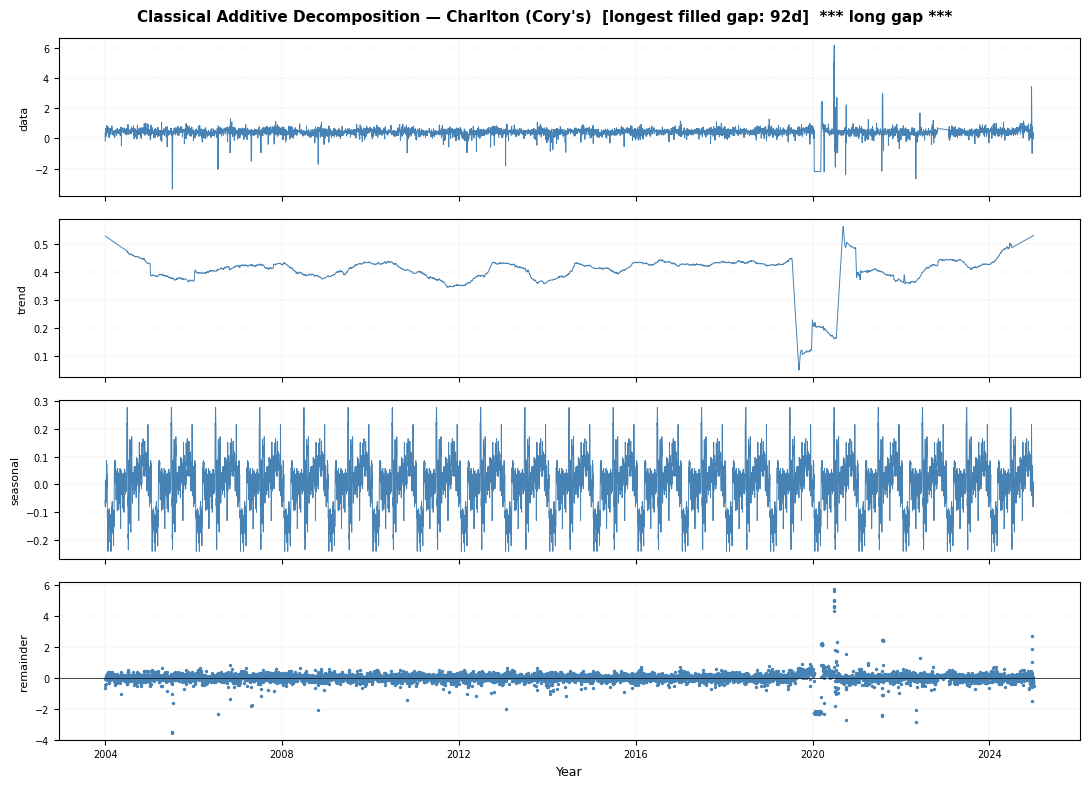

  Saved eda_decomposition_04_CHARLTON.png

Decomposition plots complete.


In [22]:
def plot_classical_decomposition(gid):
    dec = decompositions[gid]
    if dec is None:
        return
    site = gauges[gid]["SiteName"].iloc[0]

    fig, axes = plt.subplots(4, 1, figsize=(11, 8), sharex=True)
    panels = [("observed", "data"), ("trend", "trend"),
              ("seasonal", "seasonal"), ("resid", "remainder")]
    for ax, (key, label) in zip(axes, panels):
        s = dec[key]
        if key == "resid":
            ax.scatter(s.index, s.values, s=2, color="steelblue")
            ax.axhline(0, color="black", linewidth=0.5)
        else:
            ax.plot(s.index, s.values, linewidth=0.7, color="steelblue")
        ax.set_ylabel(label, fontsize=8)
        ax.tick_params(labelsize=7)
        ax.grid(True, linestyle="--", linewidth=0.3, alpha=0.4)
    axes[-1].set_xlabel("Year", fontsize=9)

    gap_tag = f"  [longest filled gap: {dec['max_gap_days']}d]" + \
              ("  *** long gap ***" if dec["long_gap"] else "")
    fig.suptitle(f"Classical {DECOMP_MODEL.capitalize()} Decomposition — {site}{gap_tag}",
                 fontsize=11, fontweight="bold")

    plt.tight_layout()
    fpath = os.path.join(TEMPORAL_EDA_DIR, f"eda_decomposition_{gid}.png")
    plt.savefig(fpath, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"  Saved {os.path.basename(fpath)}")

print("Generating decomposition plots …\n")
for gid in gauges:
    plot_classical_decomposition(gid)
print("\nDecomposition plots complete.")


In [23]:
parts = []
for gid, dec in decompositions.items():
    if dec is None:
        continue
    site = gauges[gid]["SiteName"].iloc[0]
    df_dec = pd.DataFrame({
        "date":         dec["observed"].index,
        "observed_odn": dec["observed"].values,
        "trend":        dec["trend"].values,
        "seasonal":     dec["seasonal"].values,
        "resid":        dec["resid"].values,
    })
    df_dec["idSite"]       = gid
    df_dec["site_name"]    = site
    df_dec["max_gap_days"] = dec["max_gap_days"]
    df_dec["long_gap"]     = dec["long_gap"]
    parts.append(df_dec[["idSite", "site_name", "date", "observed_odn", "trend",
                          "seasonal", "resid", "max_gap_days", "long_gap"]])

if parts:
    DECOMP_CSV = os.path.join(TEMPORAL_EDA_DIR, "classical_decomposition.csv")
    pd.concat(parts).to_csv(DECOMP_CSV, index=False)
    print(f"Saved → {DECOMP_CSV}")
else:
    print("No gauges had sufficient history for decomposition — nothing written.")


Saved → ..\outputs\temporal_eda\classical_decomposition.csv


## Combined ODN-Referenced Levels & Pearson Correlation

Merge the `Observed_ODN` column (water level referenced to Ordnance Datum Newlyn, not each gauge's local Chart Datum) from every gauge into a single wide DataFrame keyed on `DateTime`, with each gauge as its own column (header = `idSite`). Referencing to a shared datum is what makes absolute levels comparable across gauges here. An outer join is used so no timestamps are discarded; pairwise Pearson correlation is then computed over the overlapping (non-NaN) timestamps for each pair.

In [24]:
# Build the combined DataFrame from the gauges dict (already loaded and cleaned above).
# Flagged rows are excluded so corrupt readings don't inflate correlations.
series_list = []
for gid, gdf in gauges.items():
    flag_cols = [c for c in gdf.columns if c.startswith("flag_")]
    if flag_cols:
        clean = gdf[~gdf[flag_cols].any(axis=1)]
    else:
        clean = gdf
    s = (clean.set_index("DateTime")["Observed_ODN"]
              .rename(gid))
    series_list.append(s)

combined = pd.concat(series_list, axis=1).sort_index()
combined.index.name = "DateTime"

print(f"Combined shape : {combined.shape[0]:,} rows × {combined.shape[1]} gauges")
print(f"Date range     : {combined.index.min()}  →  {combined.index.max()}\n")
print("Non-null counts per gauge:")
print(combined.count().to_string())

COMBINED_CSV = os.path.join("..", "outputs", "combined_observed.csv")
combined.to_csv(COMBINED_CSV)
print(f"\nSaved → {os.path.abspath(COMBINED_CSV)}")

Combined shape : 1,104,545 rows × 10 gauges
Date range     : 2004-01-01 00:00:00  →  2024-12-31 23:50:00

Non-null counts per gauge:
09c_CORYTON_HOLEHAVEN       157731
10_SOUTHEND                1103956
09a_CORYTON_THAMESHAVEN     365952
09b_CORYTON_NO5JETTY        569978
07_TILBURY                 1086485
03_LONDONBRIDGE            1080316
13_WALTON                  1079891
05_NORTHWOOLWICH           1078889
01_RICHMOND                1076814
04_CHARLTON                1067937



Saved → c:\Users\alfat\Documents\STA_MSc\Term_3\tidal_analysis_and_prediction\outputs\combined_observed.csv


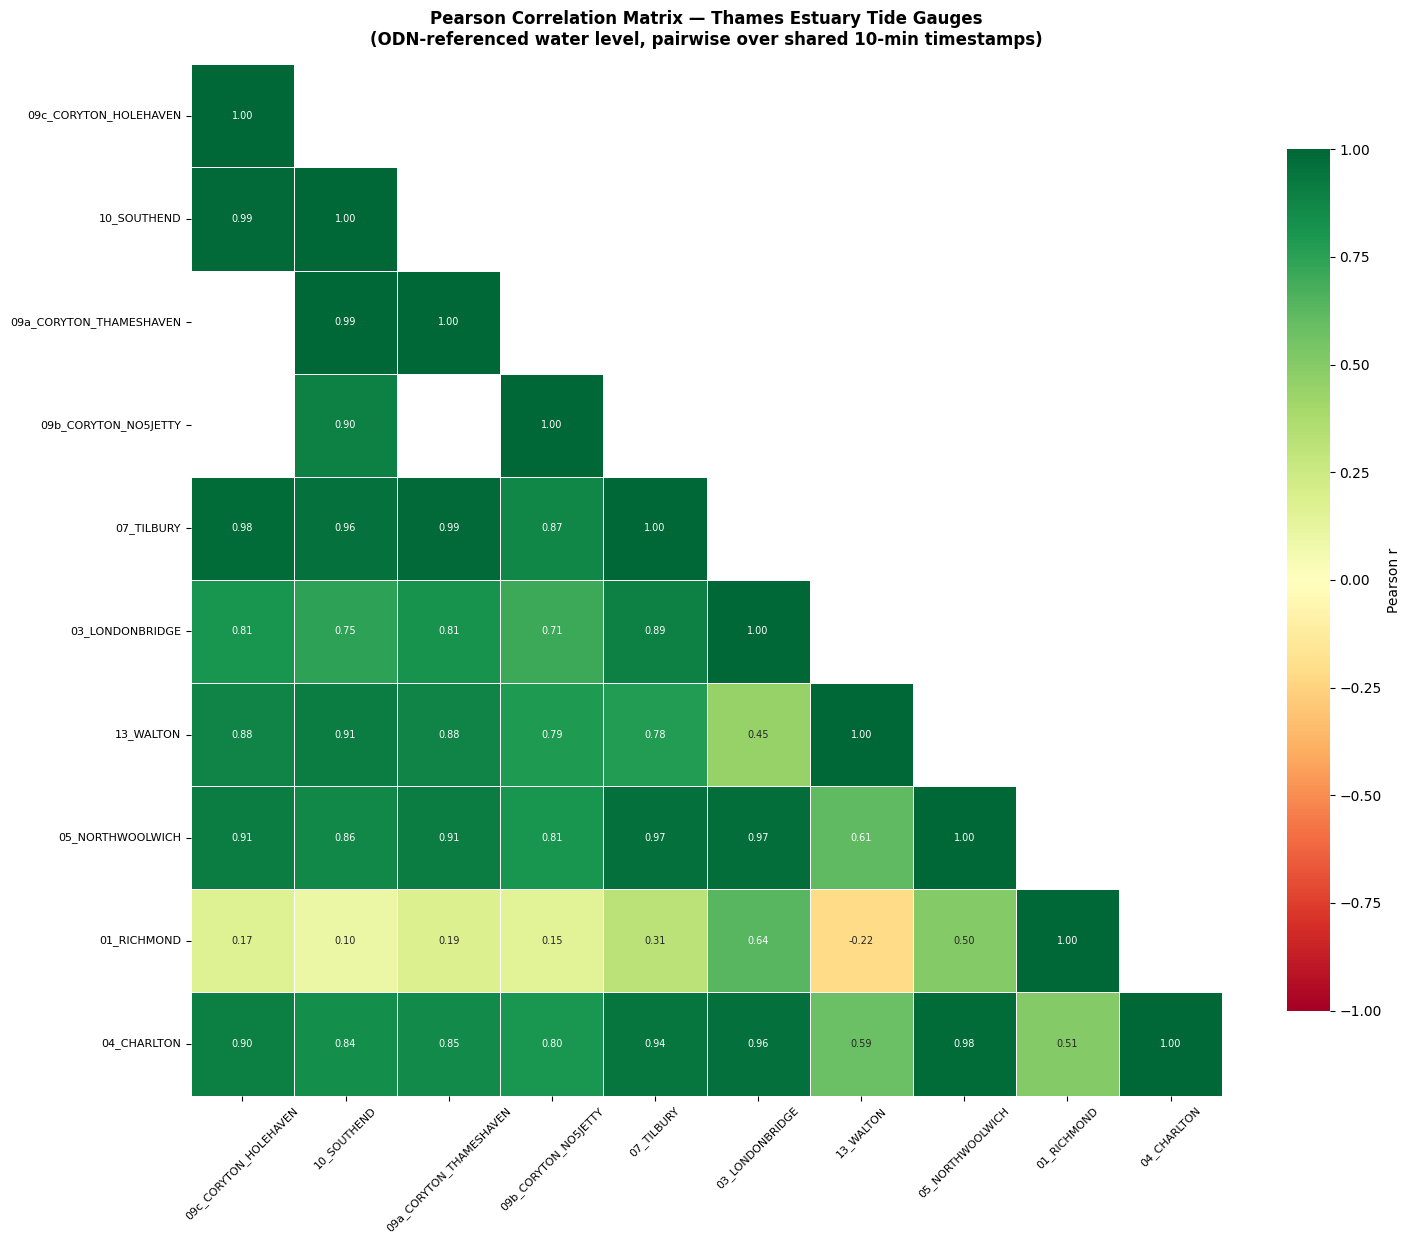

Saved → ../outputs/correlation_matrix.png


In [25]:
import seaborn as sns

corr = combined.corr(method="pearson")

# Mask the upper triangle (k=1 keeps the diagonal visible)
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(15, 13))

sns.heatmap(
    corr,
    ax=ax,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    linecolor="white",
    annot_kws={"size": 7},
    cbar_kws={"label": "Pearson r", "shrink": 0.75},
)

ax.set_title(
    "Pearson Correlation Matrix — Thames Estuary Tide Gauges\n"
    "(ODN-referenced water level, pairwise over shared 10-min timestamps)",
    fontsize=12,
    fontweight="bold",
    pad=14,
)
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.tick_params(axis="y", rotation=0, labelsize=8)

plt.tight_layout()
plt.savefig(os.path.join("..", "outputs", "correlation_matrix.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved → ../outputs/correlation_matrix.png")

## First-Difference (Daily-Mean) Correlation Matrix

Same idea as the Pearson correlation matrix above, but on each gauge's first-differenced daily-mean series (day-to-day change, not the raw level) — this looks at whether gauges move *together* day-to-day rather than just sharing a similar absolute water level. Uses the ordinary (non-seasonal) difference from item (l) in the Per-Gauge Temporal EDA above, not the semi-diurnal/seasonal one from item (m).

In [26]:
daily_diff_list = []
for gid, d in gauge_diags.items():
    s = d["daily"].diff().dropna().rename(gid)
    daily_diff_list.append(s)

combined_daily_diff = pd.concat(daily_diff_list, axis=1).sort_index()
combined_daily_diff.index.name = "DateTime"

print(f"Combined shape : {combined_daily_diff.shape[0]:,} rows × {combined_daily_diff.shape[1]} gauges")
print("Non-null counts per gauge:")
print(combined_daily_diff.count().to_string())

COMBINED_DIFF_CSV = os.path.join("..", "outputs", "combined_daily_diff.csv")
combined_daily_diff.to_csv(COMBINED_DIFF_CSV)
print(f"\nSaved → {os.path.abspath(COMBINED_DIFF_CSV)}")


Combined shape : 7,670 rows × 10 gauges
Non-null counts per gauge:
09c_CORYTON_HOLEHAVEN      1095
10_SOUTHEND                7670
09a_CORYTON_THAMESHAVEN    2556
09b_CORYTON_NO5JETTY       4004
07_TILBURY                 7575
03_LONDONBRIDGE            7549
13_WALTON                  7525
05_NORTHWOOLWICH           7540
01_RICHMOND                7517
04_CHARLTON                7564

Saved → c:\Users\alfat\Documents\STA_MSc\Term_3\tidal_analysis_and_prediction\outputs\combined_daily_diff.csv


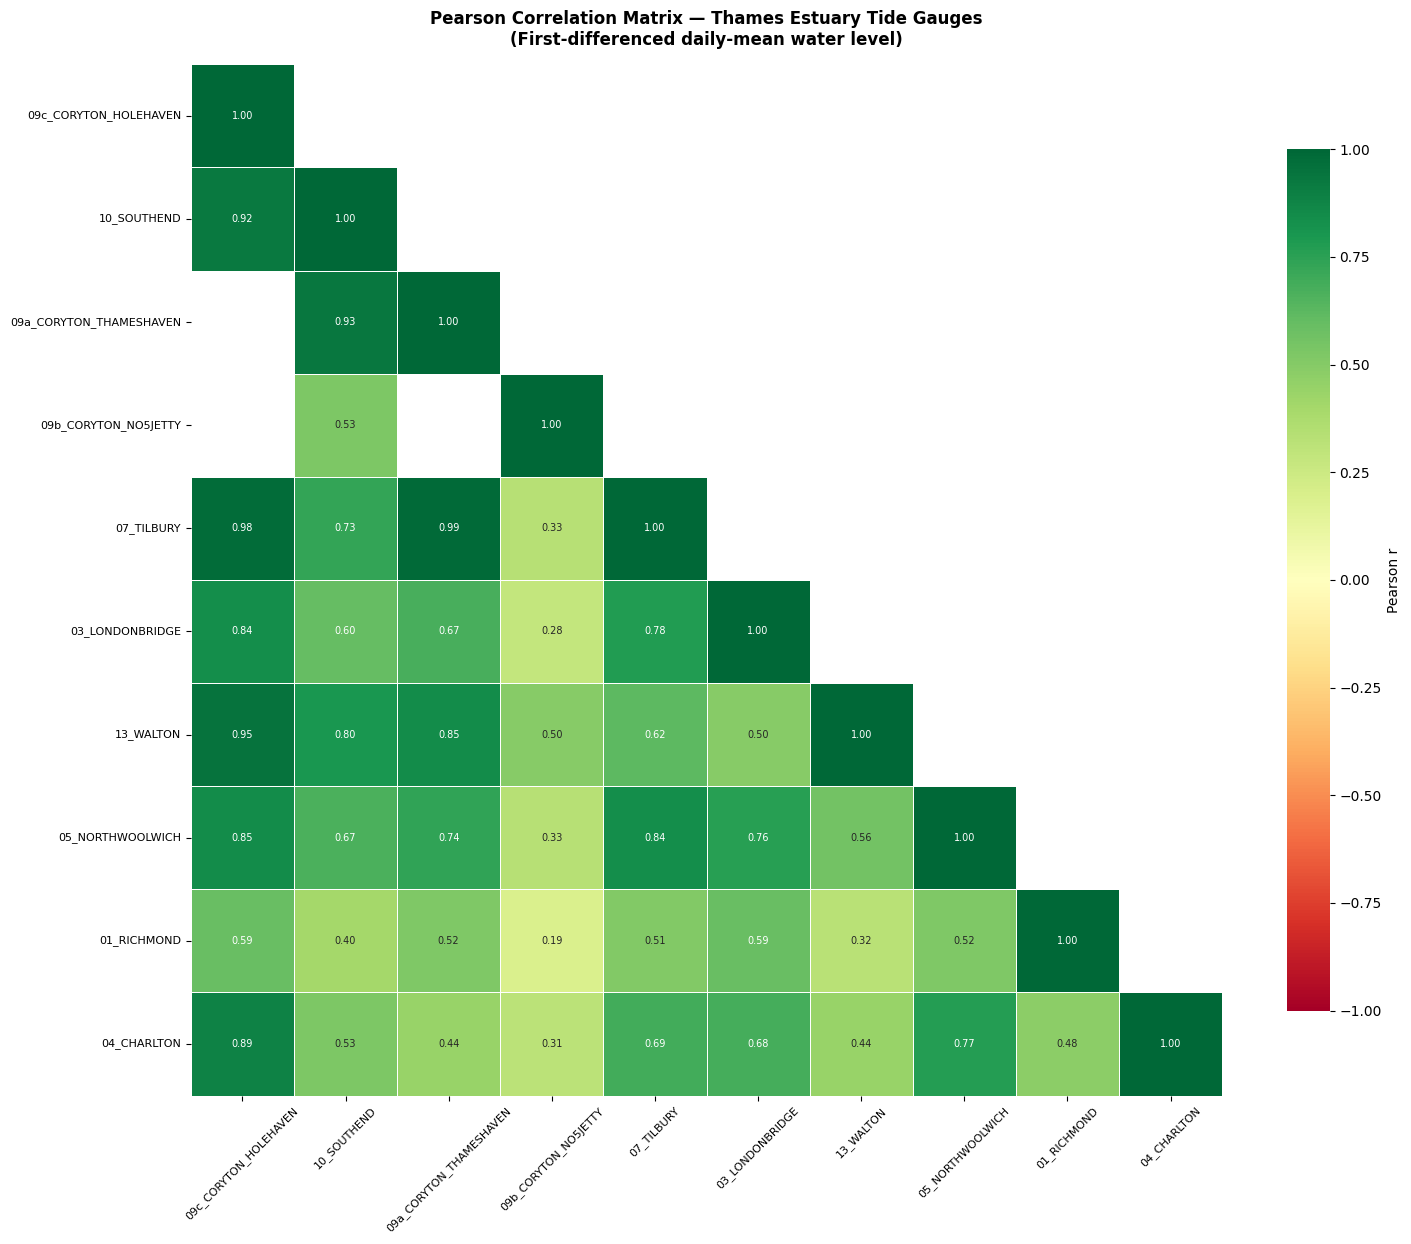

Saved → ../outputs/correlation_matrix_daily_diff.png


In [27]:
corr_diff = combined_daily_diff.corr(method="pearson")

mask_diff = np.triu(np.ones_like(corr_diff, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(15, 13))

sns.heatmap(
    corr_diff,
    ax=ax,
    mask=mask_diff,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    linecolor="white",
    annot_kws={"size": 7},
    cbar_kws={"label": "Pearson r", "shrink": 0.75},
)

ax.set_title(
    "Pearson Correlation Matrix — Thames Estuary Tide Gauges\n"
    "(First-differenced daily-mean water level)",
    fontsize=12,
    fontweight="bold",
    pad=14,
)
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.tick_params(axis="y", rotation=0, labelsize=8)

plt.tight_layout()
plt.savefig(os.path.join("..", "outputs", "correlation_matrix_daily_diff.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved → ../outputs/correlation_matrix_daily_diff.png")
